In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# Set English style
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

## 1. Load All TOFU_SUMMARY.json Files

In [21]:
def parse_model_name(dirname):
    """Parse model directory name and extract key information"""
    parts = {}
    
    # Extract model name
    if 'Llama-2-7b' in dirname:
        parts['model'] = 'Llama-2-7B'
    elif 'Llama-3.2-1B' in dirname:
        parts['model'] = 'Llama-3.2-1B'
    elif 'phi-1_5' in dirname:
        parts['model'] = 'Phi-1.5'
    else:
        parts['model'] = 'Unknown'
    
    # Extract forget set
    if 'forget05' in dirname:
        parts['forget_set'] = 'forget05'
    elif 'forget10' in dirname:
        parts['forget_set'] = 'forget10'
    else:
        parts['forget_set'] = 'unknown'
    
    # Extract method
    if 'GradAscent' in dirname:
        parts['method'] = 'GradAscent'
    elif 'GradDiff' in dirname:
        parts['method'] = 'GradDiff'
    elif 'SimNPO' in dirname:
        parts['method'] = 'SimNPO'
    elif 'NPO' in dirname:
        parts['method'] = 'NPO'
    else:
        parts['method'] = 'Unknown'
    
    # Extract hyperparameters
    beta_match = re.search(r'beta([0-9.]+)', dirname)
    if beta_match:
        parts['beta'] = float(beta_match.group(1))
    
    gamma_match = re.search(r'gamma([0-9.]+)', dirname)
    if gamma_match:
        parts['gamma'] = float(gamma_match.group(1))
    
    alpha_match = re.search(r'alpha([0-9.]+)', dirname)
    if alpha_match:
        parts['alpha'] = float(alpha_match.group(1))
    
    lr_match = re.search(r'lr([0-9e-]+)', dirname)
    if lr_match:
        parts['lr'] = lr_match.group(1)
    
    # Extract epoch
    epoch_match = re.search(r'epoch(\d+)', dirname)
    if epoch_match:
        parts['epoch'] = int(epoch_match.group(1))
    
    return parts

def load_all_summaries(base_path):
    """Load all TOFU_SUMMARY.json files"""
    results = []
    base_path = Path(base_path)
    
    for model_dir in base_path.iterdir():
        if not model_dir.is_dir():
            continue
            
        summary_file = model_dir / 'evals' / 'TOFU_SUMMARY.json'
        if not summary_file.exists():
            continue
        
        try:
            with open(summary_file, 'r') as f:
                data = json.load(f)
            
            # Parse directory name
            parsed = parse_model_name(model_dir.name)
            parsed['dir_name'] = model_dir.name
            
            # Merge data
            parsed.update(data)
            results.append(parsed)
            
        except Exception as e:
            print(f"Error loading {summary_file}: {e}")
    
    return pd.DataFrame(results)

# Load data
unlearn_path = '/cnz/data/project/my-open-unlearning/saves/unlearn/llama_2_chat'
# unlearn_path = '/cnz/data/project/my-open-unlearning/saves/unlearn/phi'
df = load_all_summaries(unlearn_path)

# Filter only one model type
# Uncomment the model you want to analyze:
# df = df[df['model'] == 'Phi-1.5'].copy()
df = df[df['model'] == 'Llama-2-7B'].copy()
# df = df[df['model'] == 'Llama-3.2-1B'].copy()

# Get model name dynamically
model_name = df['model'].iloc[0] if len(df) > 0 else 'Unknown'

print(f"Successfully loaded {len(df)} {model_name} model evaluation results")
print(f"\nMethods: {df['method'].unique()}")
print(f"Forget sets: {df['forget_set'].unique()}")

Successfully loaded 50 Llama-2-7B model evaluation results

Methods: ['NPO' 'SimNPO']
Forget sets: ['forget05' 'forget10']


In [4]:
# View data overview
df.head(10)

,model,forget_set,method,beta,gamma,epoch,dir_name,exact_memorization,extraction_strength,extraction_strength_retain,forget_Q_A_Prob,forget_Q_A_ROUGE,forget_quality,forget_truth_ratio,model_utility,privleak,retain_Q_A_Prob,retain_Q_A_ROUGE,alpha,lr
0,Llama-2-7B,forget05,NPO,0.10,0.2,5,tofu_Llama-2-7b-chat-hf_forget05_NPO_beta0.1_g...,0.688241,0.075832,0.378841,0.145831,0.284712,1.779335e-01,0.690975,0.548291,-1.302605,0.615824,0.552808,NaN,NaN
1,Llama-2-7B,forget05,NPO,0.10,0.4,5,tofu_Llama-2-7b-chat-hf_forget05_NPO_beta0.1_g...,0.686294,0.080803,0.290441,0.169393,0.320772,8.783828e-02,0.695083,0.529947,-10.729151,0.527013,0.521492,NaN,NaN
2,Llama-2-7B,forget05,SimNPO,2.00,0.1,5,tofu_Llama-2-7b-chat-hf_forget05_SimNPO_beta2....,0.877326,0.236316,0.701100,0.504854,0.467935,1.869465e-09,0.568600,0.606340,-86.804378,0.895897,0.705093,NaN,NaN
3,Llama-2-7B,forget10,NPO,0.20,0.3,5,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.2_g...,0.762055,0.100706,0.446380,0.326888,0.345780,2.549651e-08,0.641905,0.585767,-53.721990,0.799354,0.569735,NaN,NaN
4,Llama-2-7B,forget10,NPO,0.20,0.5,5,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.2_g...,0.766953,0.105539,0.312599,0.371487,0.363771,1.652551e-08,0.649309,0.586960,-60.288588,0.702340,0.512142,NaN,NaN
5,Llama-2-7B,forget10,NPO,0.15,0.3,5,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.15_...,0.729848,0.087020,0.359680,0.265577,0.330394,5.002600e-05,0.660418,0.594729,-35.258272,0.756842,0.532998,NaN,NaN
6,Llama-2-7B,forget10,NPO,0.15,0.5,5,tofu_Llama-2-7b-chat-hf_forget10_NPO_beta0.15_...,0.733245,0.089960,0.268241,0.271005,0.363423,4.455793e-06,0.666345,0.550421,-38.198160,0.577107,0.506339,NaN,NaN
7,Llama-2-7B,forget10,SimNPO,2.00,0.2,5,tofu_Llama-2-7b-chat-hf_forget10_SimNPO_beta2....,0.719789,0.083533,0.556138,0.111659,0.341208,6.923242e-05,0.617554,0.613737,26.434533,0.842617,0.603906,NaN,NaN
8,Llama-2-7B,forget10,SimNPO,2.25,0.1,5,tofu_Llama-2-7b-chat-hf_forget10_SimNPO_beta2....,0.849339,0.176250,0.549674,0.442945,0.438768,1.022998e-13,0.588263,0.586166,-82.297494,0.831045,0.615054,NaN,NaN
9,Llama-2-7B,forget05,NPO,0.15,0.3,5,tofu_Llama-2-7b-chat-hf_forget05_NPO_beta0.15_...,0.737470,0.095032,0.363752,0.250855,0.334249,3.009847e-03,0.667069,0.551753,-38.126252,0.651499,0.552705,NaN,NaN


## 2. Data Statistics

In [5]:
# Count experiments per method
method_counts = df.groupby(['method', 'forget_set']).size().reset_index(name='count')
print("Number of experiments per configuration:")
print(method_counts.sort_values('count', ascending=False))

Number of experiments per configuration:
   method forget_set  count
0     NPO   forget05     16
1     NPO   forget10     16
2  SimNPO   forget05      9
3  SimNPO   forget10      9


## 3. Core Metrics Visualization

Plot 7 key metrics:
- exact_memorization (EM) - Lower is better
- extraction_strength (ES) - Lower is better
- extraction_strength_retain (ES_Retain) - Higher is better
- forget_quality (FQ) - Higher is better
- model_utility (MU) - Higher is better
- retain_Q_A_ROUGE (Retain ROUGE) - Higher is better
- forget_Q_A_ROUGE (Forget ROUGE) - Lower is better

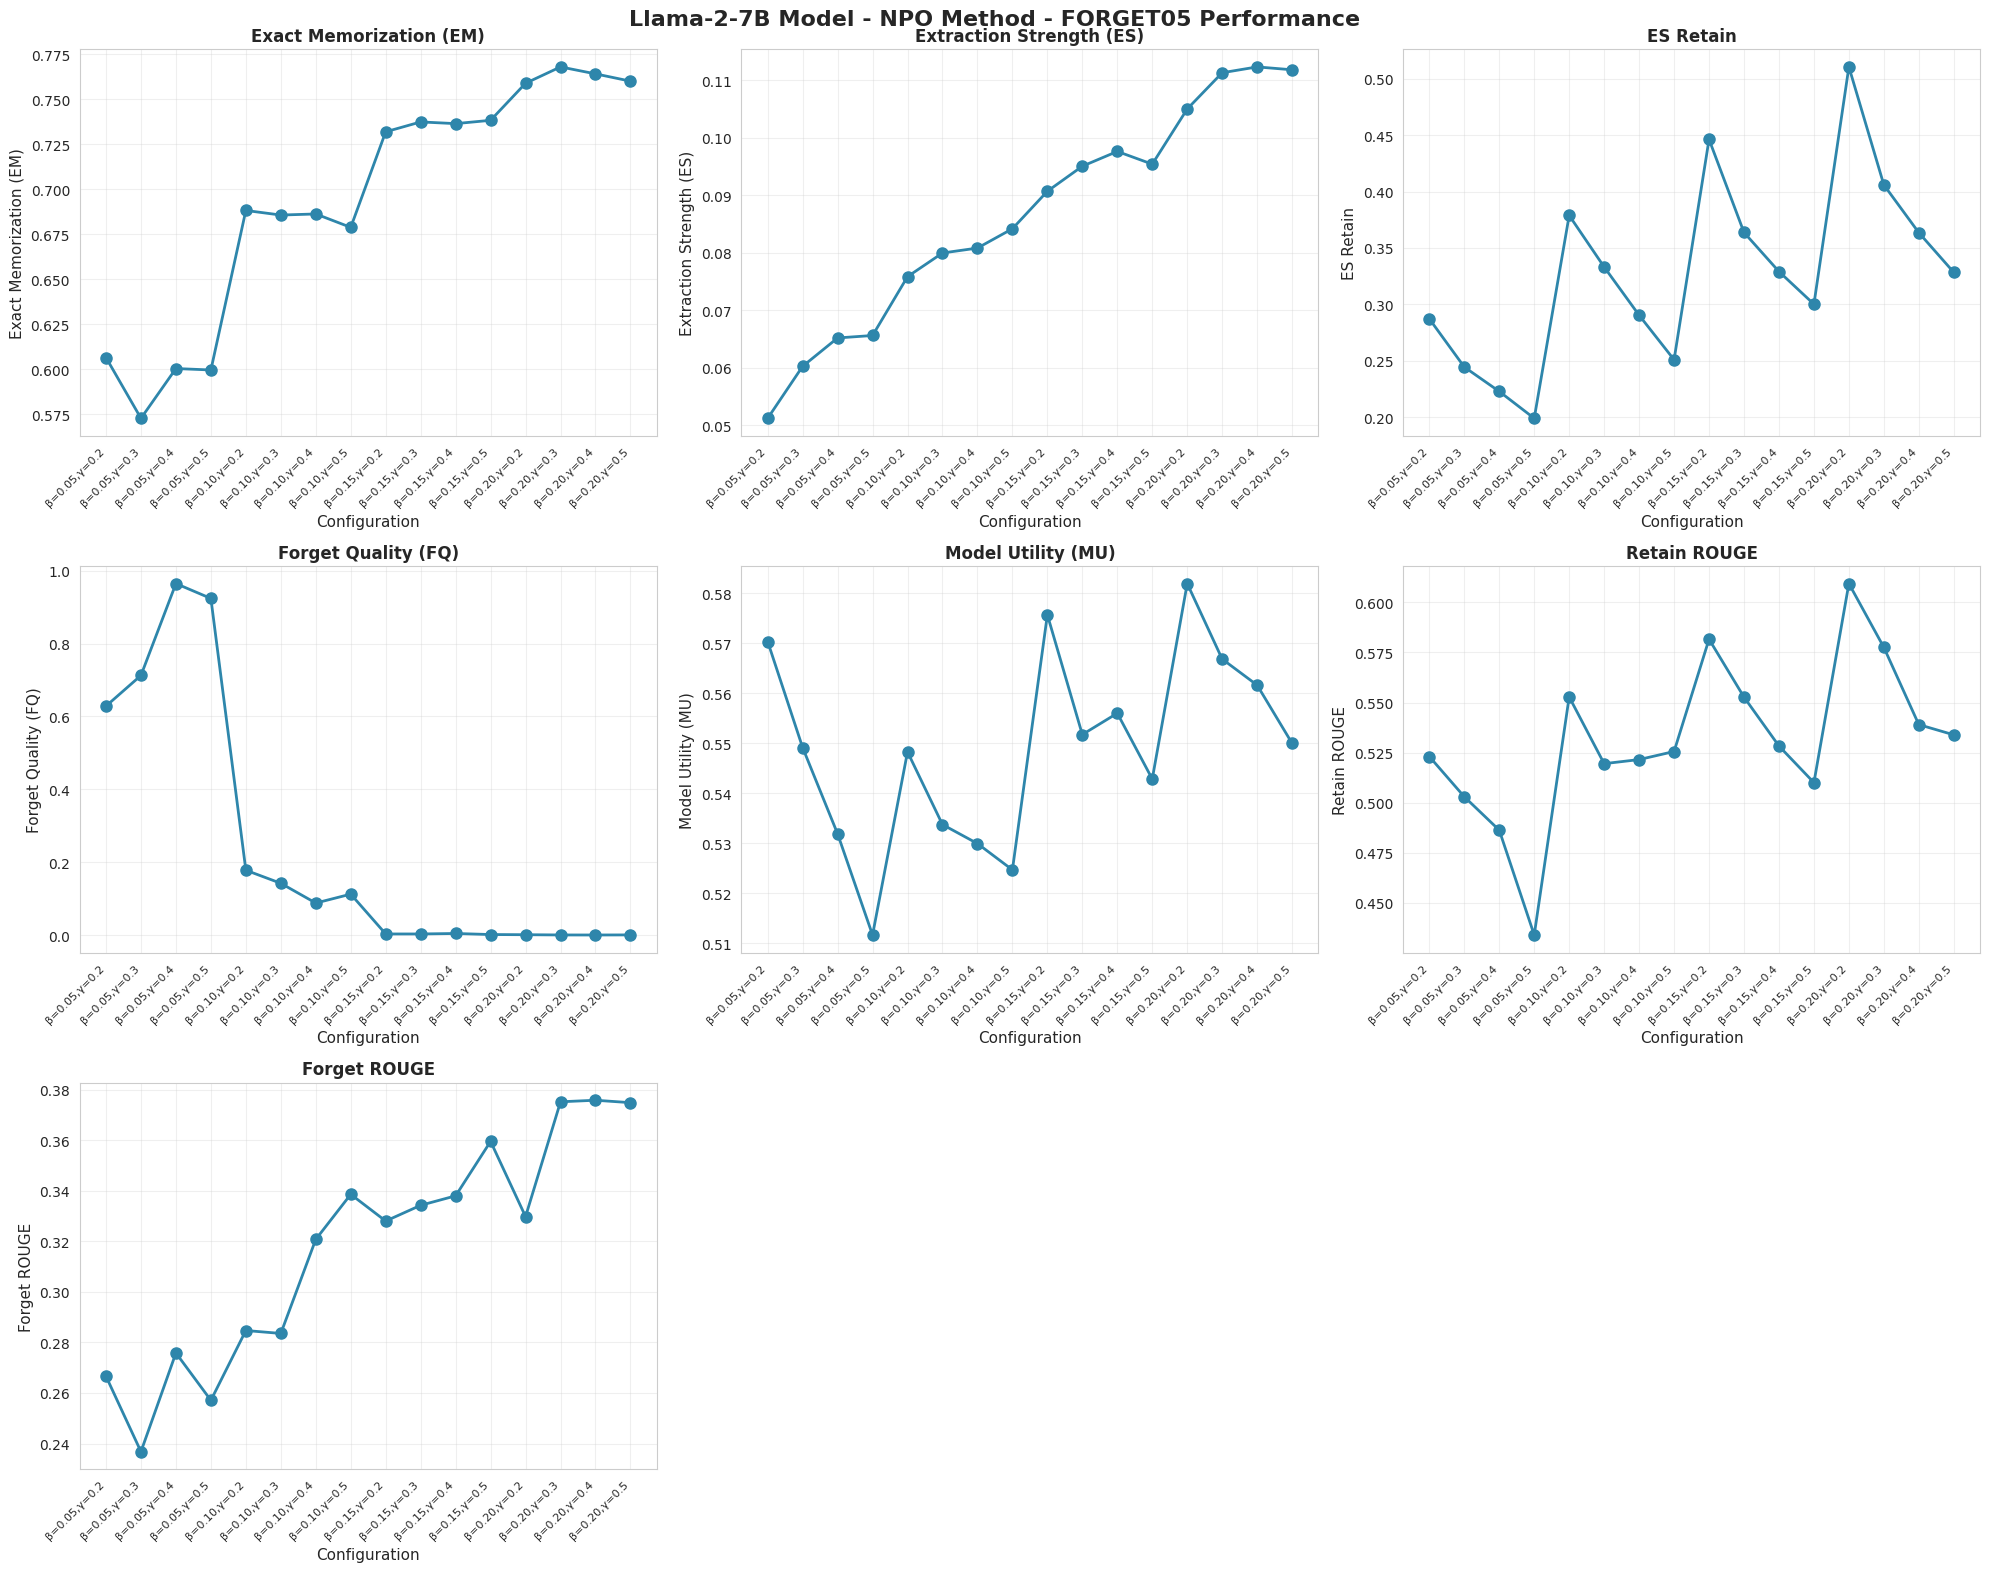

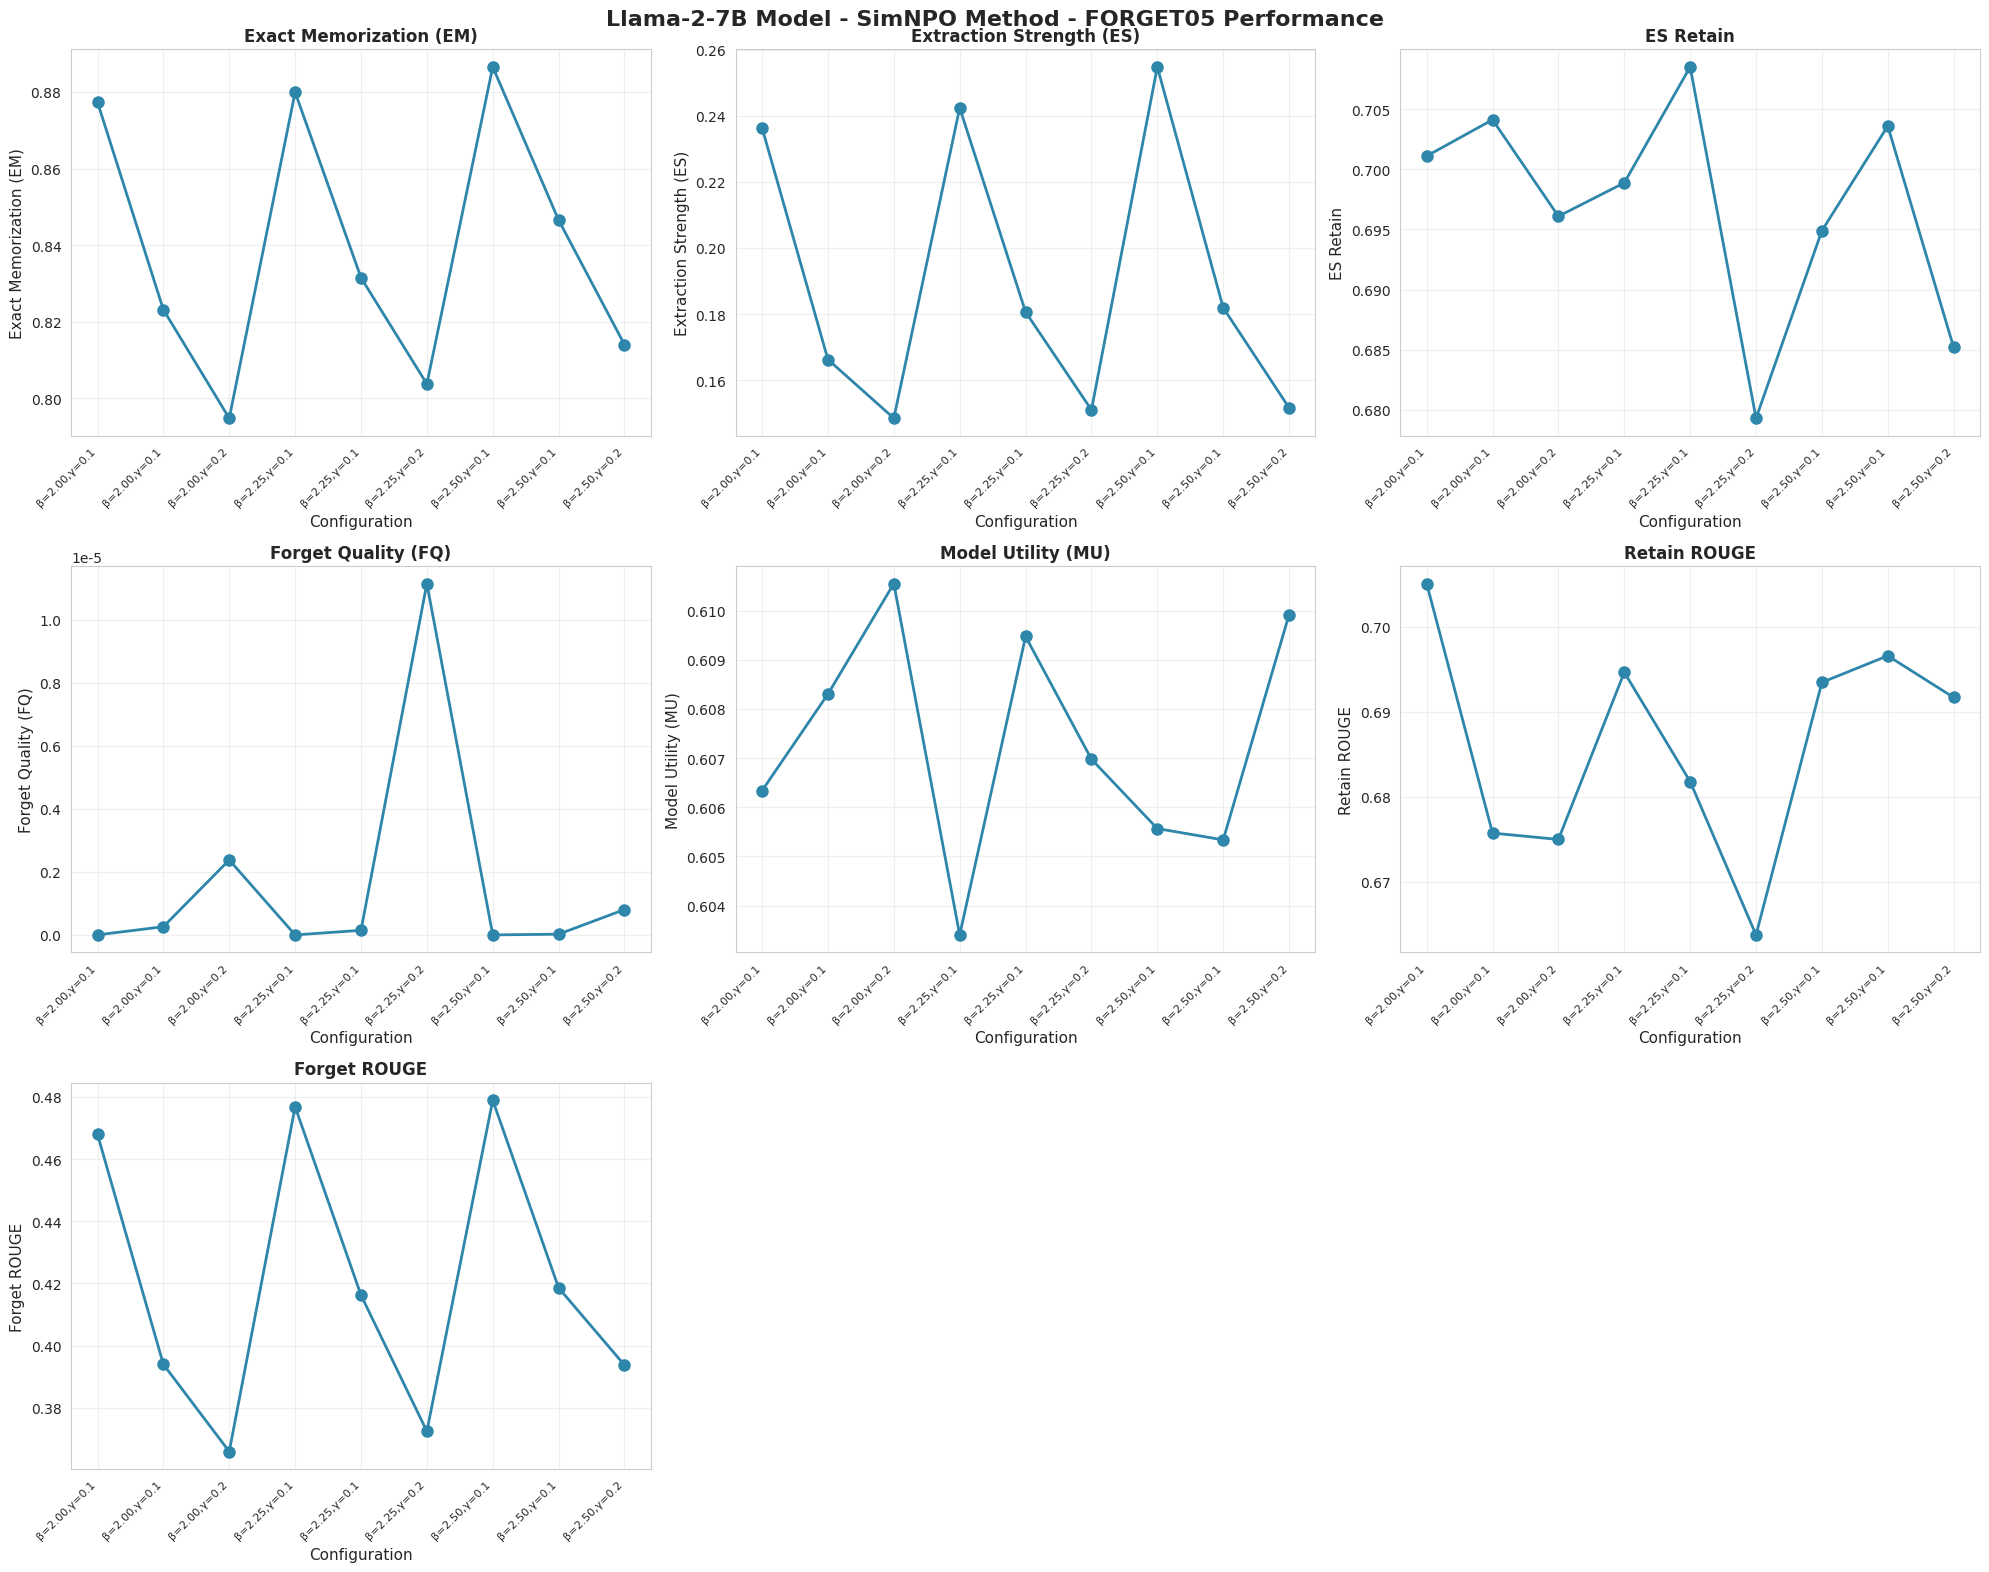

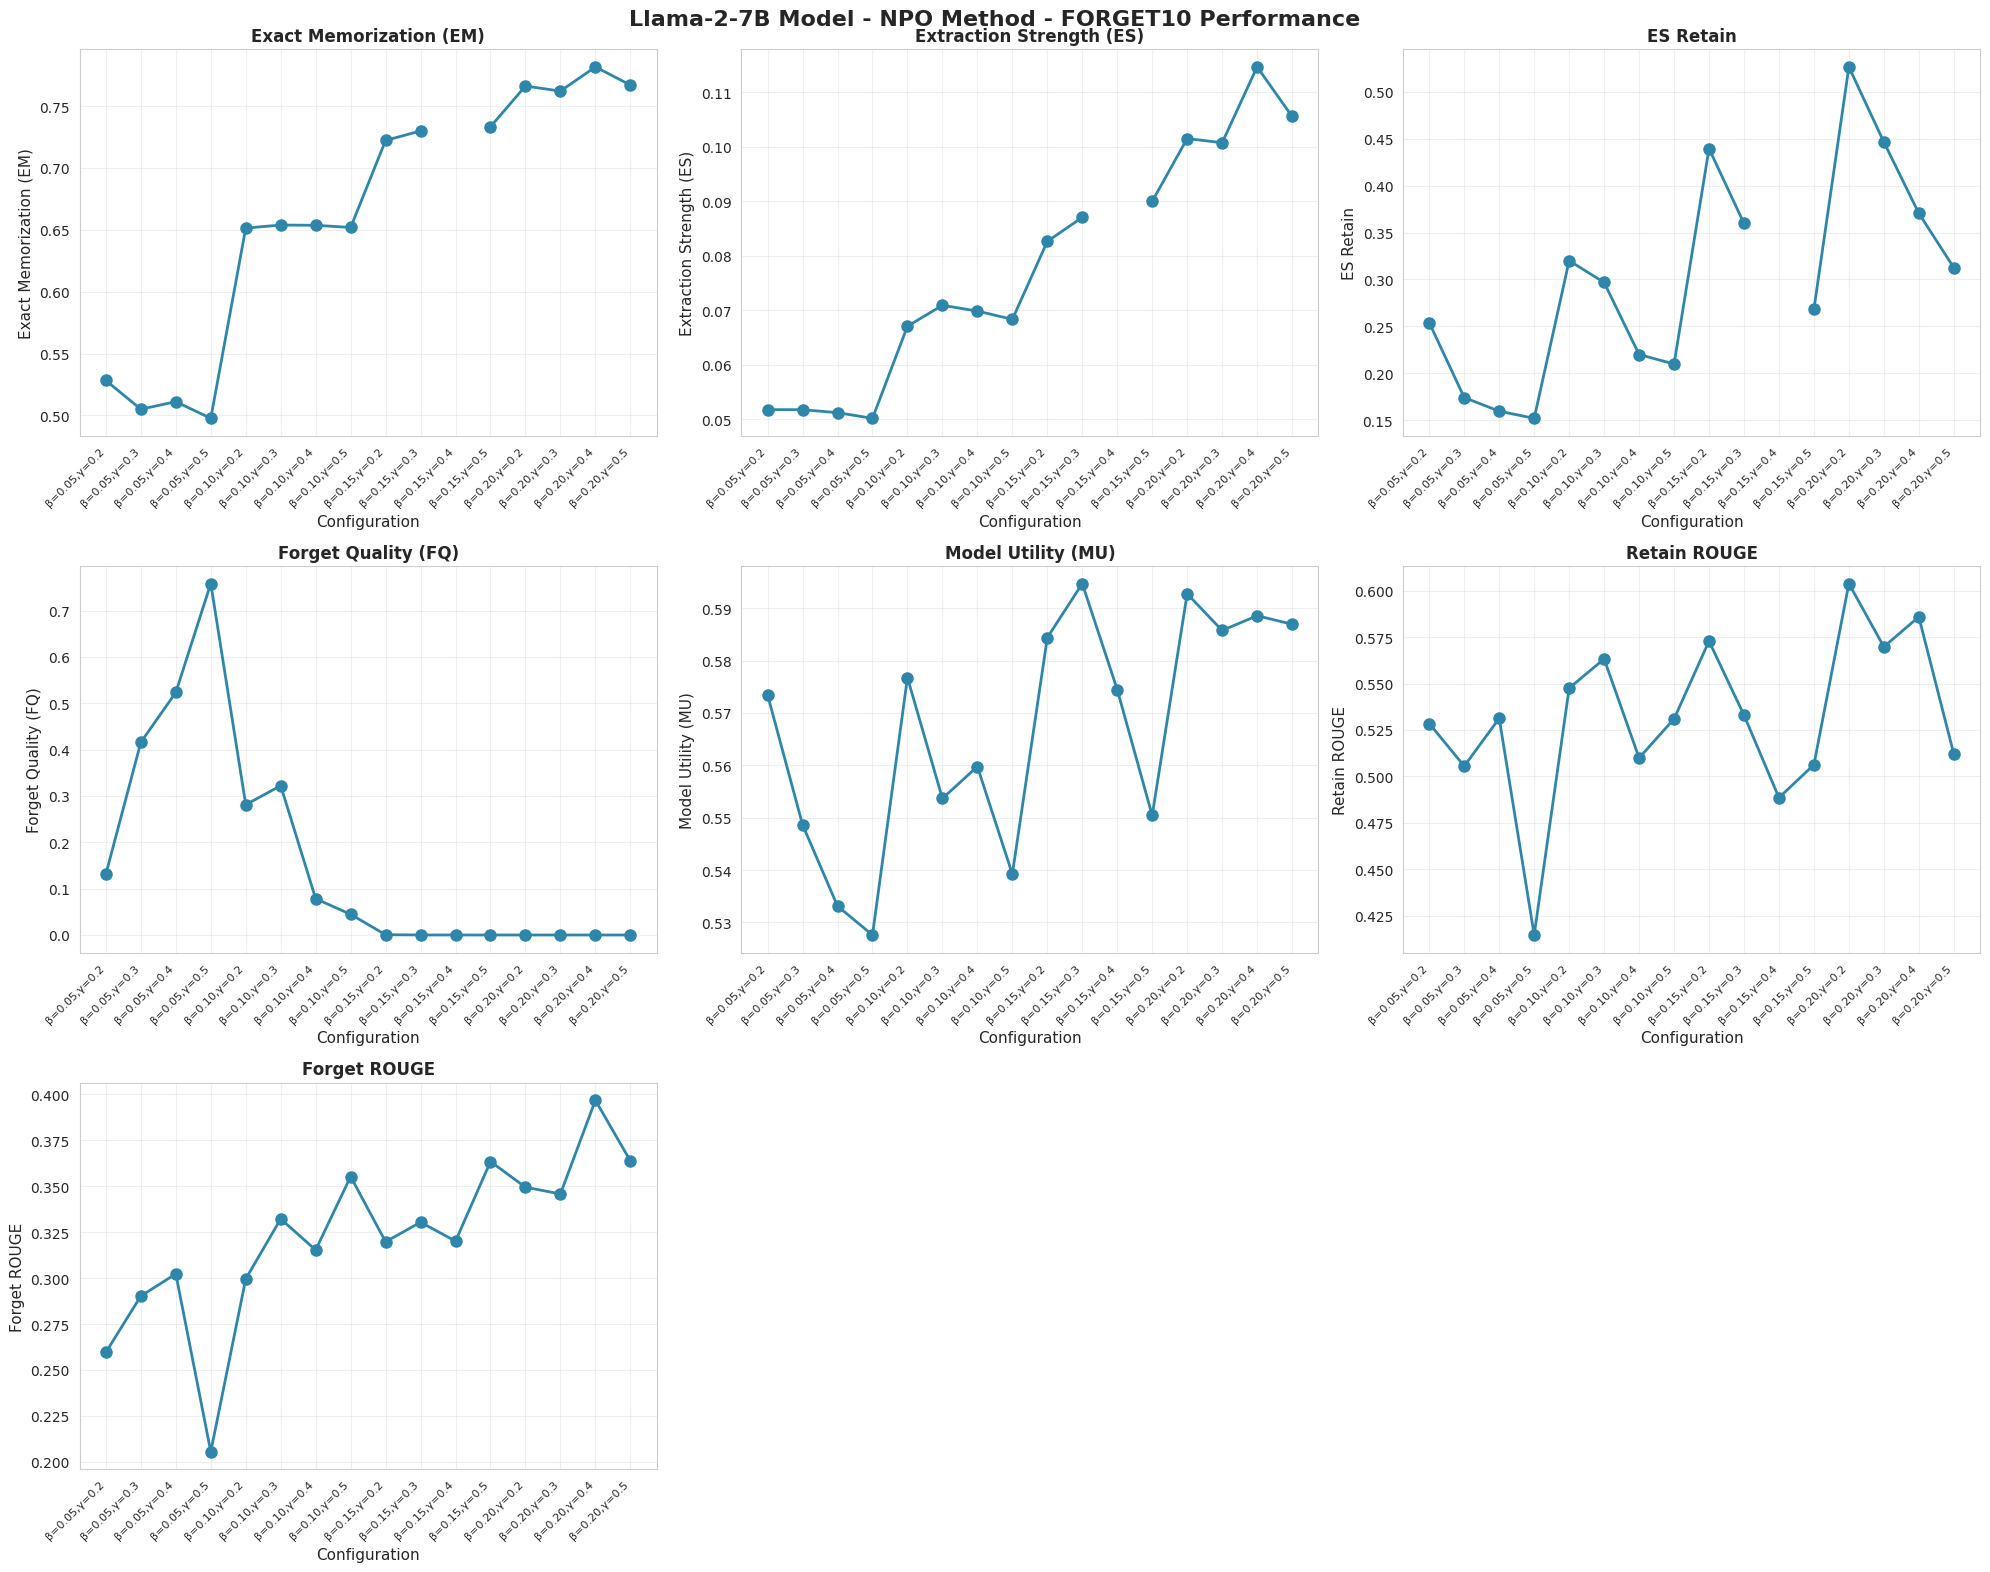

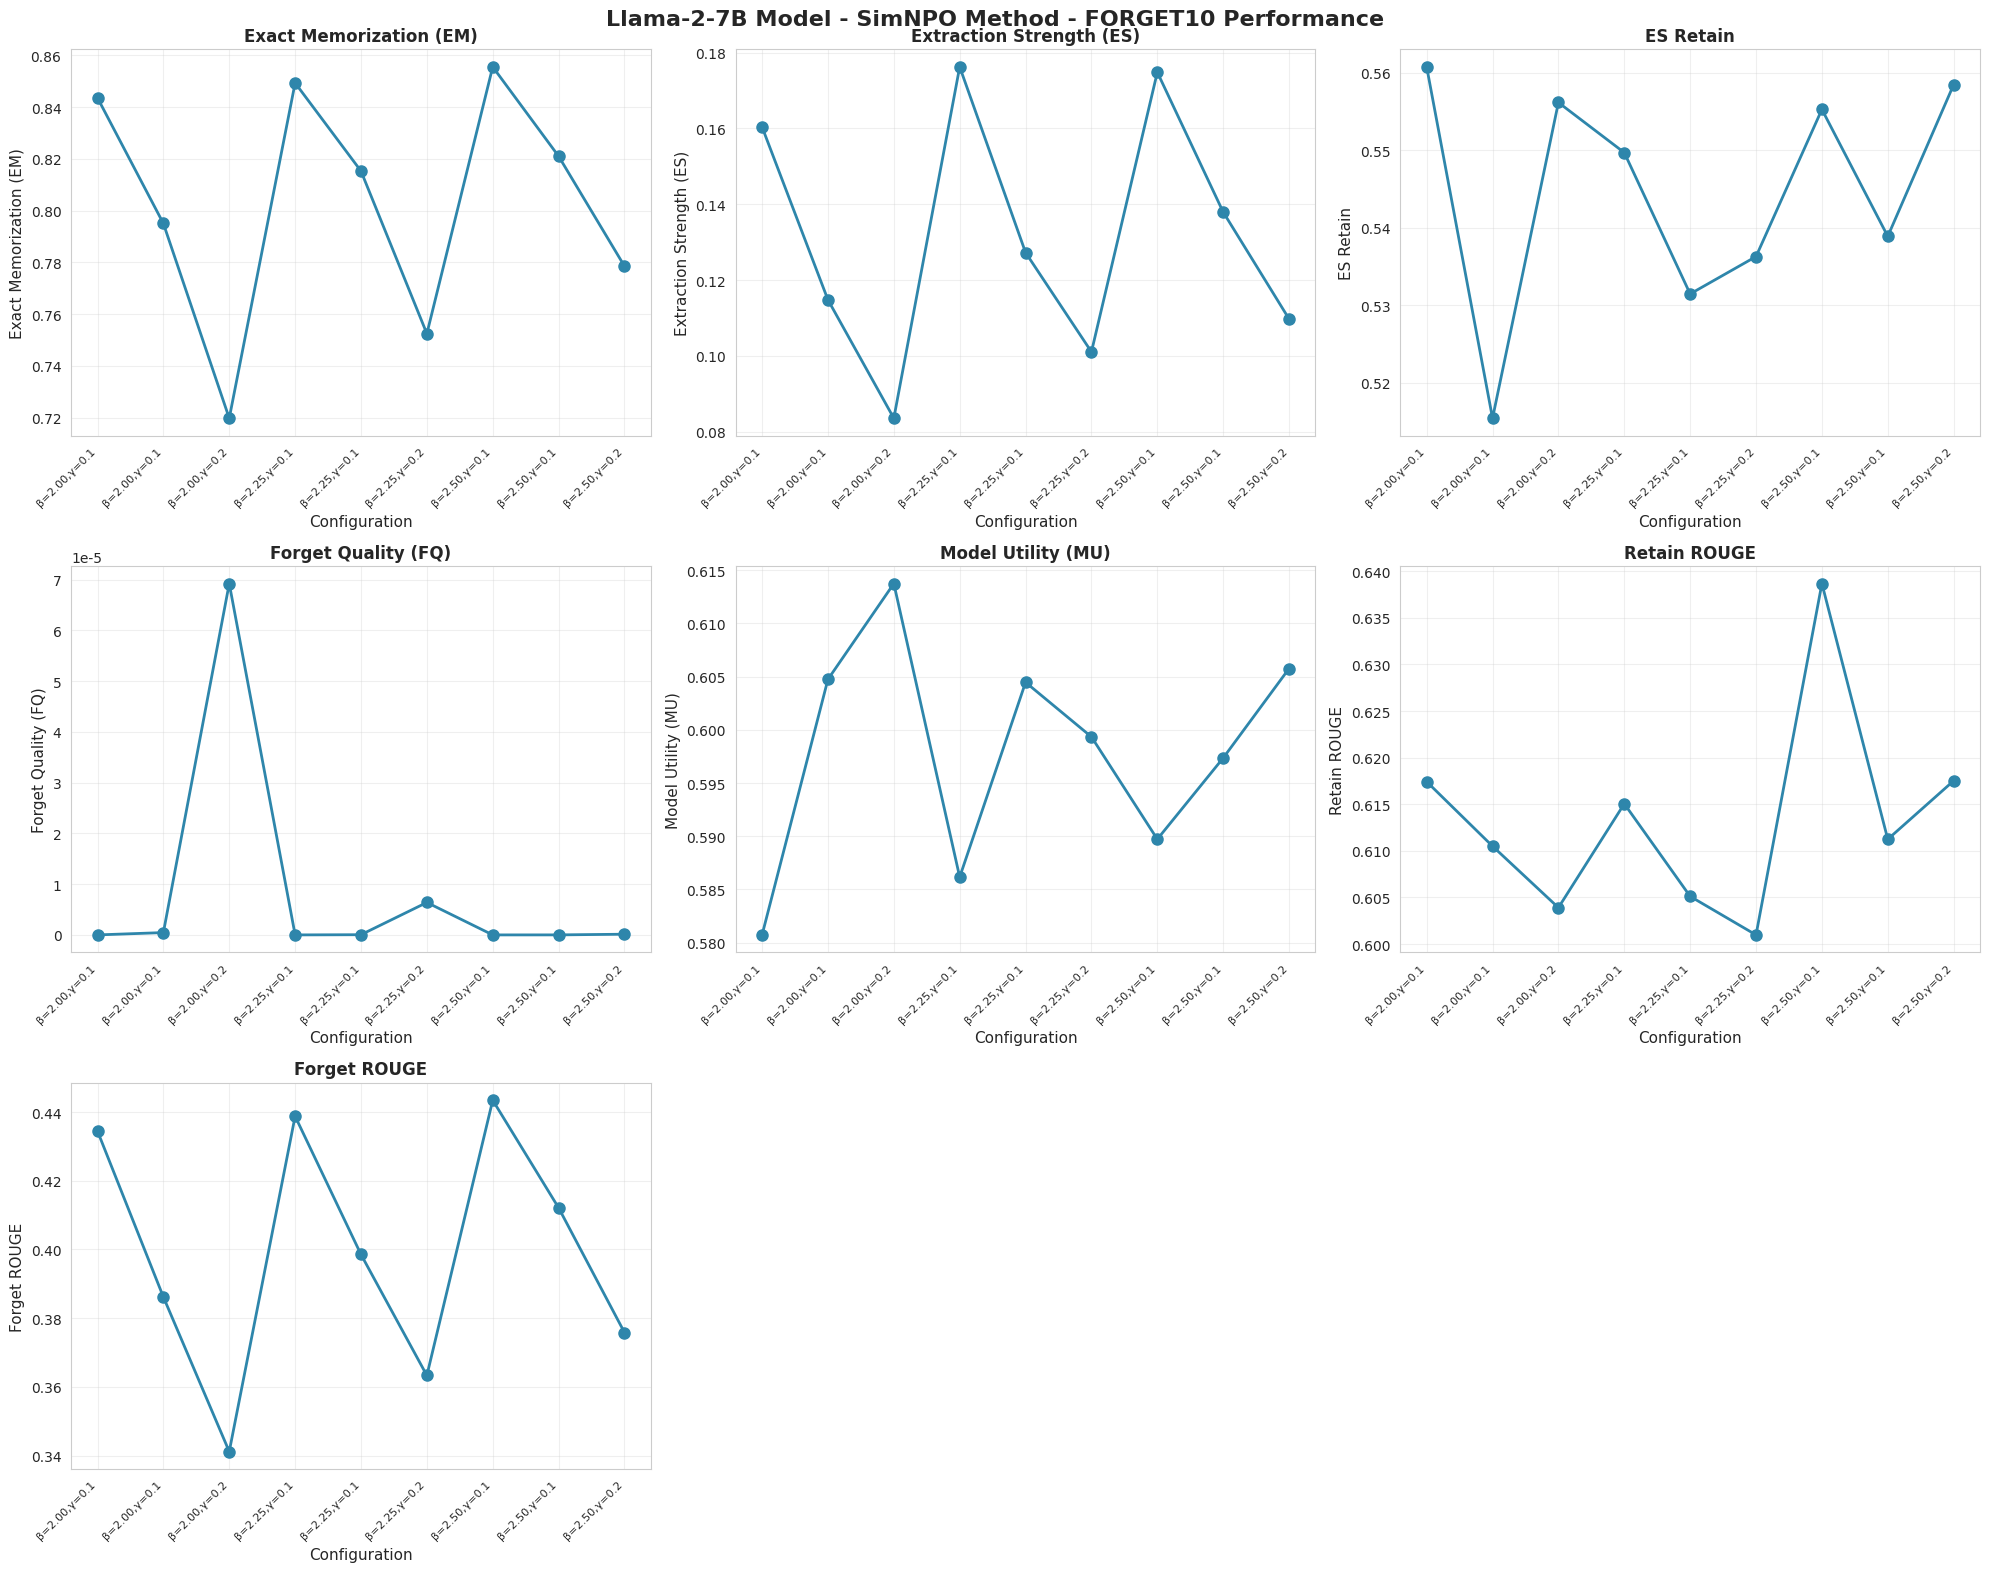

In [6]:
# Define metrics to analyze
metrics = [
    'exact_memorization',
    'extraction_strength',
    'extraction_strength_retain',
    'forget_quality',
    'model_utility',
    'retain_Q_A_ROUGE',
    'forget_Q_A_ROUGE'
]

metric_labels = {
    'exact_memorization': 'Exact Memorization (EM)',
    'extraction_strength': 'Extraction Strength (ES)',
    'extraction_strength_retain': 'ES Retain',
    'forget_quality': 'Forget Quality (FQ)',
    'model_utility': 'Model Utility (MU)',
    'retain_Q_A_ROUGE': 'Retain ROUGE',
    'forget_Q_A_ROUGE': 'Forget ROUGE'
}

# Create separate plots for each method and forget set
methods = df['method'].unique()
forget_sets = df['forget_set'].unique()

for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        if len(method_df) == 0:
            continue
        
        # Sort by hyperparameters
        if 'beta' in method_df.columns and method_df['beta'].notna().any():
            if 'gamma' in method_df.columns and method_df['gamma'].notna().any():
                # Sort by beta first, then gamma
                method_df = method_df.sort_values(['beta', 'gamma'])
                method_df['config'] = method_df.apply(lambda x: f"β={x['beta']:.2f},γ={x['gamma']:.1f}", axis=1)
            else:
                method_df = method_df.sort_values('beta')
                method_df['config'] = method_df['beta'].apply(lambda x: f"β={x:.2f}")
        else:
            method_df['config'] = range(len(method_df))
        
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        axes = axes.flatten()
        fig.suptitle(f'{model_name} Model - {method} Method - {forget_set.upper()} Performance', fontsize=16, fontweight='bold')
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            
            x_pos = range(len(method_df))
            ax.plot(x_pos, method_df[metric], marker='o', linewidth=2, markersize=8, color='#2E86AB')
            
            ax.set_xlabel('Configuration', fontsize=11)
            ax.set_ylabel(metric_labels[metric], fontsize=11)
            ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Set x-tick labels
            if len(method_df) <= 20:
                ax.set_xticks(x_pos)
                ax.set_xticklabels(method_df['config'], rotation=45, ha='right', fontsize=8)
            else:
                # Show fewer labels if too many points
                step = len(method_df) // 10
                ax.set_xticks(x_pos[::step])
                ax.set_xticklabels(method_df['config'].iloc[::step], rotation=45, ha='right', fontsize=8)
        
        # Hide extra subplots
        for idx in range(len(metrics), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        # filename = f'/cnz/data/project/my-open-unlearning/notebooks/metrics_{method}_{forget_set}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        # print(f"Saved: {filename}")

## 4. Hyperparameter Impact Analysis

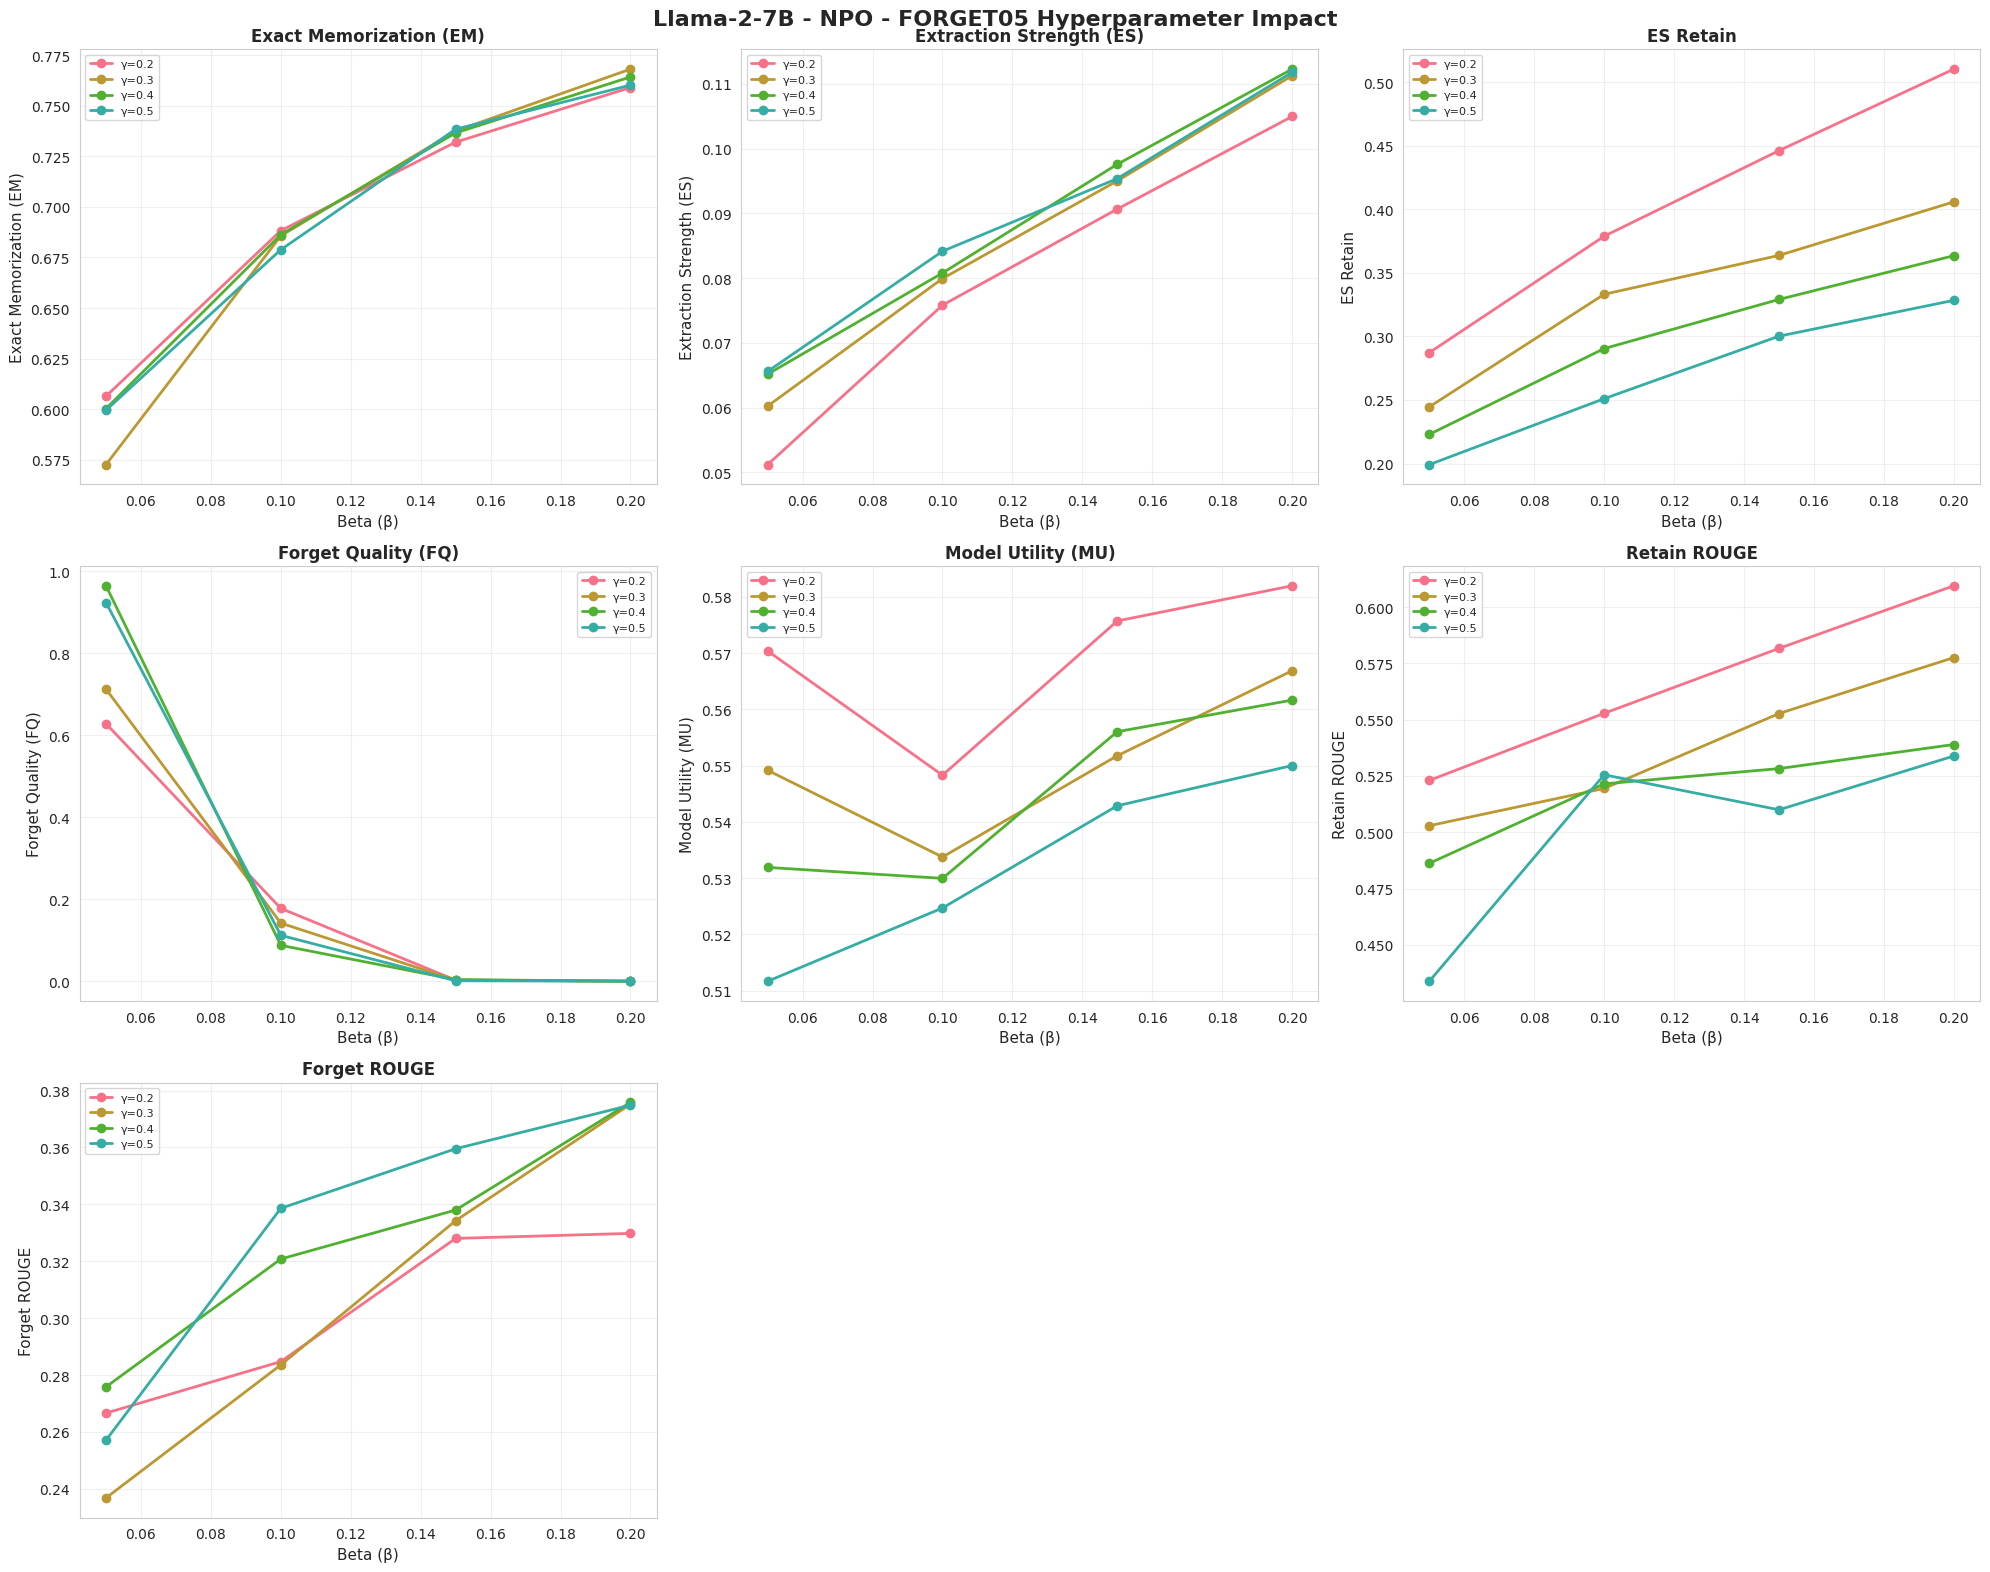

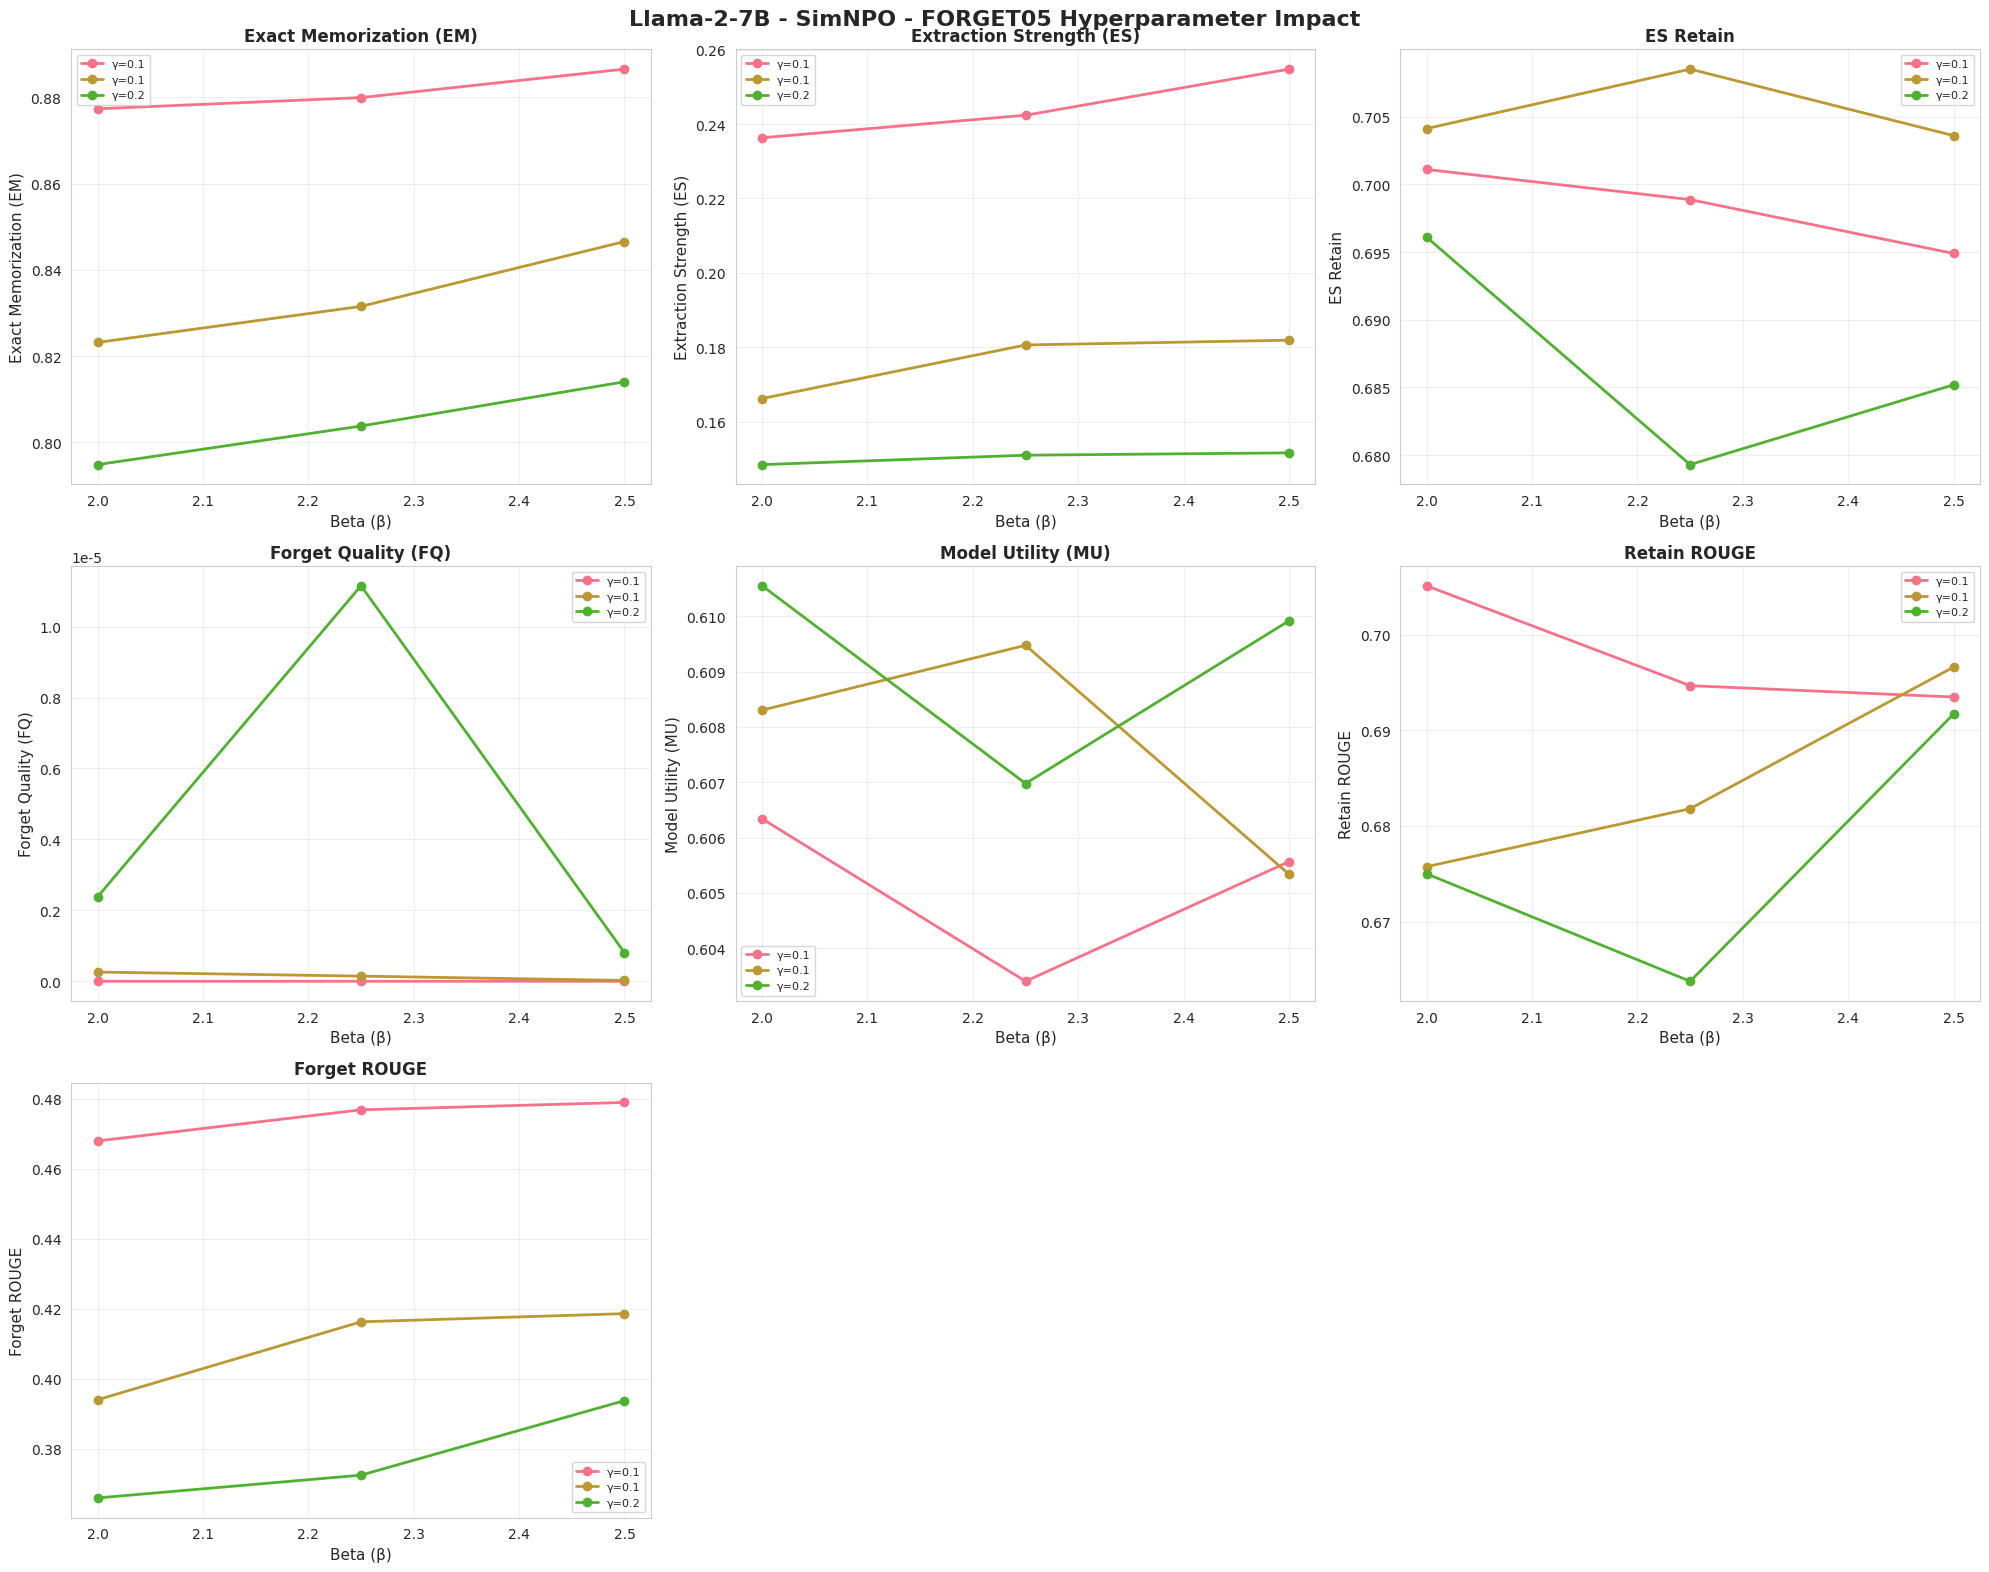

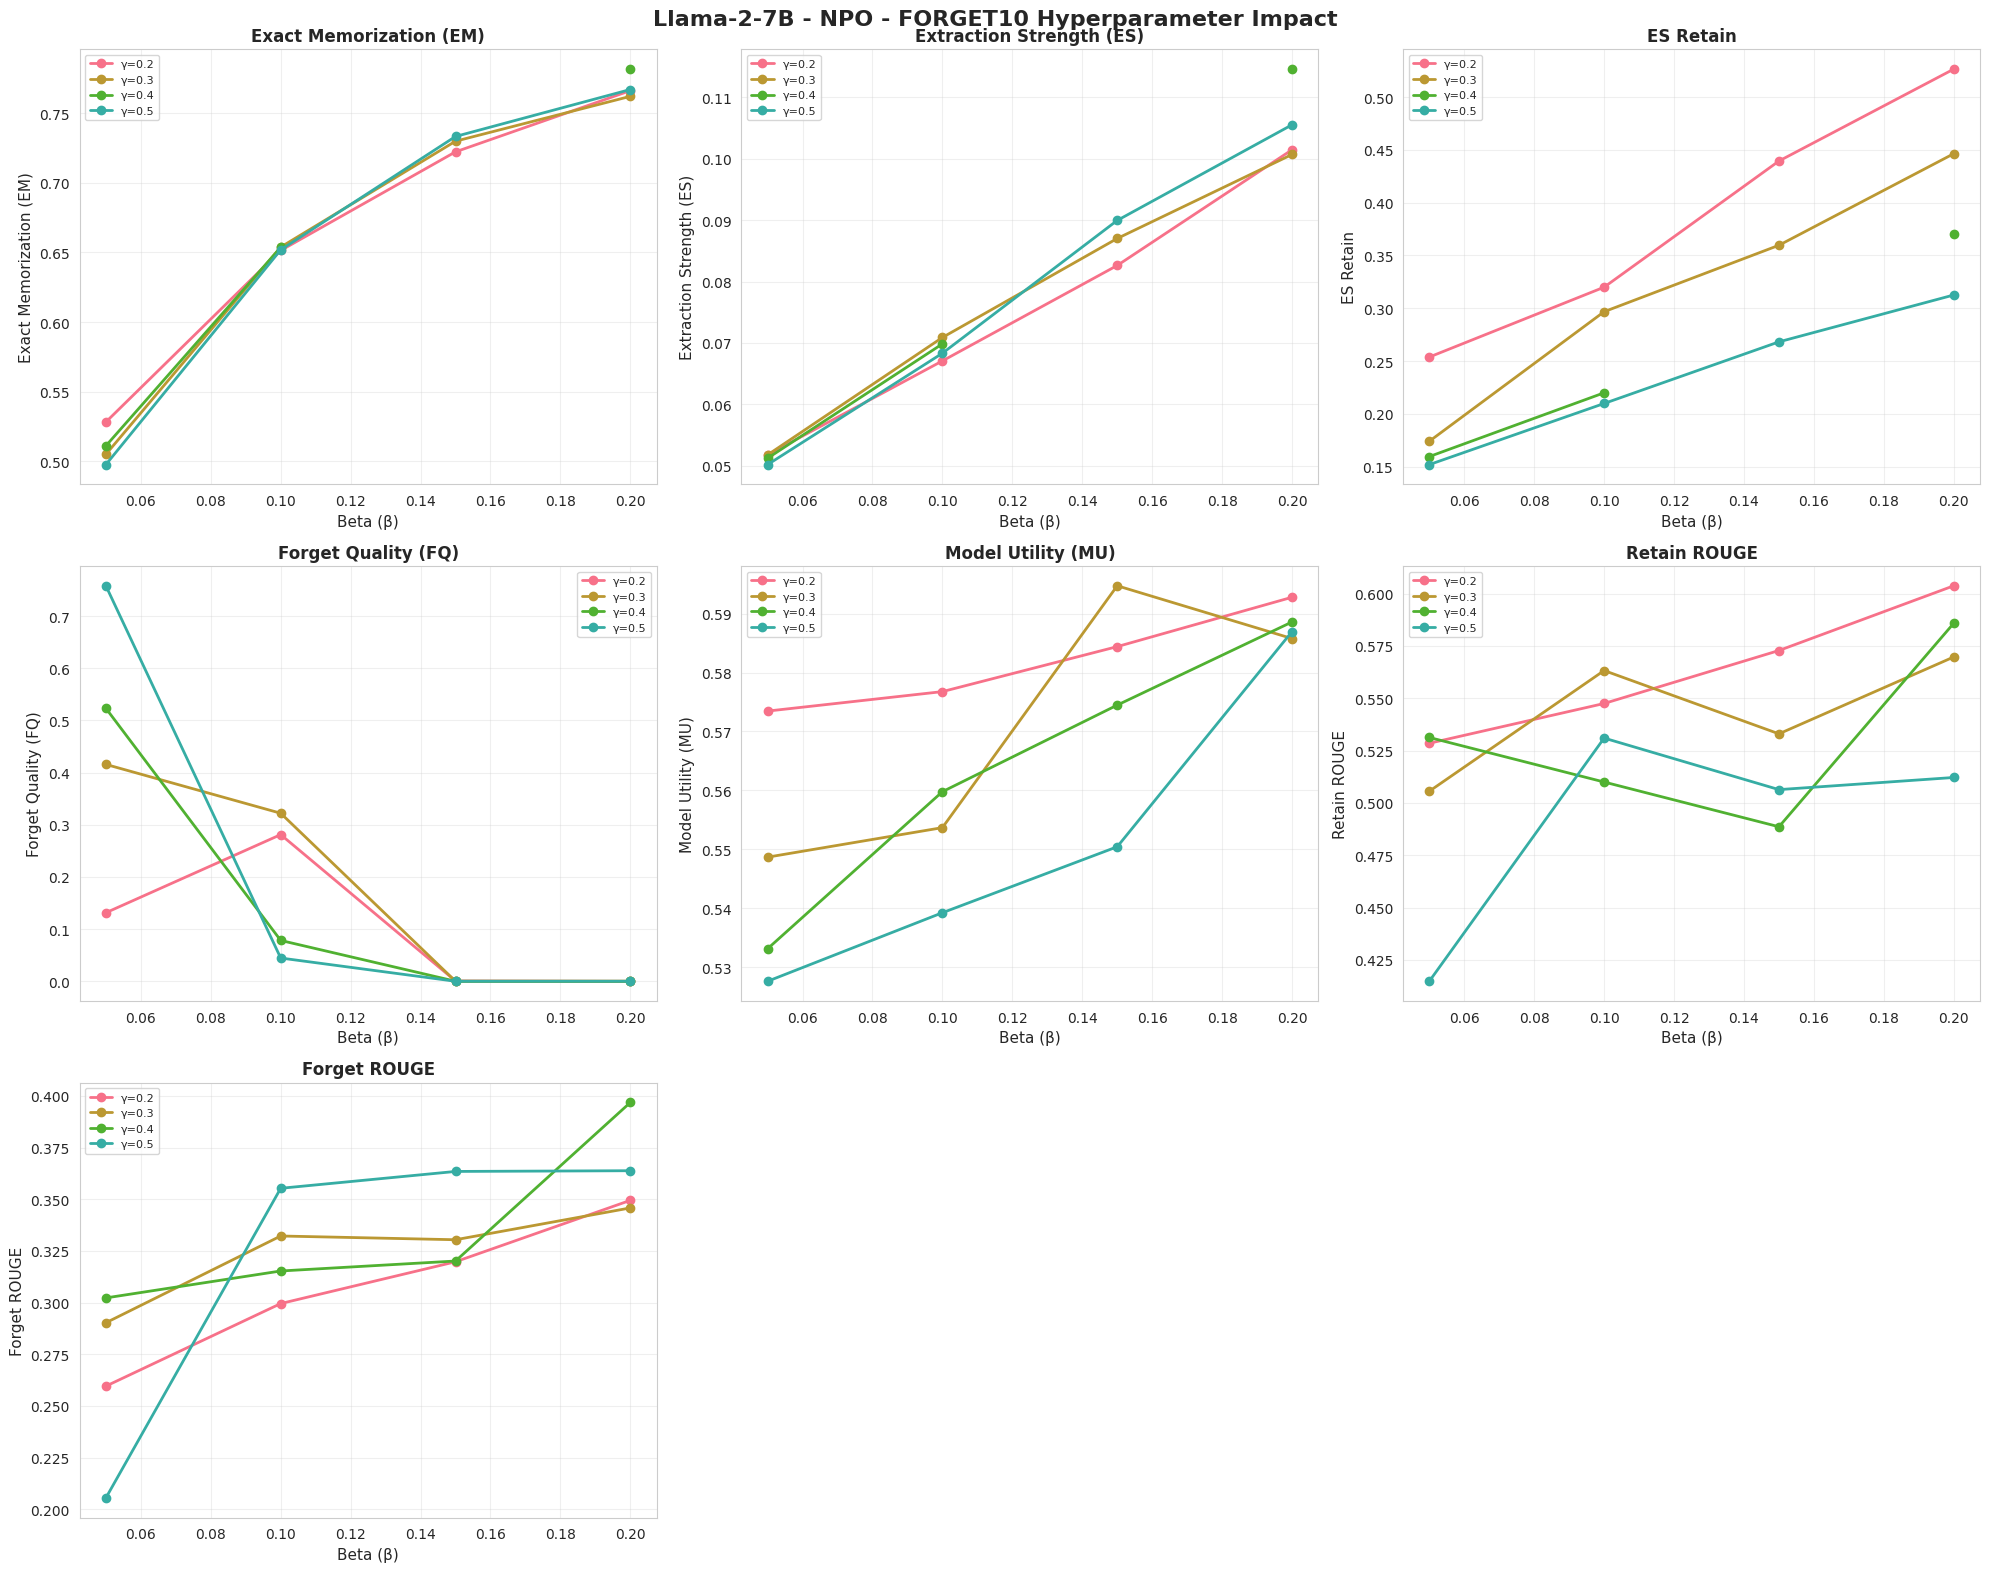

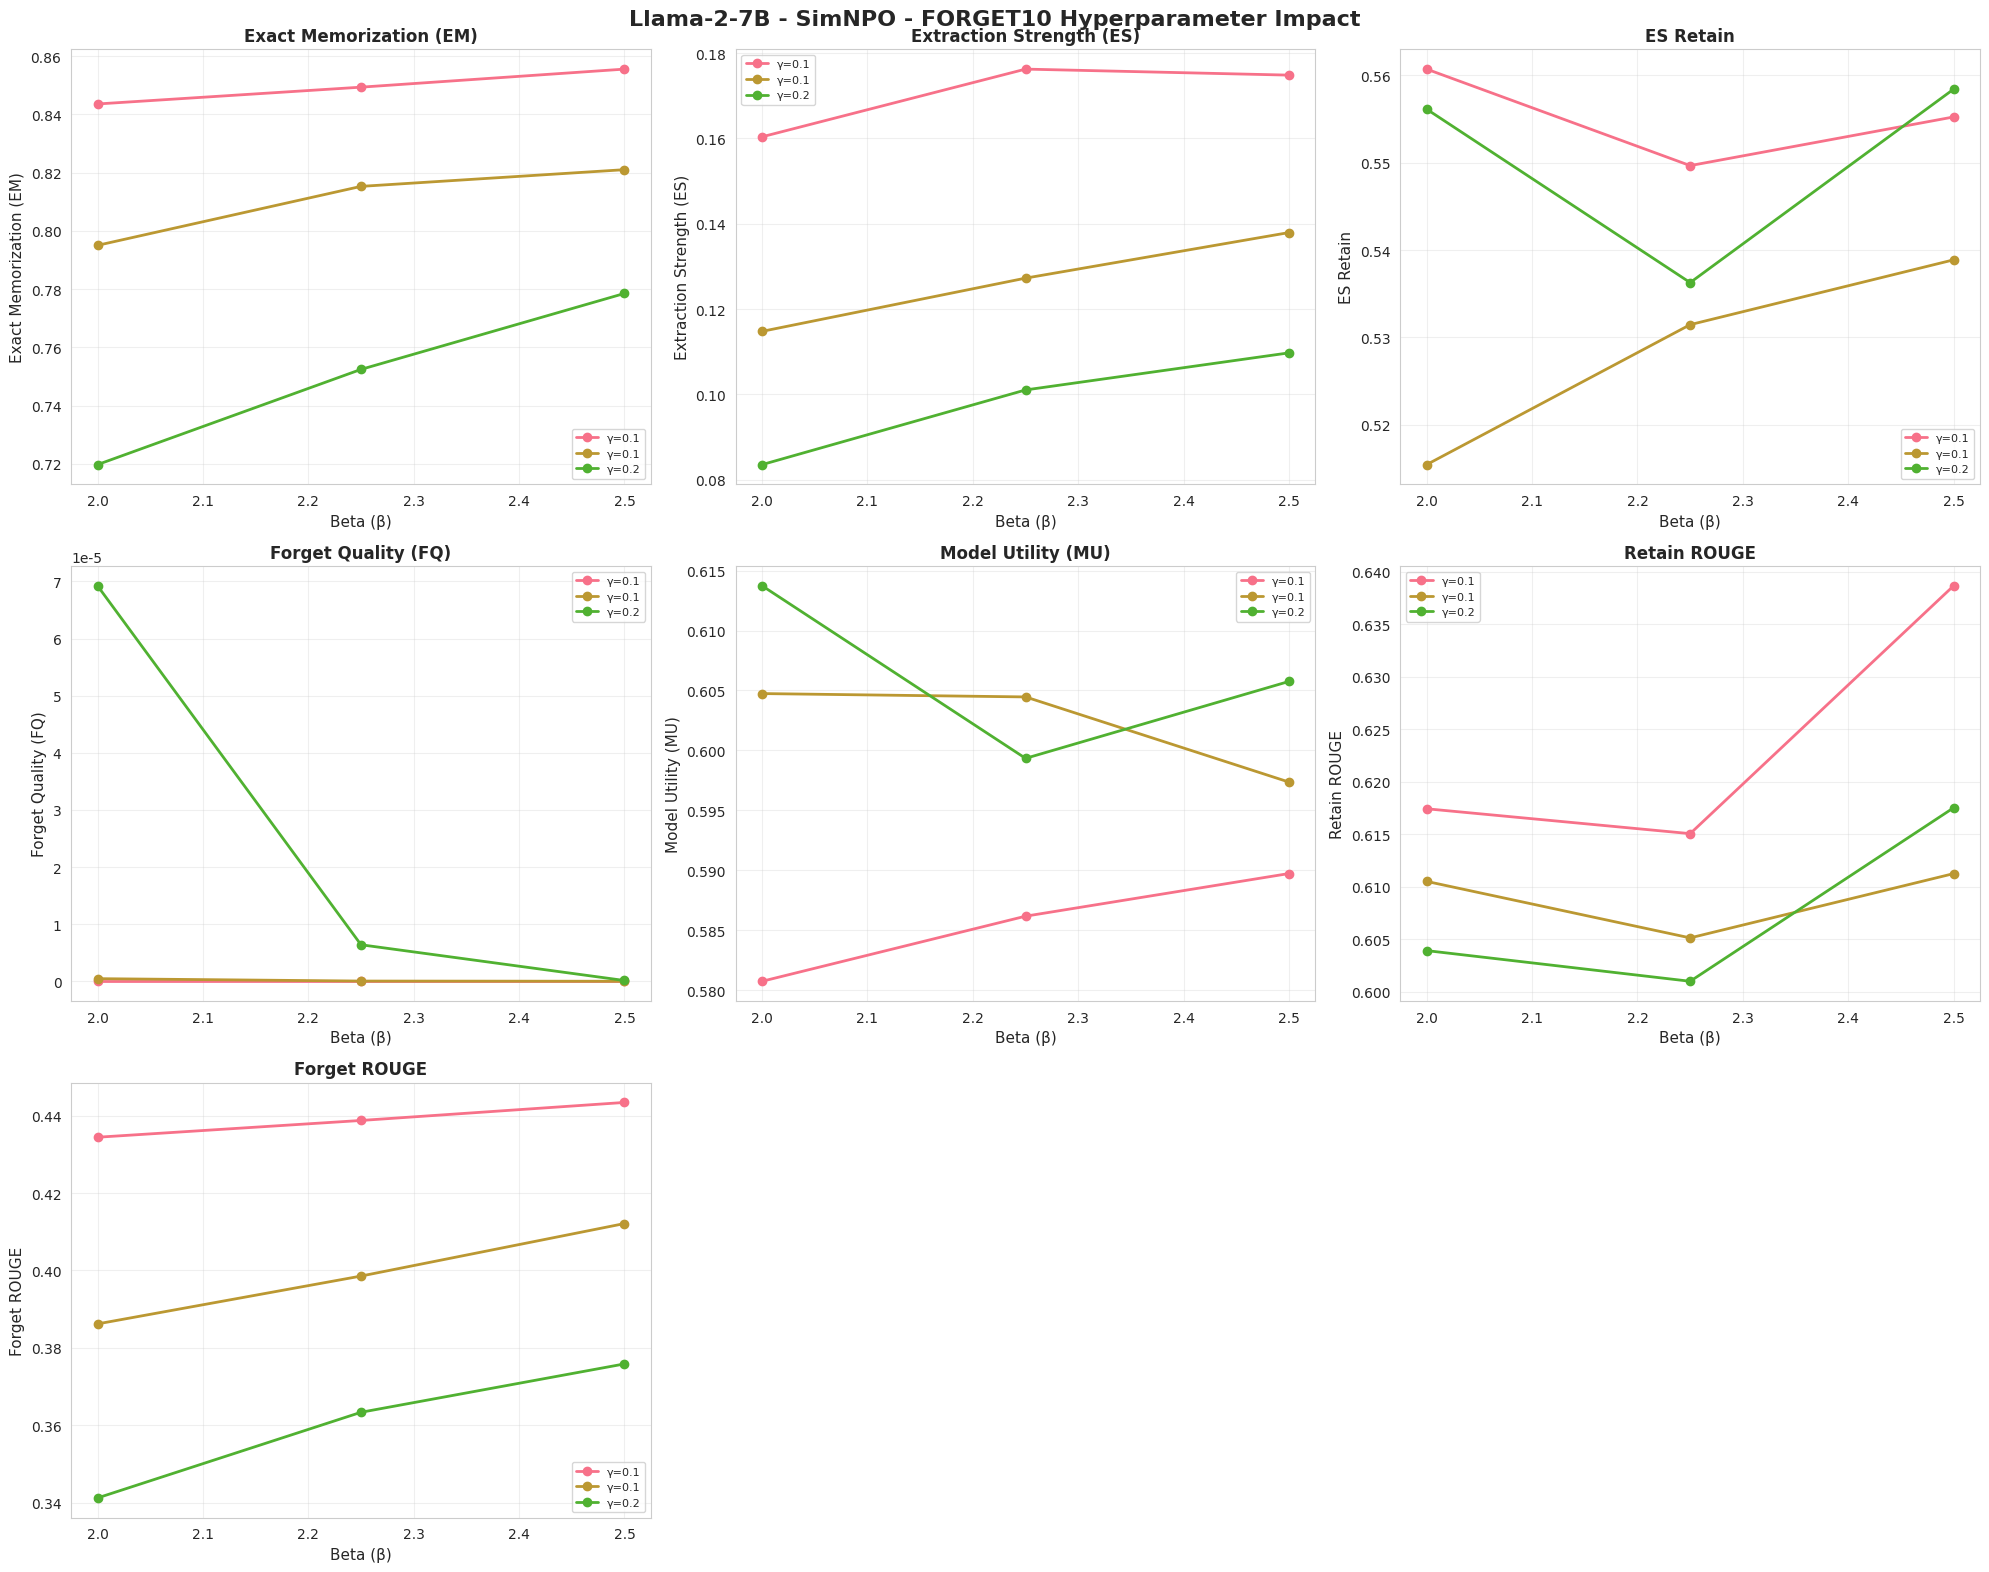

In [7]:
# Analyze hyperparameter impact for each method and forget set
for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        if len(method_df) < 2:
            continue
        
        # Check if beta and gamma exist
        has_beta = 'beta' in method_df.columns and method_df['beta'].notna().any()
        has_gamma = 'gamma' in method_df.columns and method_df['gamma'].notna().any()
        
        if not (has_beta or has_gamma):
            continue
        
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        axes = axes.flatten()
        fig.suptitle(f'{model_name} - {method} - {forget_set.upper()} Hyperparameter Impact', fontsize=16, fontweight='bold')
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            
            if has_beta and has_gamma:
                # Group by gamma and plot lines for different gamma values
                for gamma_val in sorted(method_df['gamma'].unique()):
                    gamma_df = method_df[method_df['gamma'] == gamma_val].sort_values('beta')
                    if len(gamma_df) > 0:
                        ax.plot(gamma_df['beta'], gamma_df[metric], 
                               marker='o', label=f'γ={gamma_val:.1f}', linewidth=2, markersize=6)
                ax.set_xlabel('Beta (β)', fontsize=11)
                ax.legend(loc='best', fontsize=8)
            elif has_beta:
                method_df_sorted = method_df.sort_values('beta')
                ax.plot(method_df_sorted['beta'], method_df_sorted[metric], 
                       marker='o', linewidth=2, markersize=8, color='#2E86AB')
                ax.set_xlabel('Beta (β)', fontsize=11)
            elif has_gamma:
                method_df_sorted = method_df.sort_values('gamma')
                ax.plot(method_df_sorted['gamma'], method_df_sorted[metric], 
                       marker='o', linewidth=2, markersize=8, color='#2E86AB')
                ax.set_xlabel('Gamma (γ)', fontsize=11)
            
            ax.set_ylabel(metric_labels[metric], fontsize=11)
            ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
        
        # Hide extra subplots
        for idx in range(len(metrics), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        # filename = f'/cnz/data/project/my-open-unlearning/notebooks/hyperparam_{method}_{forget_set}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        # print(f"Saved: {filename}")

## 5. Beta-Gamma Heatmaps (for methods with grid search)

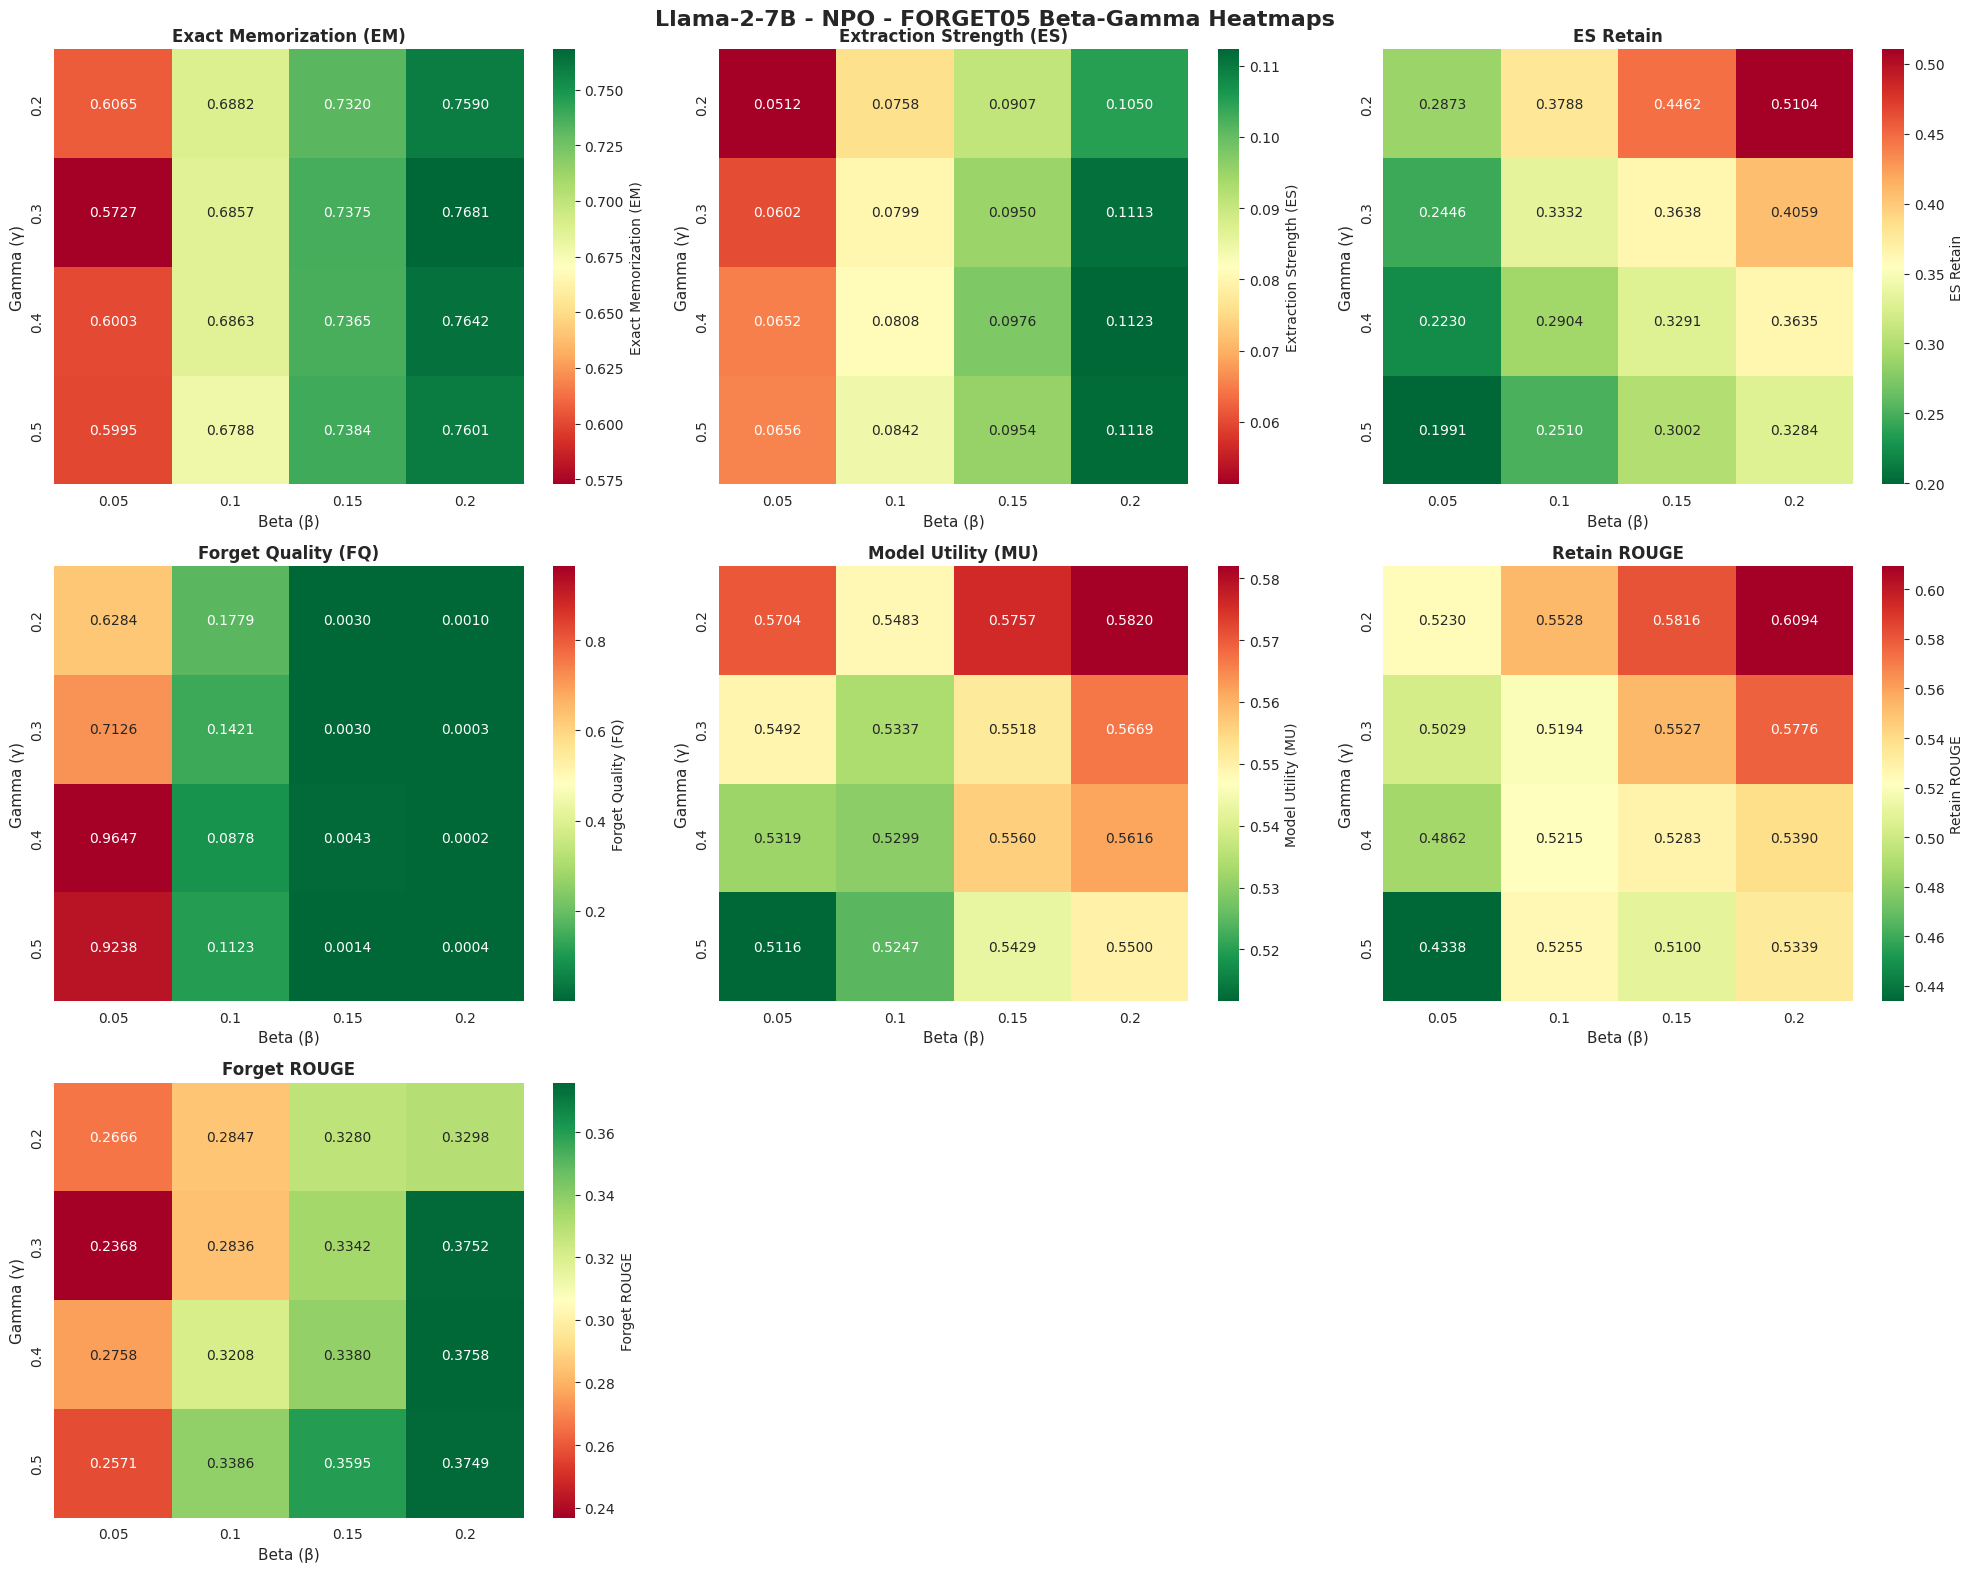

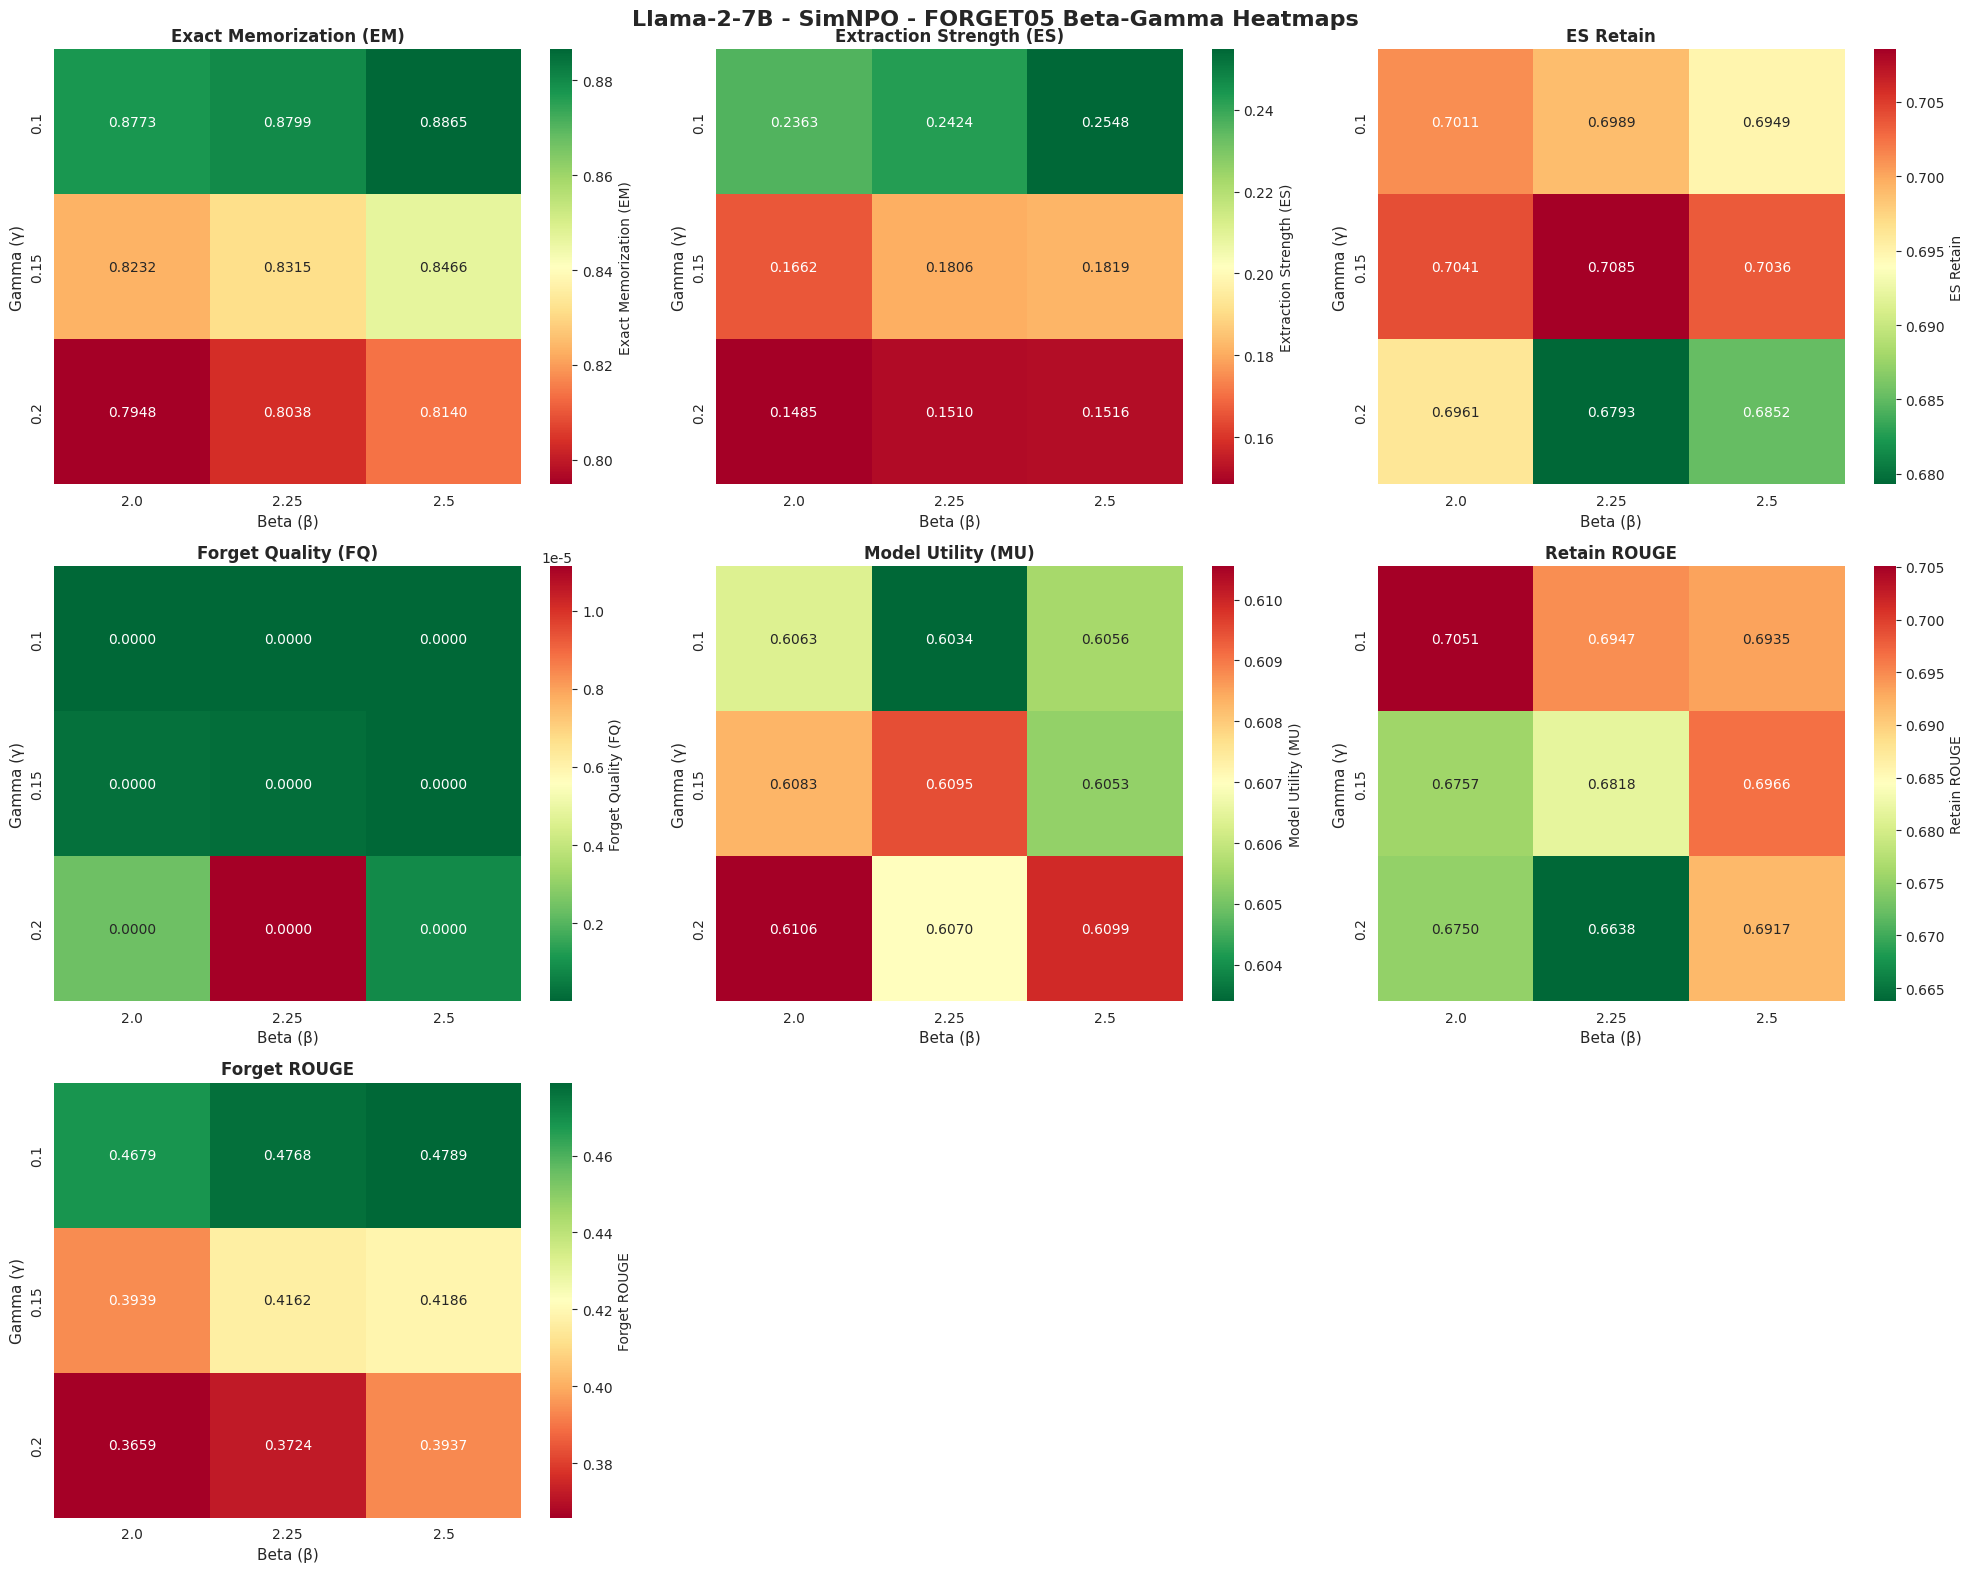

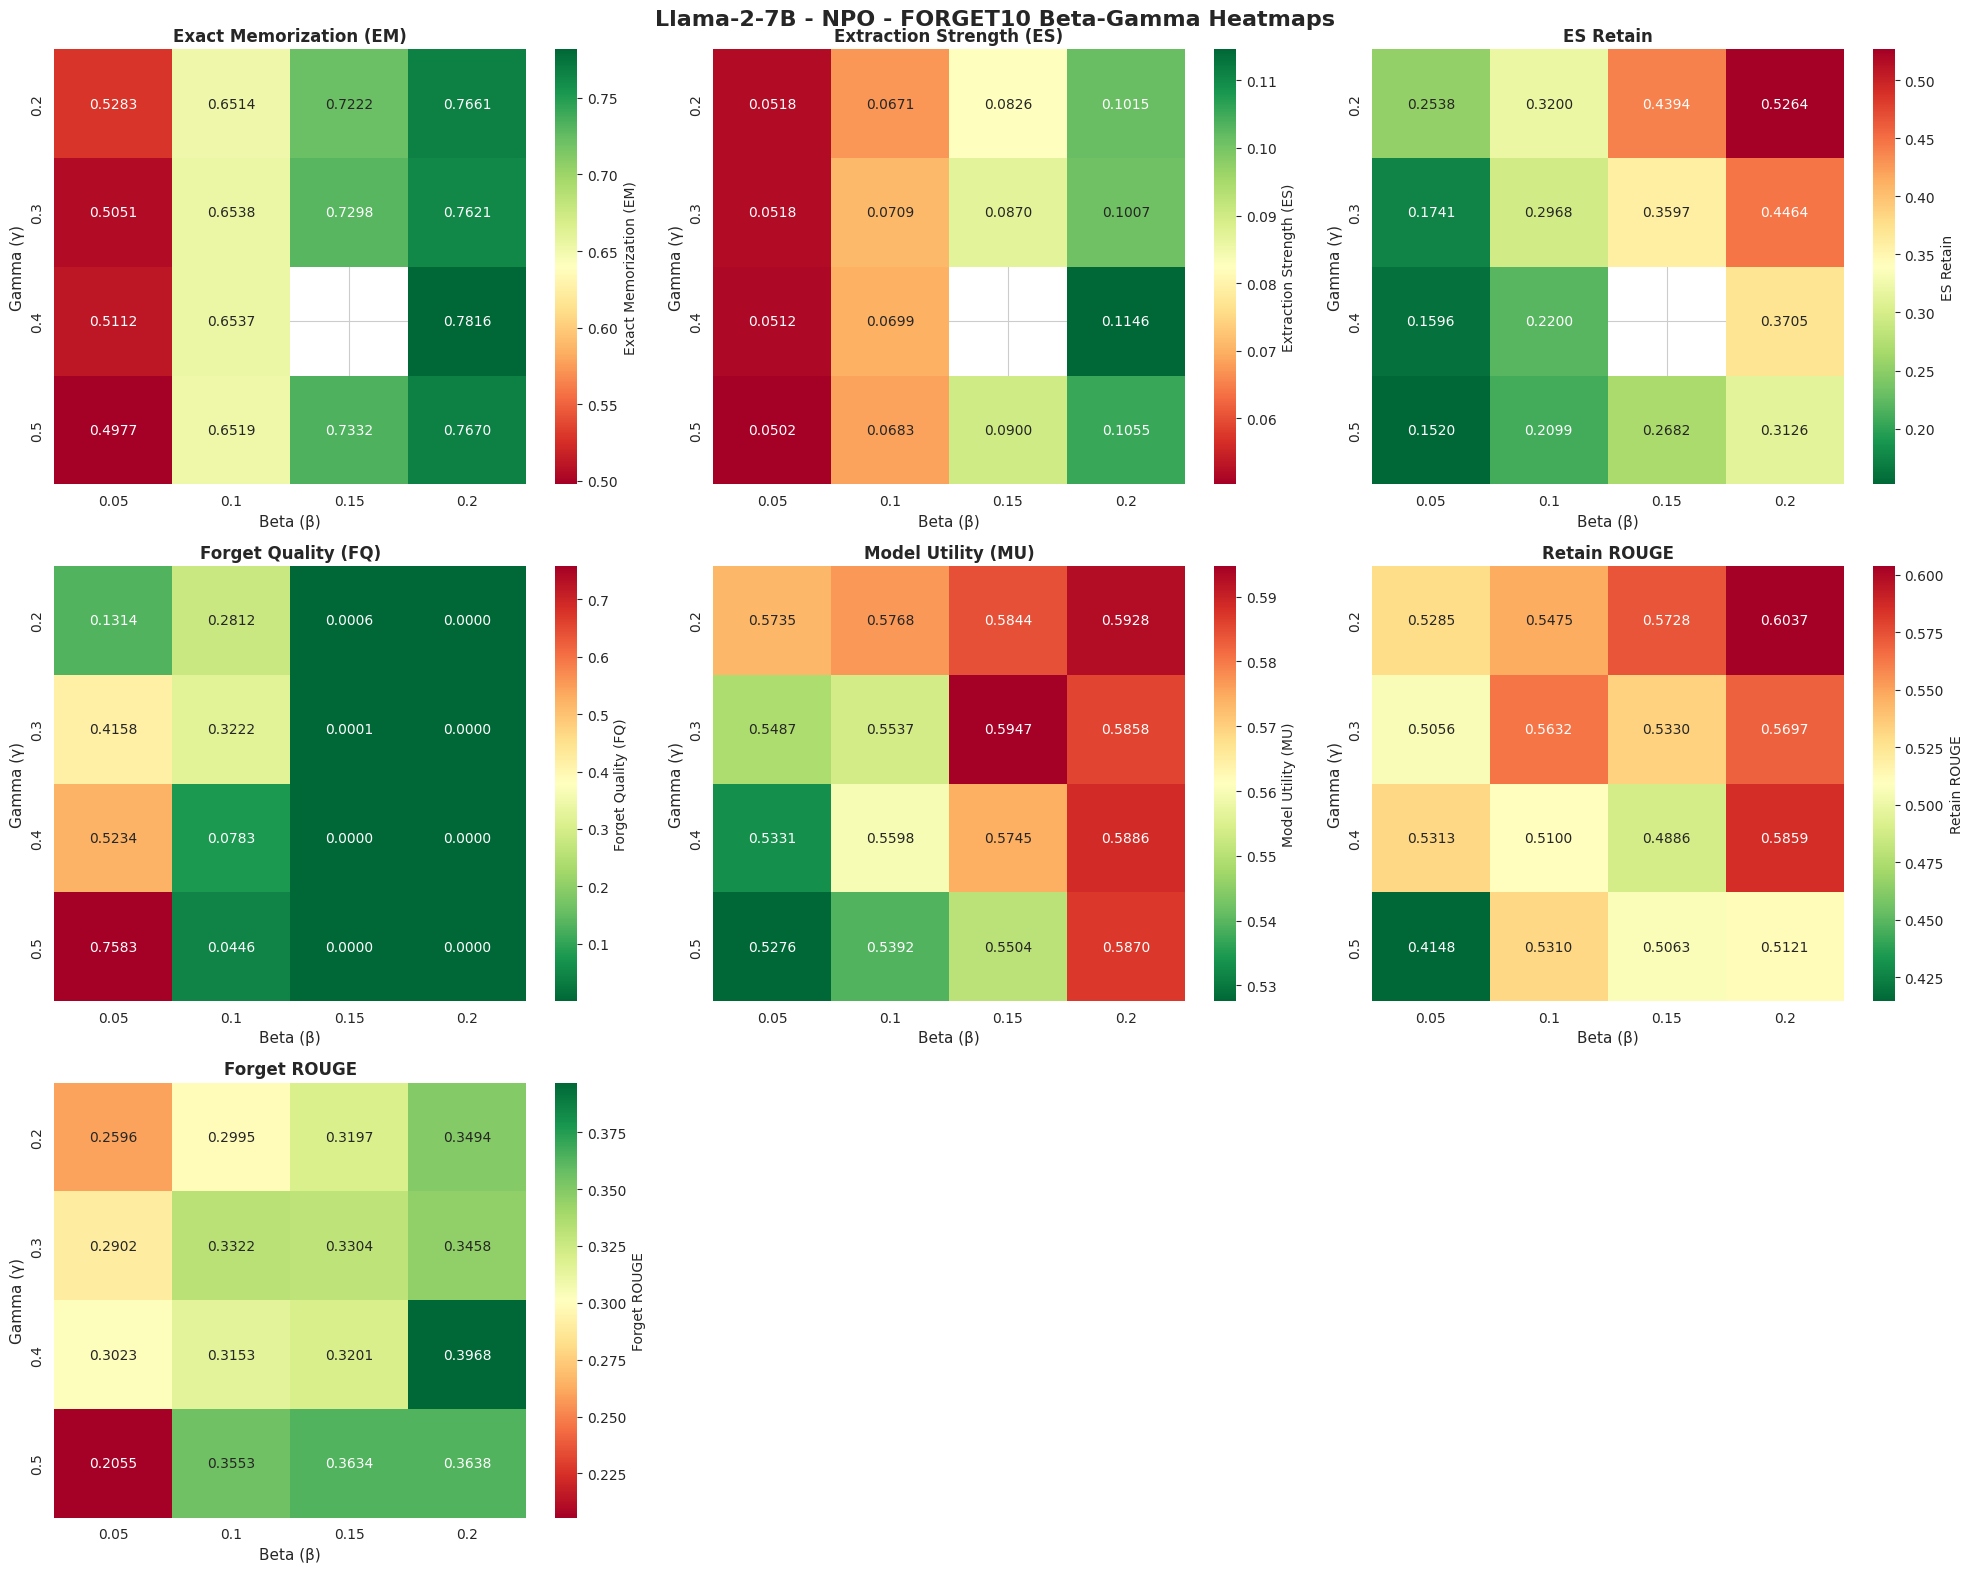

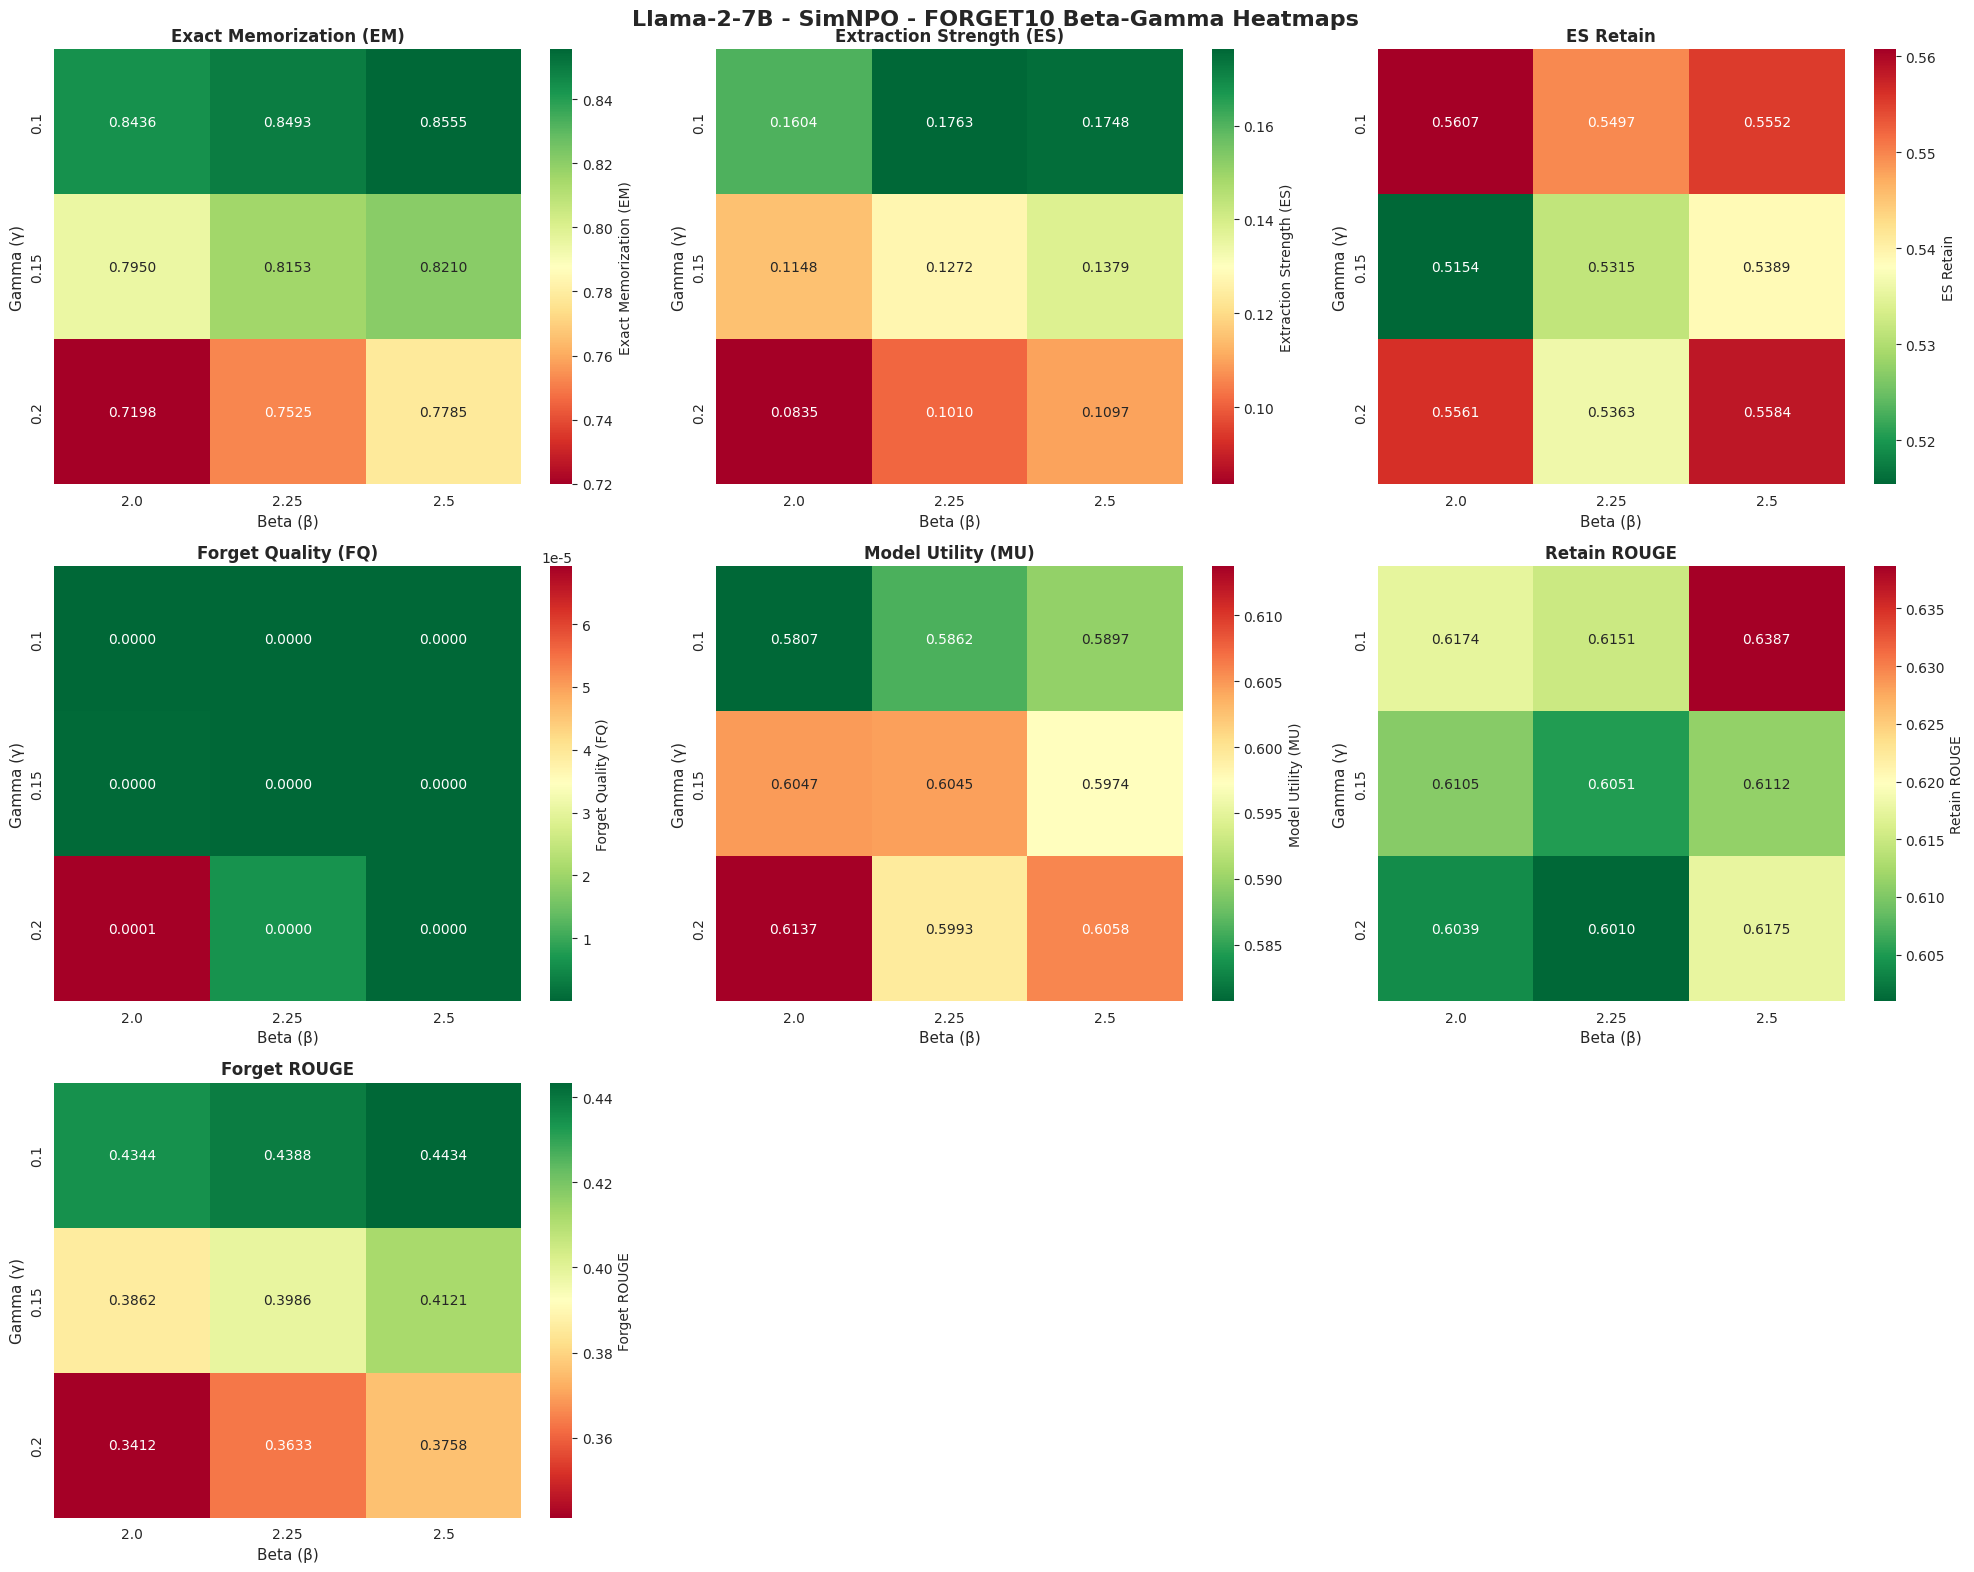

In [8]:
# Create heatmaps for methods with beta-gamma grid search
for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        if 'beta' not in method_df.columns or 'gamma' not in method_df.columns:
            continue
        
        # Filter for experiments with both beta and gamma
        grid_df = method_df[method_df['beta'].notna() & method_df['gamma'].notna()]
        
        if len(grid_df) < 4:  # Need at least 4 points for a meaningful heatmap
            continue
        
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        axes = axes.flatten()
        fig.suptitle(f'{model_name} - {method} - {forget_set.upper()} Beta-Gamma Heatmaps', fontsize=16, fontweight='bold')
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            
            # Create pivot table
            pivot_table = grid_df.pivot_table(
                values=metric,
                index='gamma',
                columns='beta',
                aggfunc='mean'
            )
            
            # Choose colormap based on metric (lower is better vs higher is better)
            if metric in ['exact_memorization', 'extraction_strength', 'forget_Q_A_ROUGE']:
                # Lower is better - use reverse colormap (red=high/bad, green=low/good)
                cmap = 'RdYlGn'
            else:
                # Higher is better - use normal colormap (green=high/good, red=low/bad)
                cmap = 'RdYlGn_r'
            
            # Plot heatmap
            sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap=cmap, 
                       ax=ax, cbar_kws={'label': metric_labels[metric]},
                       vmin=pivot_table.min().min(), vmax=pivot_table.max().max())
            ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
            ax.set_xlabel('Beta (β)', fontsize=11)
            ax.set_ylabel('Gamma (γ)', fontsize=11)
        
        # Hide extra subplots
        for idx in range(len(metrics), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        # filename = f'/cnz/data/project/my-open-unlearning/notebooks/heatmap_{method}_{forget_set}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        # print(f"Saved: {filename}")

## 6. Method Comparison


Average metric performance per method - FORGET05
        exact_memorization  extraction_strength  extraction_strength_retain  \
method                                                                        
NPO                 0.6946               0.0864                      0.3284   
SimNPO              0.8397               0.1904                      0.6969   

        forget_quality  model_utility  retain_Q_A_ROUGE  forget_Q_A_ROUGE  
method                                                                     
NPO             0.2352         0.5492            0.5311            0.3175  
SimNPO          0.0000         0.6073            0.6864            0.4205  


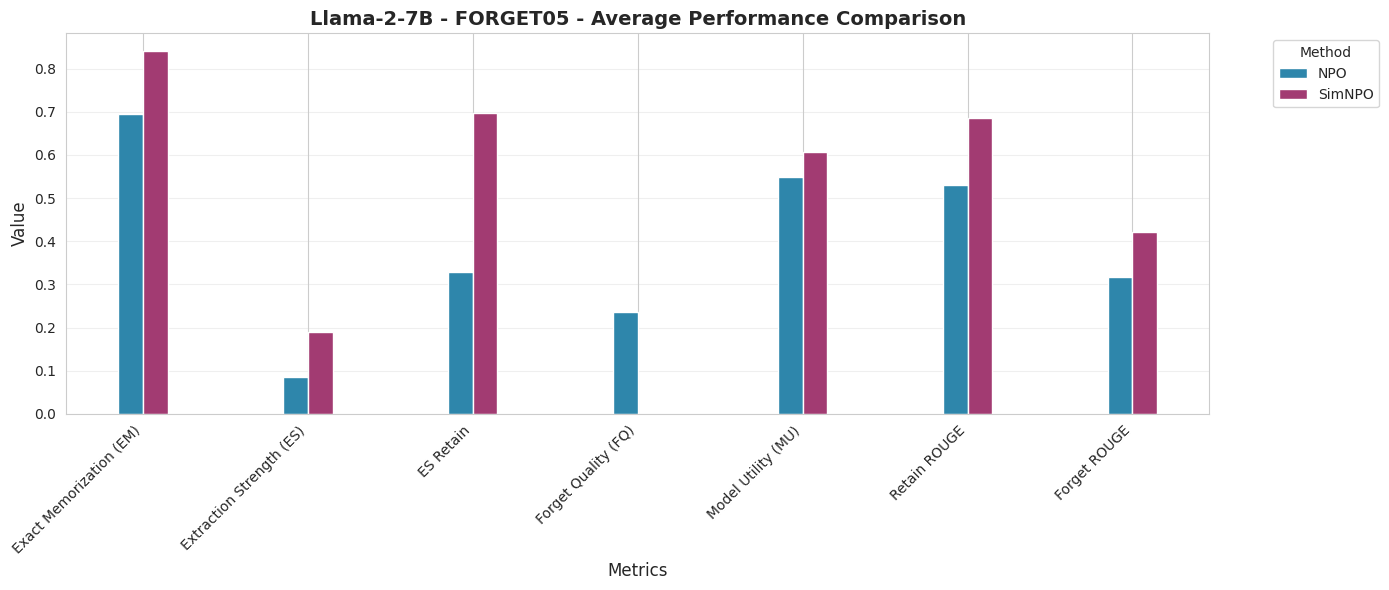


Average metric performance per method - FORGET10
        exact_memorization  extraction_strength  extraction_strength_retain  \
method                                                                        
NPO                 0.6610               0.0775                      0.3006   
SimNPO              0.8034               0.1317                      0.5447   

        forget_quality  model_utility  retain_Q_A_ROUGE  forget_Q_A_ROUGE  
method                                                                     
NPO             0.1597         0.5669            0.5315            0.3218  
SimNPO          0.0000         0.5980            0.6134            0.3993  


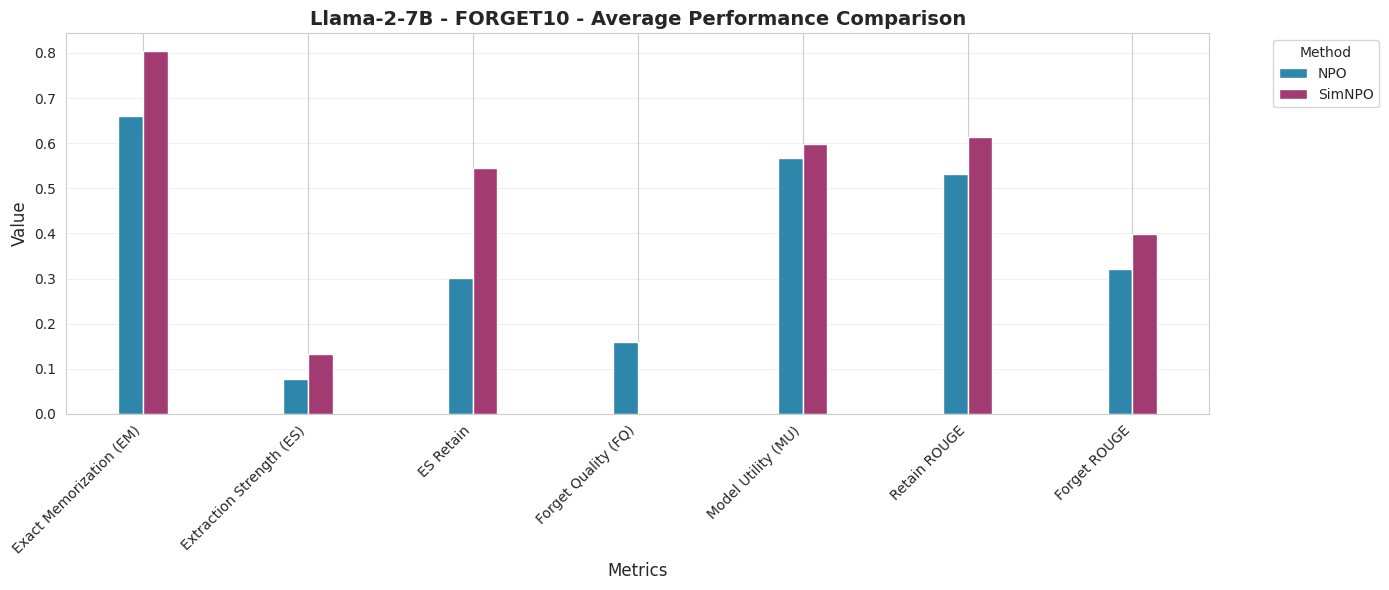

In [9]:
# Calculate average performance for each method and forget set
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set]
    method_performance = forget_df.groupby('method')[metrics].mean()
    
    print(f"\n{'='*60}")
    print(f"Average metric performance per method - {forget_set.upper()}")
    print('='*60)
    print(method_performance.round(4))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(metrics))
    width = 0.15
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    for i, method in enumerate(method_performance.index):
        offset = (i - len(method_performance) / 2 + 0.5) * width
        values = method_performance.loc[method, metrics].values
        ax.bar(x + offset, values, width, label=method, color=colors[i % len(colors)])
    
    ax.set_xlabel('Metrics', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(f'{model_name} - {forget_set.upper()} - Average Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([metric_labels[m] for m in metrics], rotation=45, ha='right')
    ax.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    # plt.savefig(f'/cnz/data/project/my-open-unlearning/notebooks/method_comparison_{forget_set}.png', 
    #            dpi=300, bbox_inches='tight')
    plt.show()

## 7. Composite Score Analysis (ES + MU Only)

Best configuration selection based on:
- **50% Model Utility (MU)** - Higher is better
- **50% Extraction Strength (ES)** - Lower is better

In [10]:
# Create composite score: normalize metrics and weight them
# SIMPLIFIED: Using only ES and MU
# Higher is better: model_utility
# Lower is better: extraction_strength
from sklearn.preprocessing import MinMaxScaler

# Process each forget set separately
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    scaler = MinMaxScaler()
    
    # For metrics where higher is better
    forget_df['model_utility_norm'] = scaler.fit_transform(forget_df[['model_utility']])
    
    # For metrics where lower is better (invert)
    forget_df['extraction_strength_norm'] = 1 - scaler.fit_transform(forget_df[['extraction_strength']])
    
    # Calculate composite score using only ES and MU
    # ES: 50% weight (lower is better, so we use inverted normalized value)
    # MU: 50% weight (higher is better)
    forget_df['composite_score'] = (
        forget_df['model_utility_norm'] * 0.5 + 
        forget_df['extraction_strength_norm'] * 0.5
    )
    
    # Update main dataframe
    df.loc[df['forget_set'] == forget_set, 'composite_score'] = forget_df['composite_score'].values
    
    # Display Top 10 configurations
    top_configs = forget_df.nlargest(10, 'composite_score')[[
        'dir_name', 'method', 'forget_set', 'beta', 'gamma', 'composite_score',
        'model_utility', 'extraction_strength'
    ]]
    
    print(f"\n{'='*80}")
    print(f"Top 10 Configurations by Composite Score (ES+MU) - {forget_set.upper()}")
    print('='*80)
    print(f"Criteria: 50% Model Utility (higher is better) + 50% Extraction Strength (lower is better)")
    print(top_configs.to_string(index=False))


Top 10 Configurations by Composite Score (ES+MU) - FORGET05
Criteria: 50% Model Utility (higher is better) + 50% Extraction Strength (lower is better)
                                                         dir_name method forget_set  beta  gamma  composite_score  model_utility  extraction_strength
    tofu_Llama-2-7b-chat-hf_forget05_NPO_beta0.05_gamma0.2_epoch5    NPO   forget05  0.05   0.20         0.796922       0.570381             0.051202
  tofu_Llama-2-7b-chat-hf_forget05_SimNPO_beta2.0_gamma0.2_epoch5 SimNPO   forget05  2.00   0.20         0.761100       0.610552             0.148467
  tofu_Llama-2-7b-chat-hf_forget05_SimNPO_beta2.5_gamma0.2_epoch5 SimNPO   forget05  2.50   0.20         0.750134       0.609920             0.151630
 tofu_Llama-2-7b-chat-hf_forget05_SimNPO_beta2.25_gamma0.2_epoch5 SimNPO   forget05  2.25   0.20         0.736824       0.606978             0.150994
    tofu_Llama-2-7b-chat-hf_forget05_NPO_beta0.15_gamma0.2_epoch5    NPO   forget05  0.15   0.20  

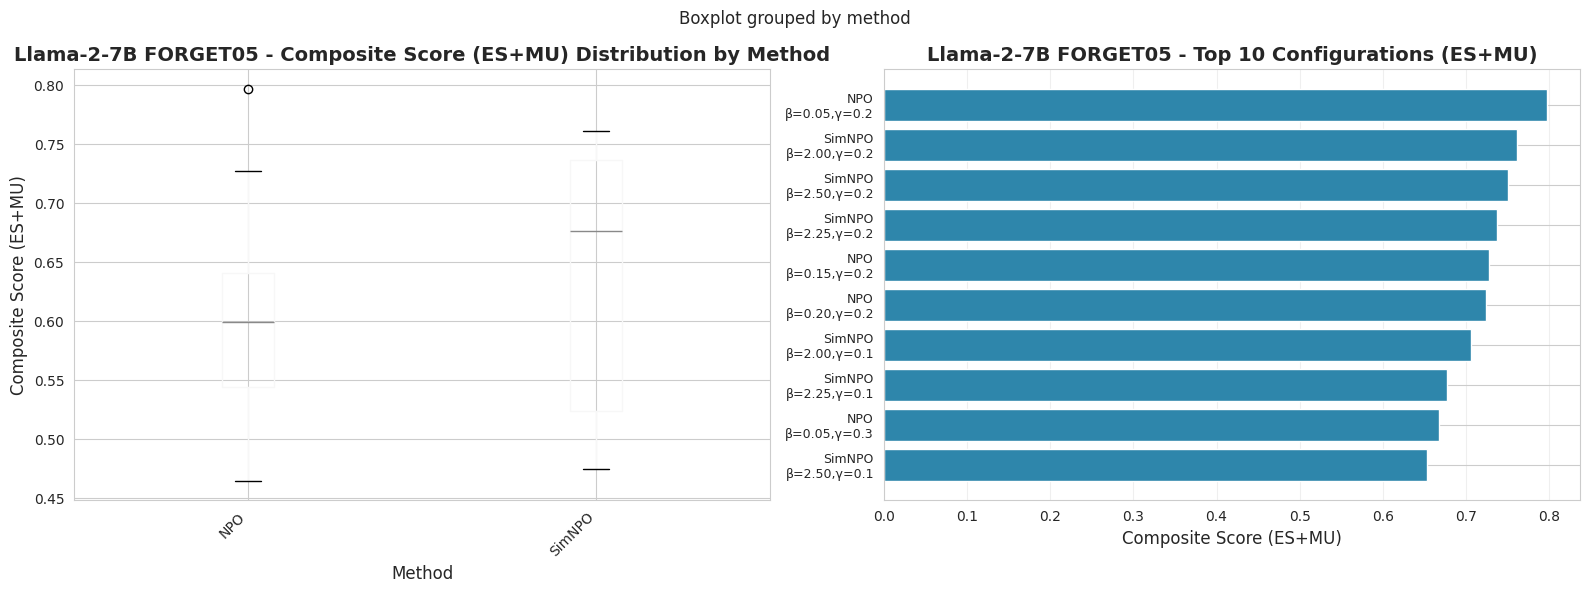

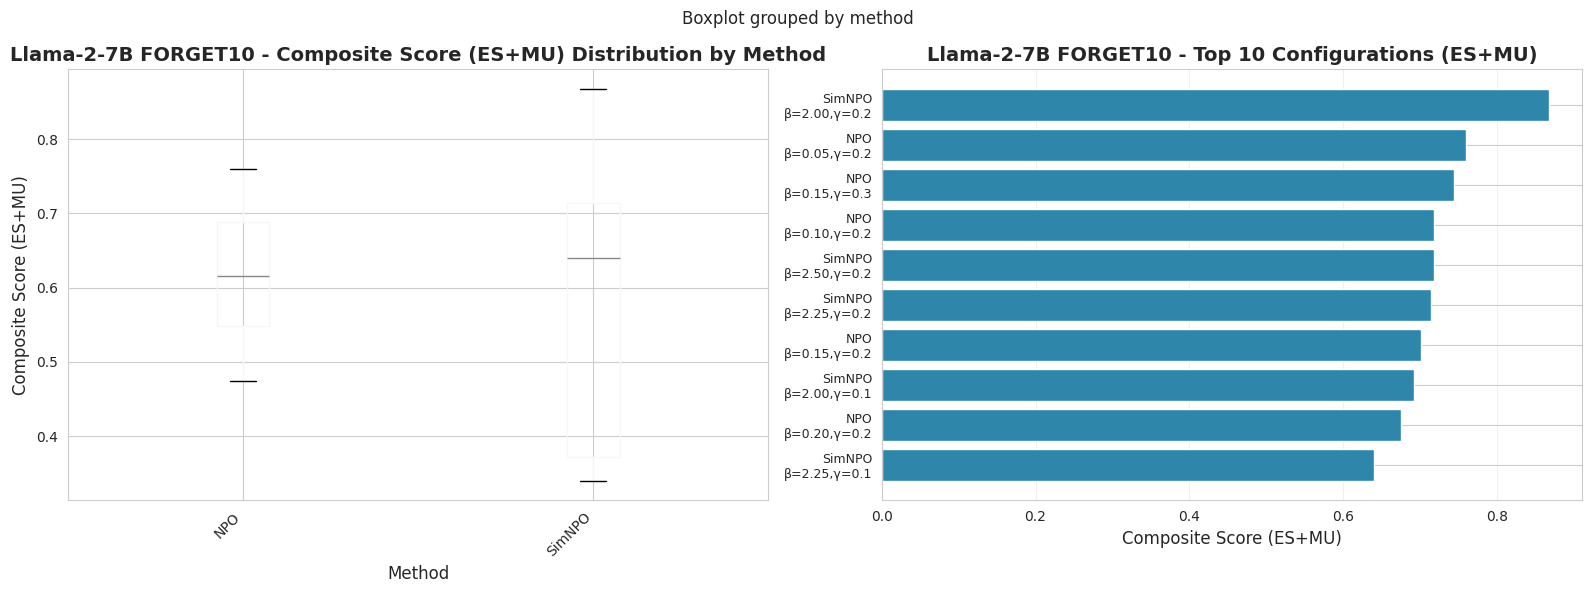

In [11]:
# Visualize composite score distribution for each forget set
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Boxplot by method
    forget_df.boxplot(column='composite_score', by='method', ax=axes[0])
    axes[0].set_title(f'{model_name} {forget_set.upper()} - Composite Score (ES+MU) Distribution by Method', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Method', fontsize=12)
    axes[0].set_ylabel('Composite Score (ES+MU)', fontsize=12)
    plt.sca(axes[0])
    plt.xticks(rotation=45, ha='right')
    
    # Top 10 configurations bar chart
    top_10 = forget_df.nlargest(10, 'composite_score')
    y_pos = range(len(top_10))
    axes[1].barh(y_pos, top_10['composite_score'], color='#2E86AB')
    axes[1].set_yticks(y_pos)
    
    # Create labels with method and hyperparameters
    labels = []
    for _, row in top_10.iterrows():
        label = f"{row['method']}"
        if 'beta' in row and pd.notna(row['beta']):
            label += f"\nβ={row['beta']:.2f}"
        if 'gamma' in row and pd.notna(row['gamma']):
            label += f",γ={row['gamma']:.1f}"
        labels.append(label)
    
    axes[1].set_yticklabels(labels, fontsize=9)
    axes[1].set_xlabel('Composite Score (ES+MU)', fontsize=12)
    axes[1].set_title(f'{model_name} {forget_set.upper()} - Top 10 Configurations (ES+MU)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    axes[1].invert_yaxis()  # Best on top
    
    plt.tight_layout()
    # plt.savefig(f'/cnz/data/project/my-open-unlearning/notebooks/composite_score_{forget_set}.png', 
    #            dpi=300, bbox_inches='tight')
    plt.show()

## 9. Export Detailed Results

In [12]:
# Create comprehensive comparison of best vs worst configurations
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    print(f"\n{'='*100}")
    print(f"BEST vs WORST COMPARISON - {forget_set.upper()}")
    print('='*100)
    
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        
        if len(method_df) < 2:
            continue
        
        best = method_df.nlargest(1, 'composite_score').iloc[0]
        worst = method_df.nsmallest(1, 'composite_score').iloc[0]
        
        print(f"\n{method} Method:")
        print("-" * 80)
        
        # Hyperparameters comparison
        print("  Hyperparameters:")
        if 'beta' in best and pd.notna(best['beta']):
            print(f"    Beta:  Best={best['beta']:.3f}  |  Worst={worst['beta']:.3f}")
        if 'gamma' in best and pd.notna(best['gamma']):
            print(f"    Gamma: Best={best['gamma']:.3f}  |  Worst={worst['gamma']:.3f}")
        
        print(f"\n  Metrics Comparison (Primary: ES & MU):")
        print(f"    {'Metric':<30s} | {'Best':>10s} | {'Worst':>10s} | {'Δ':>10s} | {'Goal':>5s}")
        print(f"    {'-'*30} | {'-'*10} | {'-'*10} | {'-'*10} | {'-'*5}")
        
        # Show ES and MU first
        priority_metrics = ['extraction_strength', 'model_utility']
        other_metrics = [m for m in metrics if m not in priority_metrics]
        
        for m in priority_metrics + other_metrics:
            delta = best[m] - worst[m]
            goal = "↑" if m in ['forget_quality', 'model_utility', 'retain_Q_A_ROUGE', 'extraction_strength_retain'] else "↓"
            marker = " ***" if m in priority_metrics else ""
            print(f"    {metric_labels[m]:<30s} | {best[m]:>10.4f} | {worst[m]:>10.4f} | {delta:>+10.4f} | {goal:>5s}{marker}")
        
        print(f"\n  Composite Score (ES+MU): {best['composite_score']:.4f} (best) vs {worst['composite_score']:.4f} (worst)")
        print(f"  Improvement: {((best['composite_score'] - worst['composite_score']) / worst['composite_score'] * 100):+.2f}%")


BEST vs WORST COMPARISON - FORGET05

NPO Method:
--------------------------------------------------------------------------------
  Hyperparameters:
    Beta:  Best=0.050  |  Worst=0.050
    Gamma: Best=0.200  |  Worst=0.500

  Metrics Comparison (Primary: ES & MU):
    Metric                         |       Best |      Worst |          Δ |  Goal
    ------------------------------ | ---------- | ---------- | ---------- | -----
    Extraction Strength (ES)       |     0.0512 |     0.0656 |    -0.0144 |     ↓ ***
    Model Utility (MU)             |     0.5704 |     0.5116 |    +0.0587 |     ↑ ***
    Exact Memorization (EM)        |     0.6065 |     0.5995 |    +0.0069 |     ↓
    ES Retain                      |     0.2873 |     0.1991 |    +0.0881 |     ↑
    Forget Quality (FQ)            |     0.6284 |     0.9238 |    -0.2954 |     ↑
    Retain ROUGE                   |     0.5230 |     0.4338 |    +0.0892 |     ↑
    Forget ROUGE                   |     0.2666 |     0.2571 |    +0

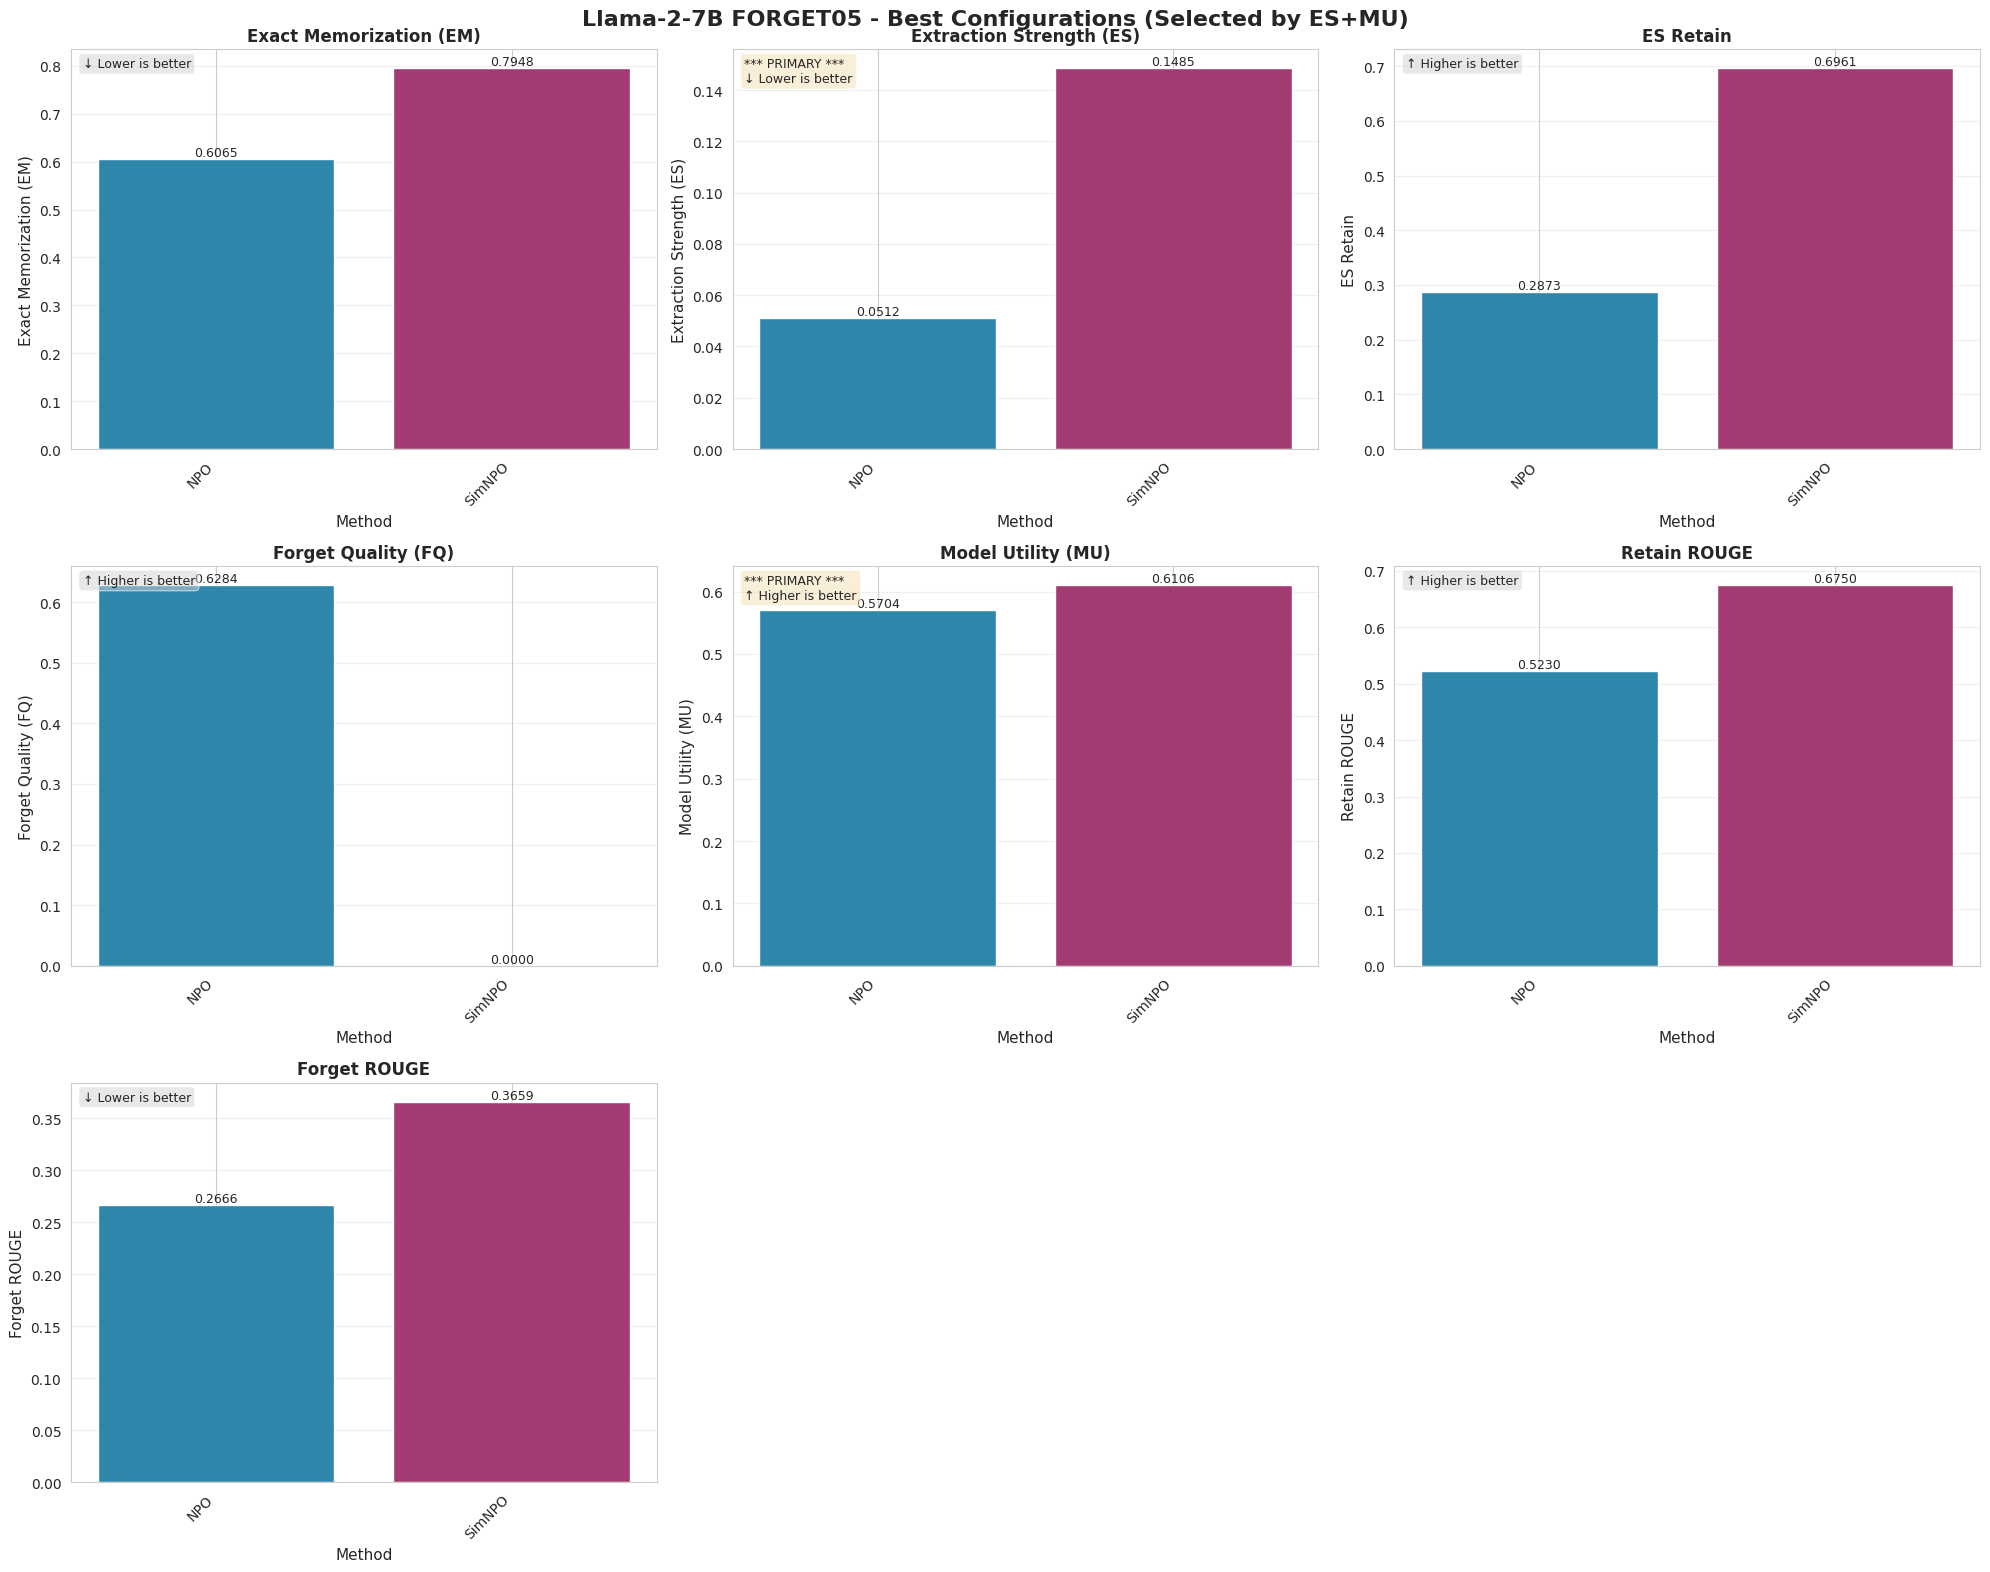


Llama-2-7B - BEST CONFIGURATIONS SUMMARY (Selected by ES+MU) - FORGET05
method  beta  gamma  composite_score  model_utility  extraction_strength  extraction_strength_retain  forget_quality  retain_Q_A_ROUGE  forget_Q_A_ROUGE  exact_memorization
   NPO  0.05    0.2         0.796922       0.570381             0.051202                    0.287254        0.628431          0.523017          0.266612            0.606451
SimNPO  2.00    0.2         0.761100       0.610552             0.148467                    0.696092        0.000002          0.674992          0.365870            0.794834


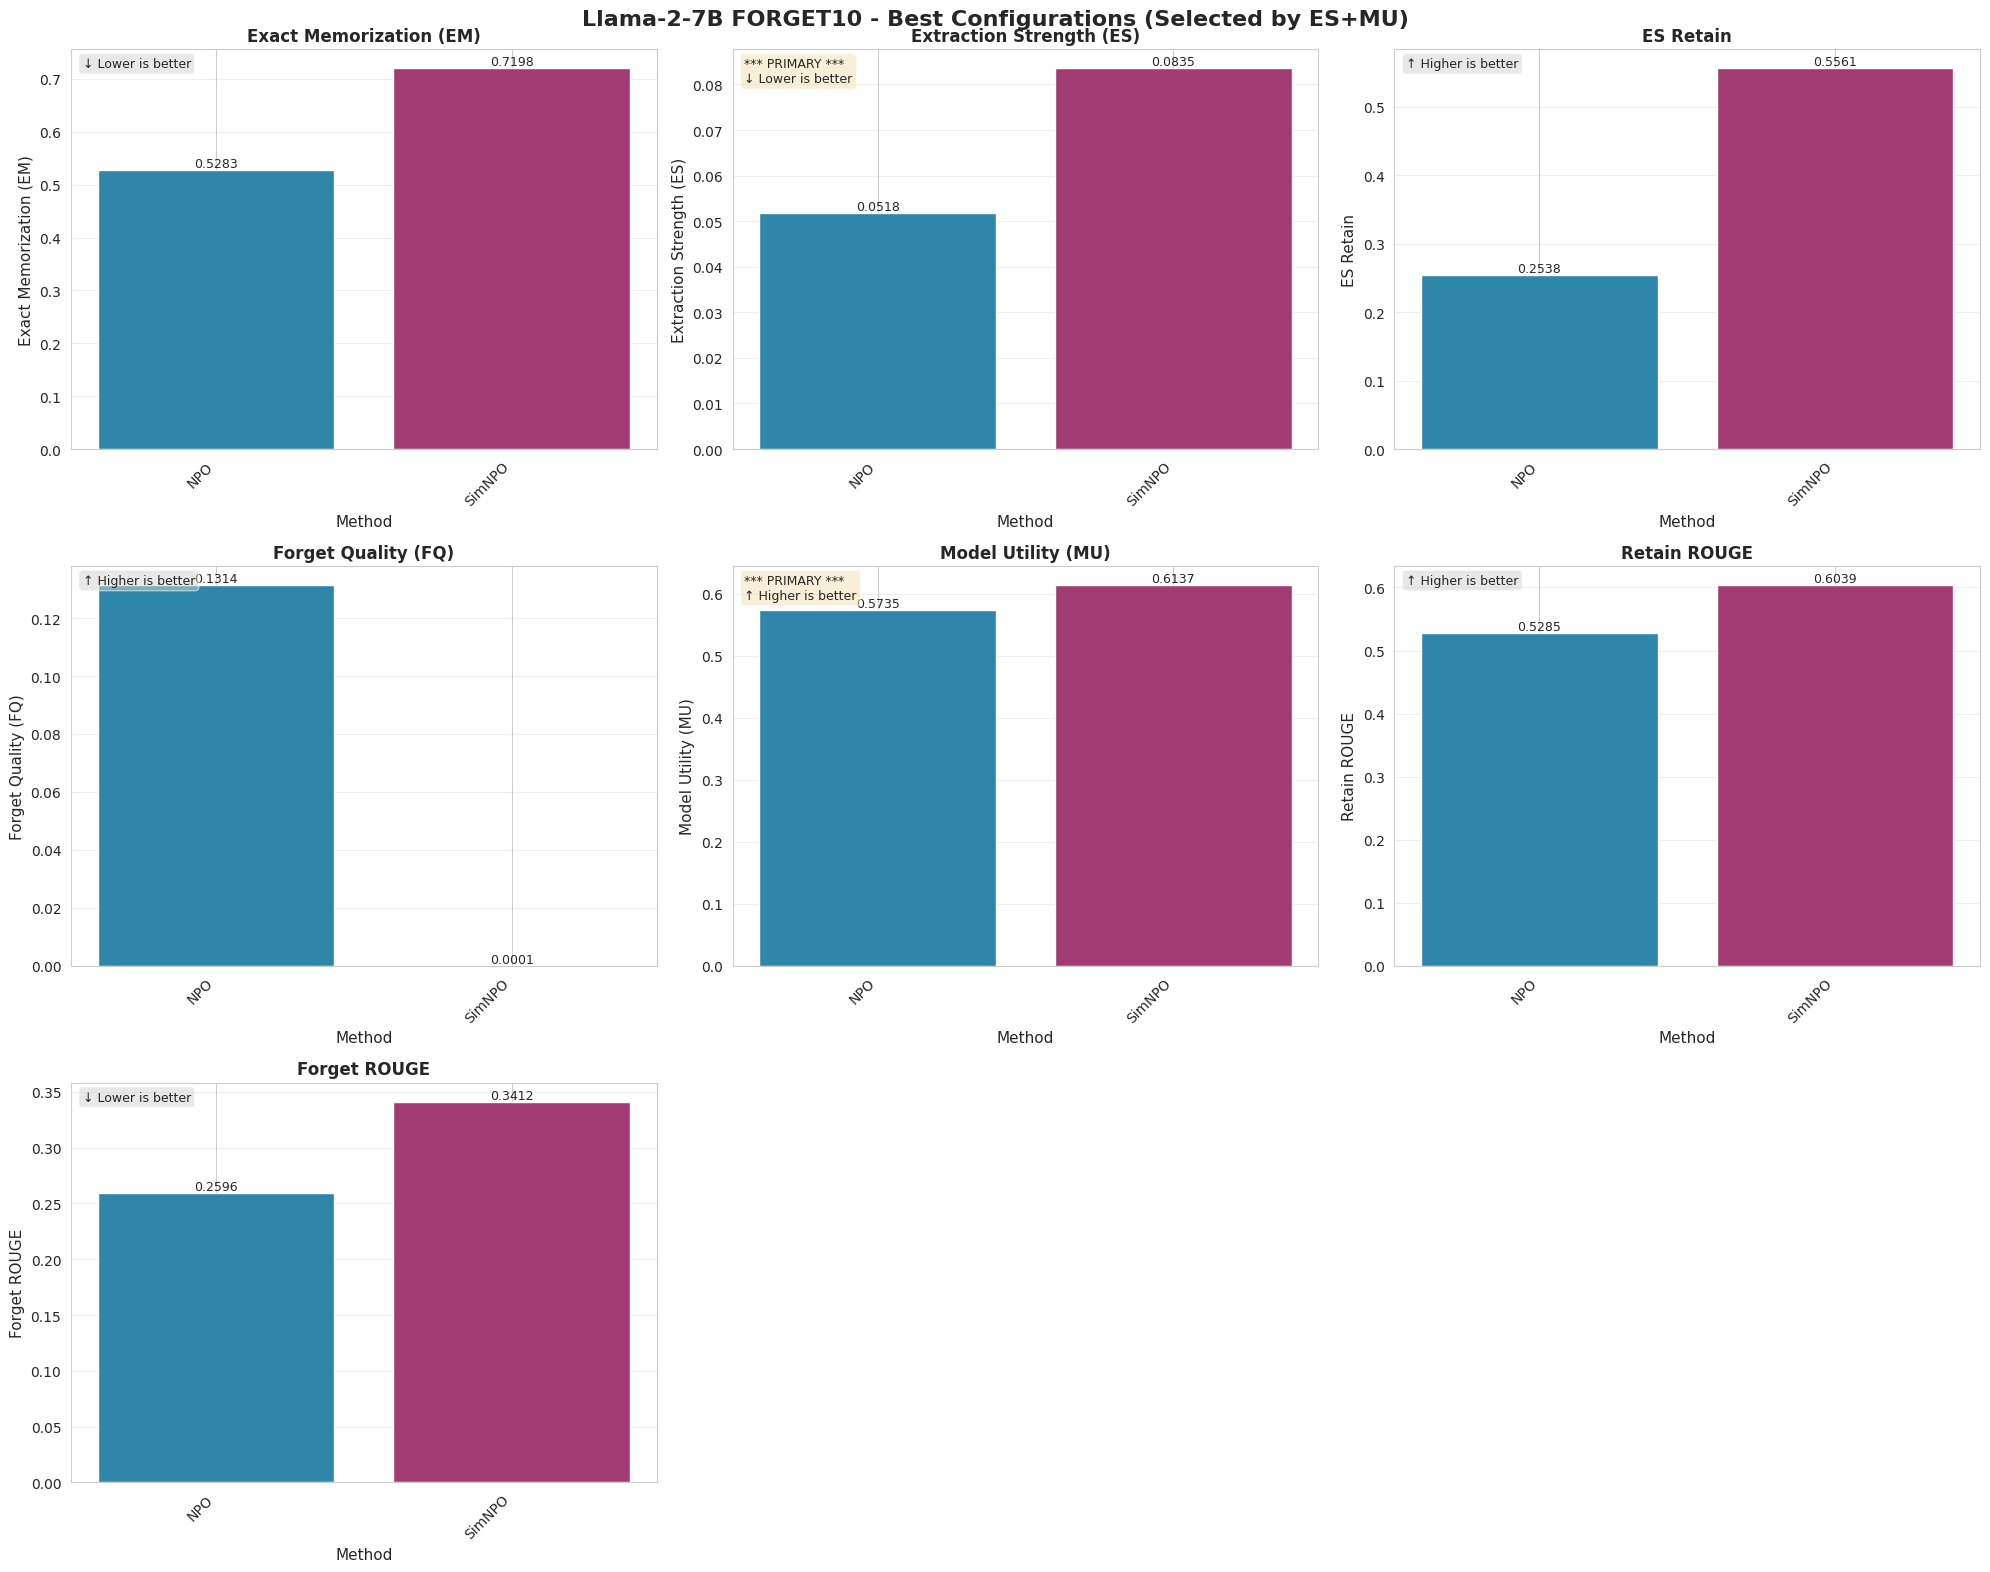


Llama-2-7B - BEST CONFIGURATIONS SUMMARY (Selected by ES+MU) - FORGET10
method  beta  gamma  composite_score  model_utility  extraction_strength  extraction_strength_retain  forget_quality  retain_Q_A_ROUGE  forget_Q_A_ROUGE  exact_memorization
   NPO  0.05    0.2         0.759896       0.573455             0.051780                    0.253840        0.131426          0.528485          0.259591            0.528271
SimNPO  2.00    0.2         0.867737       0.613737             0.083533                    0.556138        0.000069          0.603906          0.341208            0.719789


In [13]:
# Visualize best configurations for each method
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    # Get best config for each method
    best_configs = []
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        if len(method_df) > 0:
            best = method_df.nlargest(1, 'composite_score').iloc[0]
            best_configs.append(best)
    
    if len(best_configs) == 0:
        continue
    
    best_df = pd.DataFrame(best_configs)
    
    # Create radar chart for best configurations
    fig, axes = plt.subplots(3, 3, figsize=(20, 16))
    axes = axes.flatten()
    fig.suptitle(f'{model_name} {forget_set.upper()} - Best Configurations (Selected by ES+MU)', 
                 fontsize=16, fontweight='bold')
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        x_pos = np.arange(len(best_df))
        bars = ax.bar(x_pos, best_df[metric], color=colors[:len(best_df)])
        
        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, best_df[metric])):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.4f}',
                   ha='center', va='bottom', fontsize=9)
        
        ax.set_xlabel('Method', fontsize=11)
        ax.set_ylabel(metric_labels[metric], fontsize=11)
        ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(best_df['method'], rotation=45, ha='right')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add indicator for optimization direction, highlight ES and MU
        if metric in ['extraction_strength', 'model_utility']:
            indicator = "*** PRIMARY ***\n"
        else:
            indicator = ""
        
        direction = "↓ Lower is better" if metric in ['exact_memorization', 'extraction_strength', 'forget_Q_A_ROUGE'] else "↑ Higher is better"
        ax.text(0.02, 0.98, indicator + direction, transform=ax.transAxes,
               fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat' if metric in ['extraction_strength', 'model_utility'] else 'lightgray', alpha=0.5))
    
    # Hide extra subplots
    for idx in range(len(metrics), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print(f"\n{'='*100}")
    print(f"{model_name} - BEST CONFIGURATIONS SUMMARY (Selected by ES+MU) - {forget_set.upper()}")
    print('='*100)
    
    summary_cols = ['method', 'beta', 'gamma', 'composite_score', 
                   'model_utility', 'extraction_strength', 'extraction_strength_retain',
                   'forget_quality', 'retain_Q_A_ROUGE', 
                   'forget_Q_A_ROUGE', 'exact_memorization']
    print(best_df[summary_cols].to_string(index=False))

In [14]:
# Analyze best hyperparameters for each method
# Use composite score (ES+MU only) already calculated above

for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    print(f"\n{'='*100}")
    print(f"{model_name} - BEST HYPERPARAMETERS ANALYSIS (Based on ES+MU) - {forget_set.upper()}")
    print('='*100)
    print("Selection Criteria: 50% Model Utility (↑) + 50% Extraction Strength (↓)")
    
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        
        if len(method_df) == 0:
            continue
        
        # Find the best configuration based on composite score
        best_config = method_df.nlargest(1, 'composite_score').iloc[0]
        
        print(f"\n{method} Method - Best Configuration:")
        print("-" * 80)
        
        # Display hyperparameters
        if pd.notna(best_config.get('beta')):
            print(f"  Beta (β): {best_config['beta']:.3f}")
        if pd.notna(best_config.get('gamma')):
            print(f"  Gamma (γ): {best_config['gamma']:.3f}")
        if pd.notna(best_config.get('alpha')):
            print(f"  Alpha (α): {best_config['alpha']:.3f}")
        if pd.notna(best_config.get('epoch')):
            print(f"  Epochs: {best_config['epoch']}")
        
        print(f"\n  Performance Metrics:")
        print(f"    Composite Score (ES+MU): {best_config['composite_score']:.4f}")
        print(f"    >>> Model Utility (MU):         {best_config['model_utility']:.4f}  ↑ ***PRIMARY***")
        print(f"    >>> Extraction Strength (ES):   {best_config['extraction_strength']:.4f}  ↓ ***PRIMARY***")
        print(f"    ES Retain:                      {best_config['extraction_strength_retain']:.4f}  ↓")
        print(f"    Forget Quality (FQ):            {best_config['forget_quality']:.6f}  ↑")
        print(f"    Retain ROUGE:                   {best_config['retain_Q_A_ROUGE']:.4f}  ↑")
        print(f"    Forget ROUGE:                   {best_config['forget_Q_A_ROUGE']:.4f}  ↓")
        print(f"    Exact Memorization (EM):        {best_config['exact_memorization']:.4f}  ↓")
        
        print(f"\n  Model Directory: {best_config['dir_name']}")
        
        # Show comparison with average
        method_avg = method_df[metrics].mean()
        print(f"\n  Improvement vs Method Average:")
        
        improvements = {}
        # Show ES and MU first (primary metrics)
        print(f"    {'PRIMARY METRICS:':<30s}")
        for m in ['model_utility', 'extraction_strength']:
            if m in method_avg:
                if m == 'model_utility':
                    improvement = ((best_config[m] - method_avg[m]) / method_avg[m] * 100)
                else:  # extraction_strength - lower is better
                    improvement = ((method_avg[m] - best_config[m]) / method_avg[m] * 100)
                improvements[m] = improvement
                print(f"    {metric_labels[m]:30s}: {improvement:+6.2f}%")
        
        print(f"\n    {'SECONDARY METRICS:':<30s}")
        # For metrics where higher is better
        for m in ['forget_quality', 'retain_Q_A_ROUGE', 'extraction_strength_retain']:
            if m in method_avg:
                improvement = ((best_config[m] - method_avg[m]) / method_avg[m] * 100)
                improvements[m] = improvement
                print(f"    {metric_labels[m]:30s}: {improvement:+6.2f}%")
        
        # For metrics where lower is better
        for m in ['exact_memorization', 'forget_Q_A_ROUGE']:
            if m in method_avg:
                improvement = ((method_avg[m] - best_config[m]) / method_avg[m] * 100)
                improvements[m] = improvement
                print(f"    {metric_labels[m]:30s}: {improvement:+6.2f}%")


Llama-2-7B - BEST HYPERPARAMETERS ANALYSIS (Based on ES+MU) - FORGET05
Selection Criteria: 50% Model Utility (↑) + 50% Extraction Strength (↓)

NPO Method - Best Configuration:
--------------------------------------------------------------------------------
  Beta (β): 0.050
  Gamma (γ): 0.200
  Epochs: 5

  Performance Metrics:
    Composite Score (ES+MU): 0.7969
    >>> Model Utility (MU):         0.5704  ↑ ***PRIMARY***
    >>> Extraction Strength (ES):   0.0512  ↓ ***PRIMARY***
    ES Retain:                      0.2873  ↓
    Forget Quality (FQ):            0.628431  ↑
    Retain ROUGE:                   0.5230  ↑
    Forget ROUGE:                   0.2666  ↓
    Exact Memorization (EM):        0.6065  ↓

  Model Directory: tofu_Llama-2-7b-chat-hf_forget05_NPO_beta0.05_gamma0.2_epoch5

  Improvement vs Method Average:
    PRIMARY METRICS:              
    Model Utility (MU)            :  +3.86%
    Extraction Strength (ES)      : +40.72%

    SECONDARY METRICS:            
    F

## 8. Best Hyperparameter Analysis

Find the best hyperparameters for each method by balancing all metrics:
- Minimize: EM, ES, Forget ROUGE
- Maximize: Retain ROUGE, MU, FQ

In [15]:
# Save complete analysis results to CSV
output_csv = '/cnz/data/project/my-open-unlearning/notebooks/phi_unlearn_analysis_results.csv'
df.to_csv(output_csv, index=False)
print(f"Complete analysis results saved to: {output_csv}")

# Save best configurations for each method and forget set
best_configs_all = []
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        if len(method_df) > 0:
            best = method_df.nlargest(1, 'composite_score')
            best_configs_all.append(best)

if best_configs_all:
    best_configs_df = pd.concat(best_configs_all)
    best_configs_df.to_csv('/cnz/data/project/my-open-unlearning/notebooks/phi_best_configurations.csv', index=False)
    print("Best configurations per method saved to: phi_best_configurations.csv")

print("\nAnalysis complete!")

Complete analysis results saved to: /cnz/data/project/my-open-unlearning/notebooks/phi_unlearn_analysis_results.csv
Best configurations per method saved to: phi_best_configurations.csv

Analysis complete!



Llama-2-7B - BEST HYPERPARAMETERS BY ES GAP (ES_Retain - ES_Forget) - FORGET05
Selection Criteria: Maximize (ES_Retain - ES_Forget)
  - ES_Retain: Extraction strength on retain data (higher is better)
  - ES_Forget: Extraction strength on forget data (lower is better)
  - Larger gap indicates better unlearning with good retain performance

NPO Method - Best Configuration:
--------------------------------------------------------------------------------
  Beta (β): 0.200
  Gamma (γ): 0.200
  Epochs: 5

  ES Gap Analysis:
    ES Gap (ES_Retain - ES_Forget):  0.4054  *** TARGET METRIC ***
    └─ ES Retain:                     0.5104  ↑
    └─ ES Forget:                     0.1050  ↓

  Other Performance Metrics:
    Model Utility (MU):               0.5820  ↑
    Forget Quality (FQ):              0.000967  ↑
    Retain ROUGE:                     0.6094  ↑
    Forget ROUGE:                     0.3298  ↓
    Exact Memorization (EM):          0.7590  ↓
    Composite Score (ES+MU):          0

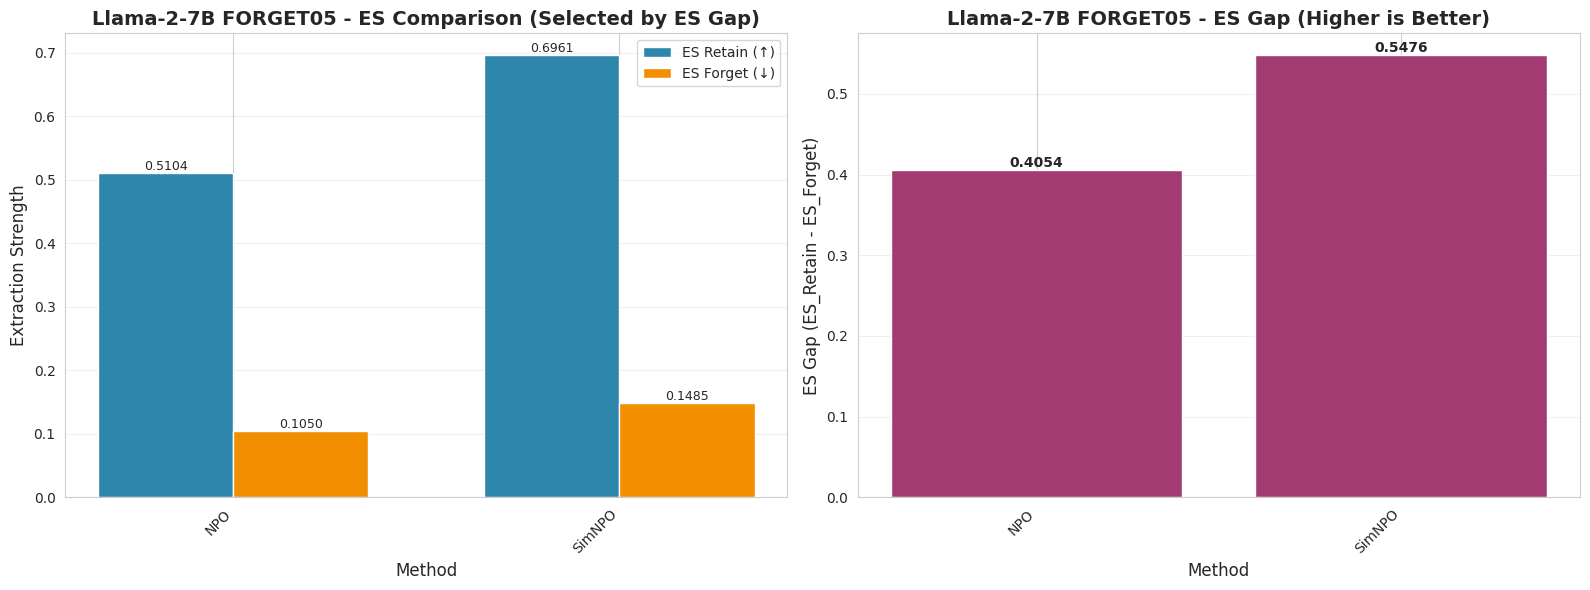


Llama-2-7B - BEST CONFIGURATIONS BY ES GAP - FORGET05
method  beta  gamma   es_gap  extraction_strength_retain  extraction_strength  model_utility  forget_quality  composite_score
   NPO   0.2    0.2 0.405375                    0.510355             0.104980       0.581974        0.000967         0.723441
SimNPO   2.0    0.2 0.547625                    0.696092             0.148467       0.610552        0.000002         0.761100


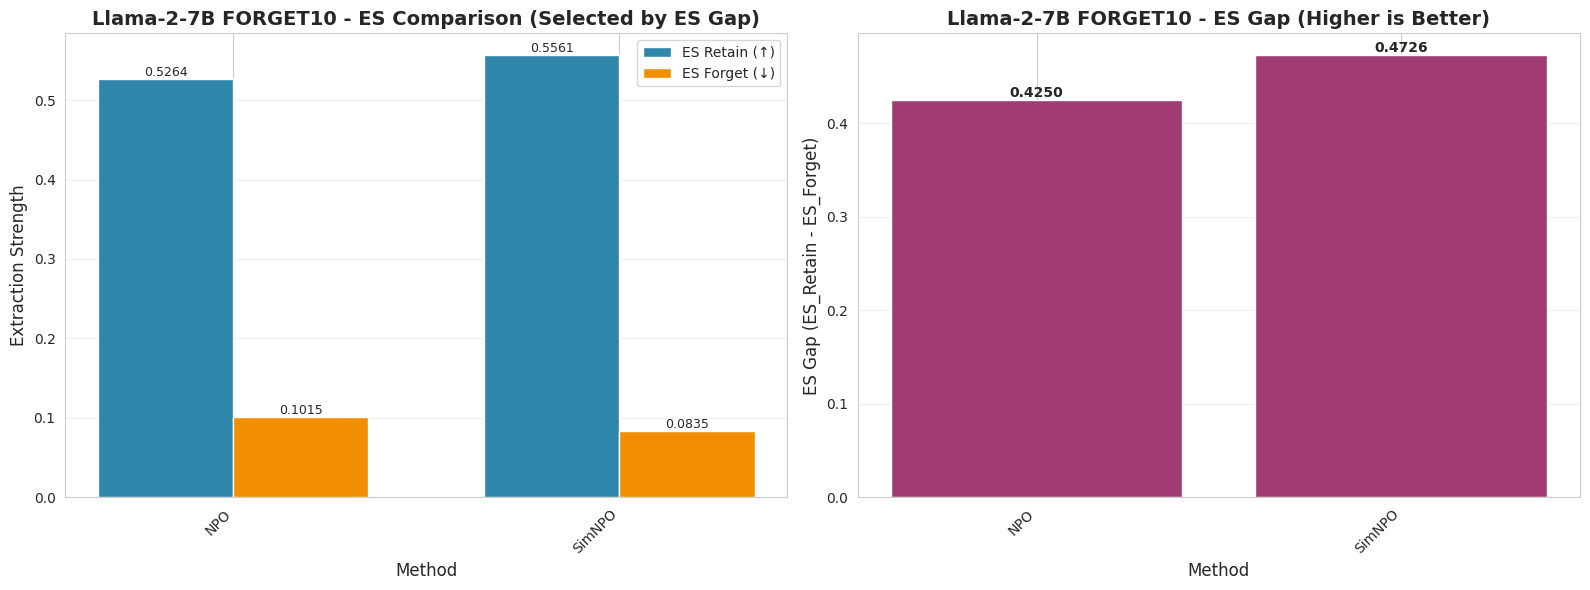


Llama-2-7B - BEST CONFIGURATIONS BY ES GAP - FORGET10
method  beta  gamma   es_gap  extraction_strength_retain  extraction_strength  model_utility  forget_quality  composite_score
   NPO   0.2    0.2 0.424970                    0.526443             0.101473       0.592781    9.988666e-07         0.674965
SimNPO   2.0    0.2 0.472606                    0.556138             0.083533       0.613737    6.923242e-05         0.867737

Analysis based on ES Gap complete!


In [16]:
# Calculate ES gap (ES_Retain - ES_Forget) for each configuration
df['es_gap'] = df['extraction_strength_retain'] - df['extraction_strength']

for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    print(f"\n{'='*100}")
    print(f"{model_name} - BEST HYPERPARAMETERS BY ES GAP (ES_Retain - ES_Forget) - {forget_set.upper()}")
    print('='*100)
    print("Selection Criteria: Maximize (ES_Retain - ES_Forget)")
    print("  - ES_Retain: Extraction strength on retain data (higher is better)")
    print("  - ES_Forget: Extraction strength on forget data (lower is better)")
    print("  - Larger gap indicates better unlearning with good retain performance")
    
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        
        if len(method_df) == 0:
            continue
        
        # Find the best configuration based on ES gap
        best_config = method_df.nlargest(1, 'es_gap').iloc[0]
        
        print(f"\n{method} Method - Best Configuration:")
        print("-" * 80)
        
        # Display hyperparameters
        if pd.notna(best_config.get('beta')):
            print(f"  Beta (β): {best_config['beta']:.3f}")
        if pd.notna(best_config.get('gamma')):
            print(f"  Gamma (γ): {best_config['gamma']:.3f}")
        if pd.notna(best_config.get('alpha')):
            print(f"  Alpha (α): {best_config['alpha']:.3f}")
        if pd.notna(best_config.get('epoch')):
            print(f"  Epochs: {best_config['epoch']}")
        
        print(f"\n  ES Gap Analysis:")
        print(f"    ES Gap (ES_Retain - ES_Forget):  {best_config['es_gap']:.4f}  *** TARGET METRIC ***")
        print(f"    └─ ES Retain:                     {best_config['extraction_strength_retain']:.4f}  ↑")
        print(f"    └─ ES Forget:                     {best_config['extraction_strength']:.4f}  ↓")
        
        print(f"\n  Other Performance Metrics:")
        print(f"    Model Utility (MU):               {best_config['model_utility']:.4f}  ↑")
        print(f"    Forget Quality (FQ):              {best_config['forget_quality']:.6f}  ↑")
        print(f"    Retain ROUGE:                     {best_config['retain_Q_A_ROUGE']:.4f}  ↑")
        print(f"    Forget ROUGE:                     {best_config['forget_Q_A_ROUGE']:.4f}  ↓")
        print(f"    Exact Memorization (EM):          {best_config['exact_memorization']:.4f}  ↓")
        print(f"    Composite Score (ES+MU):          {best_config['composite_score']:.4f}")
        
        print(f"\n  Model Directory: {best_config['dir_name']}")
        
        # Show comparison with method average
        method_avg_gap = method_df['es_gap'].mean()
        improvement = ((best_config['es_gap'] - method_avg_gap) / abs(method_avg_gap) * 100) if method_avg_gap != 0 else 0
        print(f"\n  ES Gap Improvement vs Method Average:")
        print(f"    Method Average ES Gap:  {method_avg_gap:.4f}")
        print(f"    Best Config ES Gap:     {best_config['es_gap']:.4f}")
        print(f"    Improvement:            {improvement:+6.2f}%")

# Visualize ES gap for best configurations
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    # Get best config for each method based on ES gap
    best_configs_gap = []
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        if len(method_df) > 0:
            best = method_df.nlargest(1, 'es_gap').iloc[0]
            best_configs_gap.append(best)
    
    if len(best_configs_gap) == 0:
        continue
    
    best_gap_df = pd.DataFrame(best_configs_gap)
    
    # Create comparison visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: ES Retain vs ES Forget comparison
    x_pos = np.arange(len(best_gap_df))
    width = 0.35
    
    ax1 = axes[0]
    bars1 = ax1.bar(x_pos - width/2, best_gap_df['extraction_strength_retain'], 
                    width, label='ES Retain (↑)', color='#2E86AB')
    bars2 = ax1.bar(x_pos + width/2, best_gap_df['extraction_strength'], 
                    width, label='ES Forget (↓)', color='#F18F01')
    
    ax1.set_xlabel('Method', fontsize=12)
    ax1.set_ylabel('Extraction Strength', fontsize=12)
    ax1.set_title(f'{model_name} {forget_set.upper()} - ES Comparison (Selected by ES Gap)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(best_gap_df['method'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: ES Gap bar chart
    ax2 = axes[1]
    bars_gap = ax2.bar(x_pos, best_gap_df['es_gap'], color='#A23B72')
    
    ax2.set_xlabel('Method', fontsize=12)
    ax2.set_ylabel('ES Gap (ES_Retain - ES_Forget)', fontsize=12)
    ax2.set_title(f'{model_name} {forget_set.upper()} - ES Gap (Higher is Better)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(best_gap_df['method'], rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars_gap:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print(f"\n{'='*100}")
    print(f"{model_name} - BEST CONFIGURATIONS BY ES GAP - {forget_set.upper()}")
    print('='*100)
    
    summary_cols = ['method', 'beta', 'gamma', 'es_gap',
                   'extraction_strength_retain', 'extraction_strength',
                   'model_utility', 'forget_quality', 'composite_score']
    print(best_gap_df[summary_cols].to_string(index=False))

print("\n" + "="*100)
print("Analysis based on ES Gap complete!")
print("="*100)

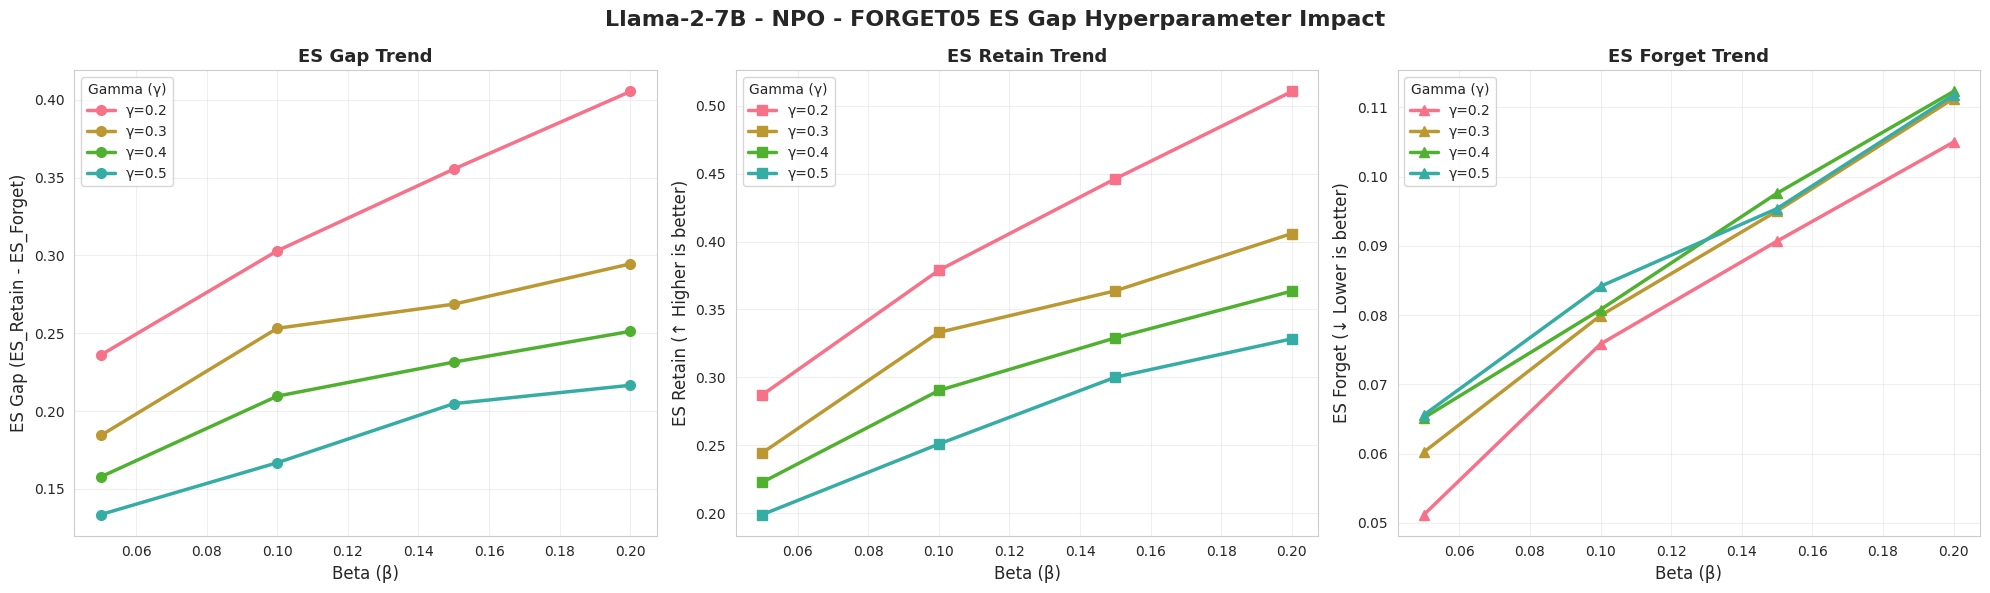

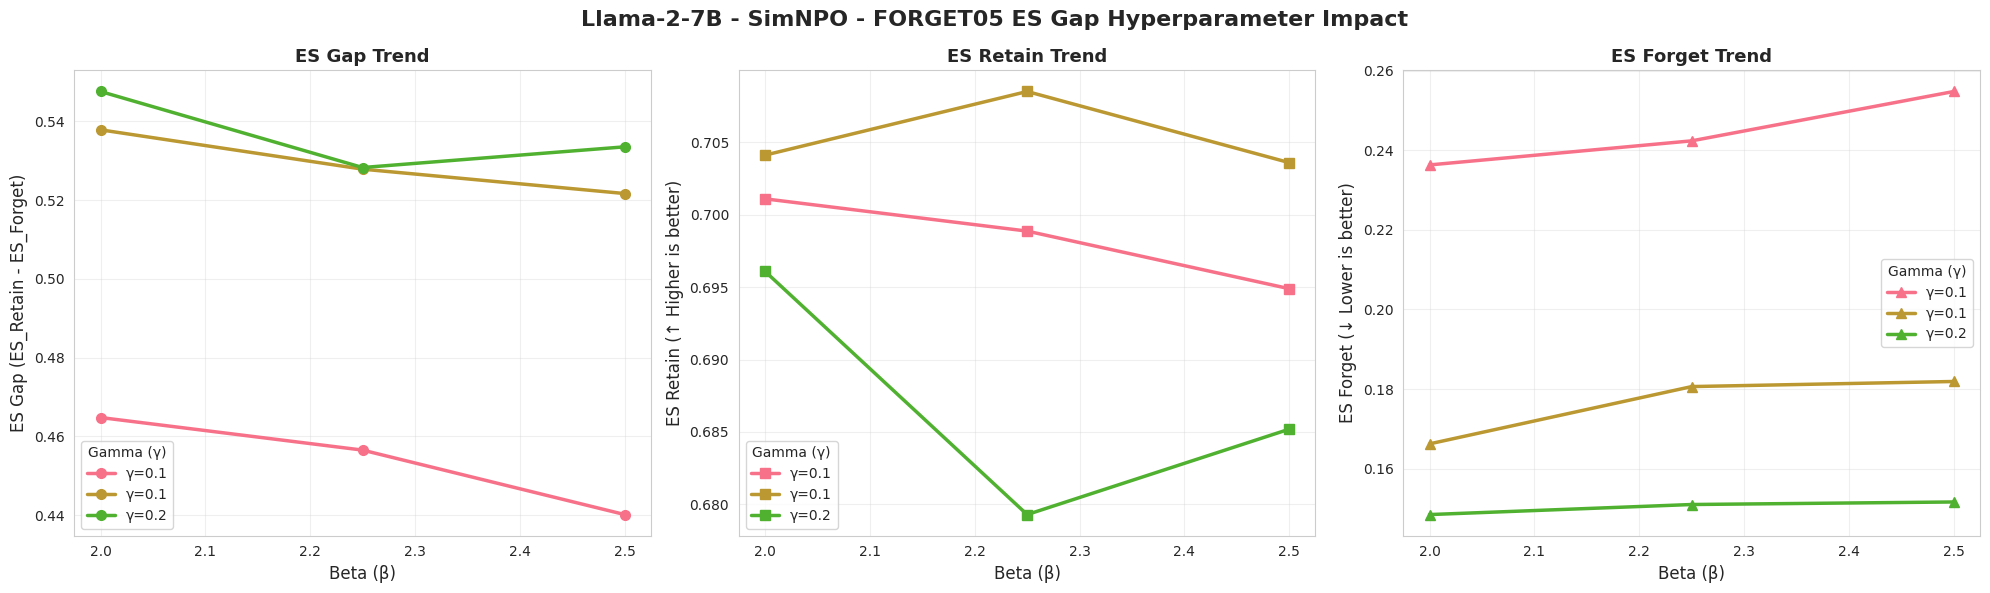

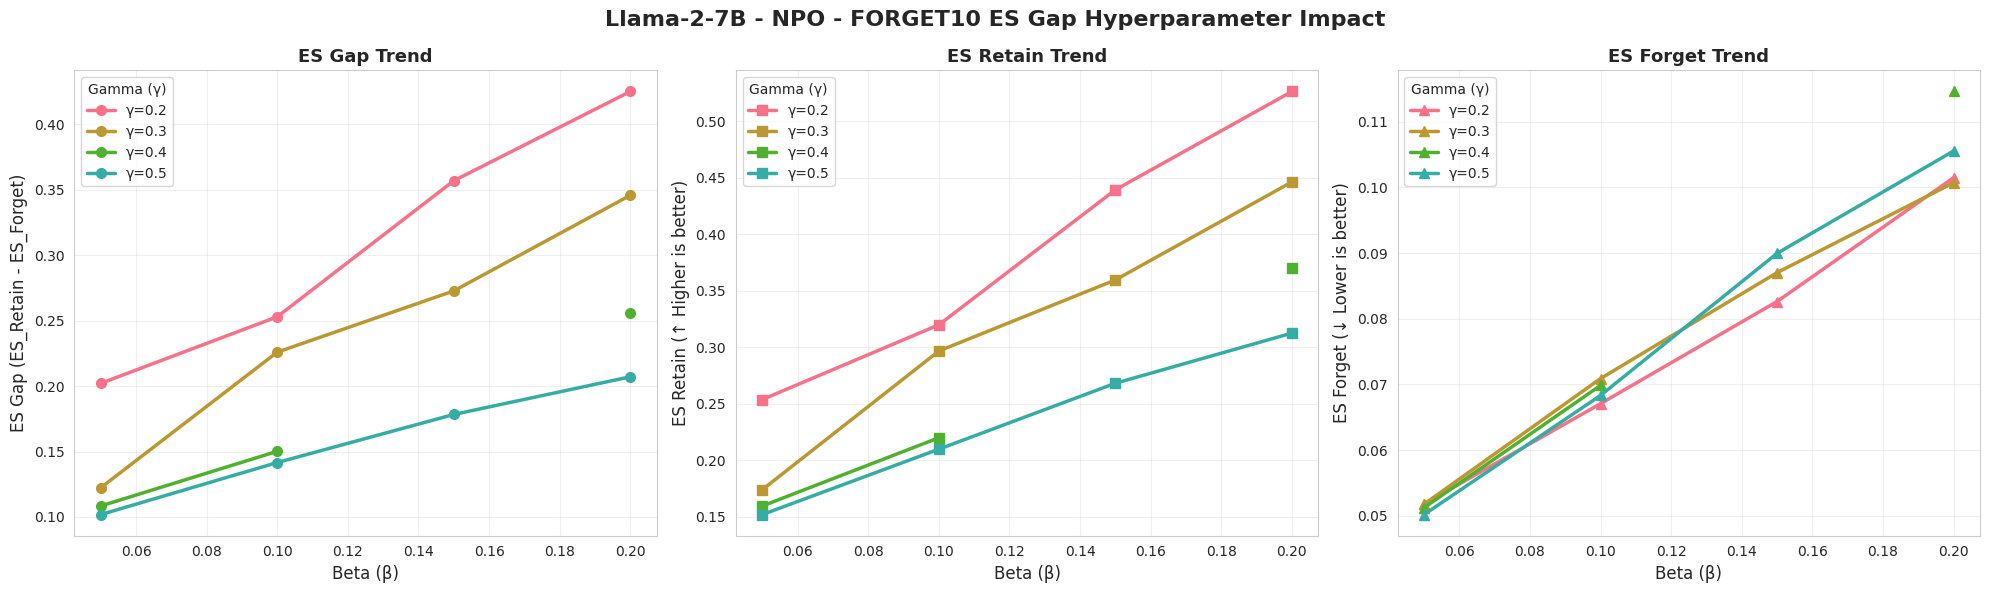

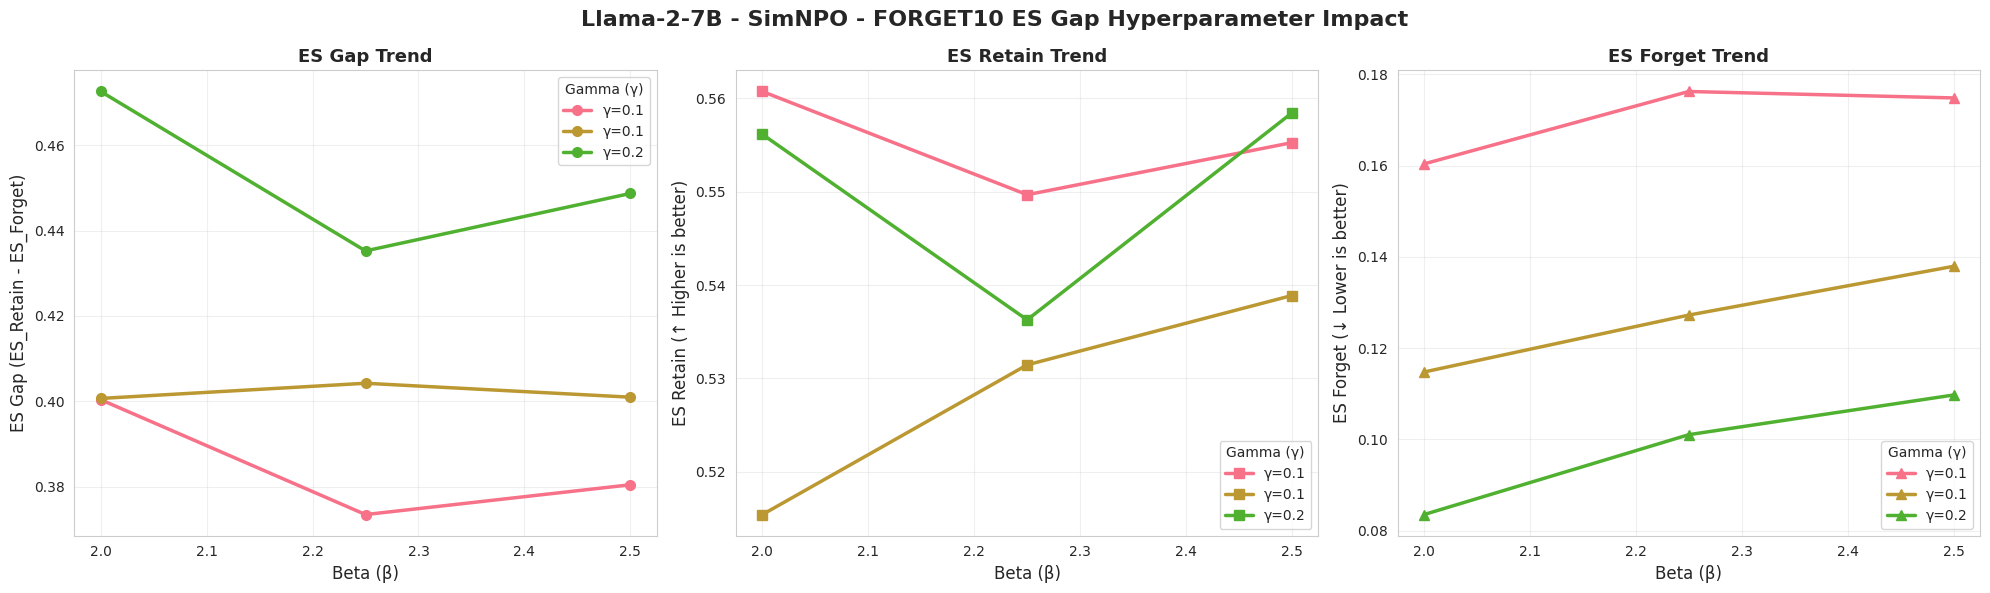

In [17]:
# Analyze ES Gap hyperparameter impact for each method and forget set
for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        if len(method_df) < 2:
            continue
        
        # Check if beta and gamma exist
        has_beta = 'beta' in method_df.columns and method_df['beta'].notna().any()
        has_gamma = 'gamma' in method_df.columns and method_df['gamma'].notna().any()
        
        if not (has_beta or has_gamma):
            continue
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f'{model_name} - {method} - {forget_set.upper()} ES Gap Hyperparameter Impact', 
                     fontsize=16, fontweight='bold')
        
        # Plot 1: ES Gap vs hyperparameter
        ax1 = axes[0]
        if has_beta and has_gamma:
            # Group by gamma and plot lines for different gamma values
            for gamma_val in sorted(method_df['gamma'].unique()):
                gamma_df = method_df[method_df['gamma'] == gamma_val].sort_values('beta')
                if len(gamma_df) > 0:
                    ax1.plot(gamma_df['beta'], gamma_df['es_gap'], 
                           marker='o', label=f'γ={gamma_val:.1f}', linewidth=2.5, markersize=7)
            ax1.set_xlabel('Beta (β)', fontsize=12)
            ax1.legend(loc='best', fontsize=10, title='Gamma (γ)')
        elif has_beta:
            method_df_sorted = method_df.sort_values('beta')
            ax1.plot(method_df_sorted['beta'], method_df_sorted['es_gap'], 
                   marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
            ax1.set_xlabel('Beta (β)', fontsize=12)
        elif has_gamma:
            method_df_sorted = method_df.sort_values('gamma')
            ax1.plot(method_df_sorted['gamma'], method_df_sorted['es_gap'], 
                   marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
            ax1.set_xlabel('Gamma (γ)', fontsize=12)
        
        ax1.set_ylabel('ES Gap (ES_Retain - ES_Forget)', fontsize=12)
        ax1.set_title('ES Gap Trend', fontsize=13, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: ES Retain vs hyperparameter
        ax2 = axes[1]
        if has_beta and has_gamma:
            for gamma_val in sorted(method_df['gamma'].unique()):
                gamma_df = method_df[method_df['gamma'] == gamma_val].sort_values('beta')
                if len(gamma_df) > 0:
                    ax2.plot(gamma_df['beta'], gamma_df['extraction_strength_retain'], 
                           marker='s', label=f'γ={gamma_val:.1f}', linewidth=2.5, markersize=7)
            ax2.set_xlabel('Beta (β)', fontsize=12)
            ax2.legend(loc='best', fontsize=10, title='Gamma (γ)')
        elif has_beta:
            method_df_sorted = method_df.sort_values('beta')
            ax2.plot(method_df_sorted['beta'], method_df_sorted['extraction_strength_retain'], 
                   marker='s', linewidth=2.5, markersize=8, color='#A23B72')
            ax2.set_xlabel('Beta (β)', fontsize=12)
        elif has_gamma:
            method_df_sorted = method_df.sort_values('gamma')
            ax2.plot(method_df_sorted['gamma'], method_df_sorted['extraction_strength_retain'], 
                   marker='s', linewidth=2.5, markersize=8, color='#A23B72')
            ax2.set_xlabel('Gamma (γ)', fontsize=12)
        
        ax2.set_ylabel('ES Retain (↑ Higher is better)', fontsize=12)
        ax2.set_title('ES Retain Trend', fontsize=13, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: ES Forget vs hyperparameter
        ax3 = axes[2]
        if has_beta and has_gamma:
            for gamma_val in sorted(method_df['gamma'].unique()):
                gamma_df = method_df[method_df['gamma'] == gamma_val].sort_values('beta')
                if len(gamma_df) > 0:
                    ax3.plot(gamma_df['beta'], gamma_df['extraction_strength'], 
                           marker='^', label=f'γ={gamma_val:.1f}', linewidth=2.5, markersize=7)
            ax3.set_xlabel('Beta (β)', fontsize=12)
            ax3.legend(loc='best', fontsize=10, title='Gamma (γ)')
        elif has_beta:
            method_df_sorted = method_df.sort_values('beta')
            ax3.plot(method_df_sorted['beta'], method_df_sorted['extraction_strength'], 
                   marker='^', linewidth=2.5, markersize=8, color='#F18F01')
            ax3.set_xlabel('Beta (β)', fontsize=12)
        elif has_gamma:
            method_df_sorted = method_df.sort_values('gamma')
            ax3.plot(method_df_sorted['gamma'], method_df_sorted['extraction_strength'], 
                   marker='^', linewidth=2.5, markersize=8, color='#F18F01')
            ax3.set_xlabel('Gamma (γ)', fontsize=12)
        
        ax3.set_ylabel('ES Forget (↓ Lower is better)', fontsize=12)
        ax3.set_title('ES Forget Trend', fontsize=13, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


## 10. Best Hyperparameters Based on ES Gap (ES_Retain - ES_Forget)

Select best configuration for each method by maximizing the gap between:
- **ES Retain (higher is better)** - extraction strength on retain data
- **ES Forget (lower is better)** - extraction strength on forget data

The larger the gap (ES_Retain - ES_Forget), the better the unlearning effect.

## 11. Hyperparameter Stability Analysis for Key Metrics

Analyze the stability (consistency) of three critical metrics across different hyperparameter configurations:
- **Extraction Strength (ES)** - Lower is better
- **ES Retain** - Higher is better  
- **Model Utility (MU)** - Higher is better

This section provides publication-quality visualizations showing:
1. Mean performance vs stability (coefficient of variation)
2. Heatmaps of metric variability across hyperparameter grids
3. Multi-dimensional stability profiles

In [18]:
# Calculate stability metrics for key indicators
# Coefficient of Variation (CV) = std / mean, lower CV indicates higher stability

def calculate_stability_metrics(method_df, metrics_to_analyze):
    """Calculate mean and CV for specified metrics"""
    stability_data = {}
    
    for metric in metrics_to_analyze:
        if metric in method_df.columns:
            values = method_df[metric].dropna()
            if len(values) > 1:
                mean_val = values.mean()
                std_val = values.std()
                cv = (std_val / abs(mean_val)) if mean_val != 0 else np.inf
                
                stability_data[metric] = {
                    'mean': mean_val,
                    'std': std_val,
                    'cv': cv,
                    'min': values.min(),
                    'max': values.max(),
                    'range': values.max() - values.min()
                }
    
    return stability_data

# Key metrics for stability analysis
key_metrics = ['extraction_strength', 'extraction_strength_retain', 'model_utility']
key_metric_labels = {
    'extraction_strength': 'ES (Forget)',
    'extraction_strength_retain': 'ES (Retain)',
    'model_utility': 'Model Utility'
}

print("Stability Analysis for Key Metrics")
print("="*100)
print("\nCoefficient of Variation (CV) = std / mean")
print("  - Lower CV indicates more stable (consistent) performance")
print("  - Higher CV indicates more variable performance across configurations")
print("="*100)

Stability Analysis for Key Metrics

Coefficient of Variation (CV) = std / mean
  - Lower CV indicates more stable (consistent) performance
  - Higher CV indicates more variable performance across configurations


/tmp/ipykernel_2527/930989775.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


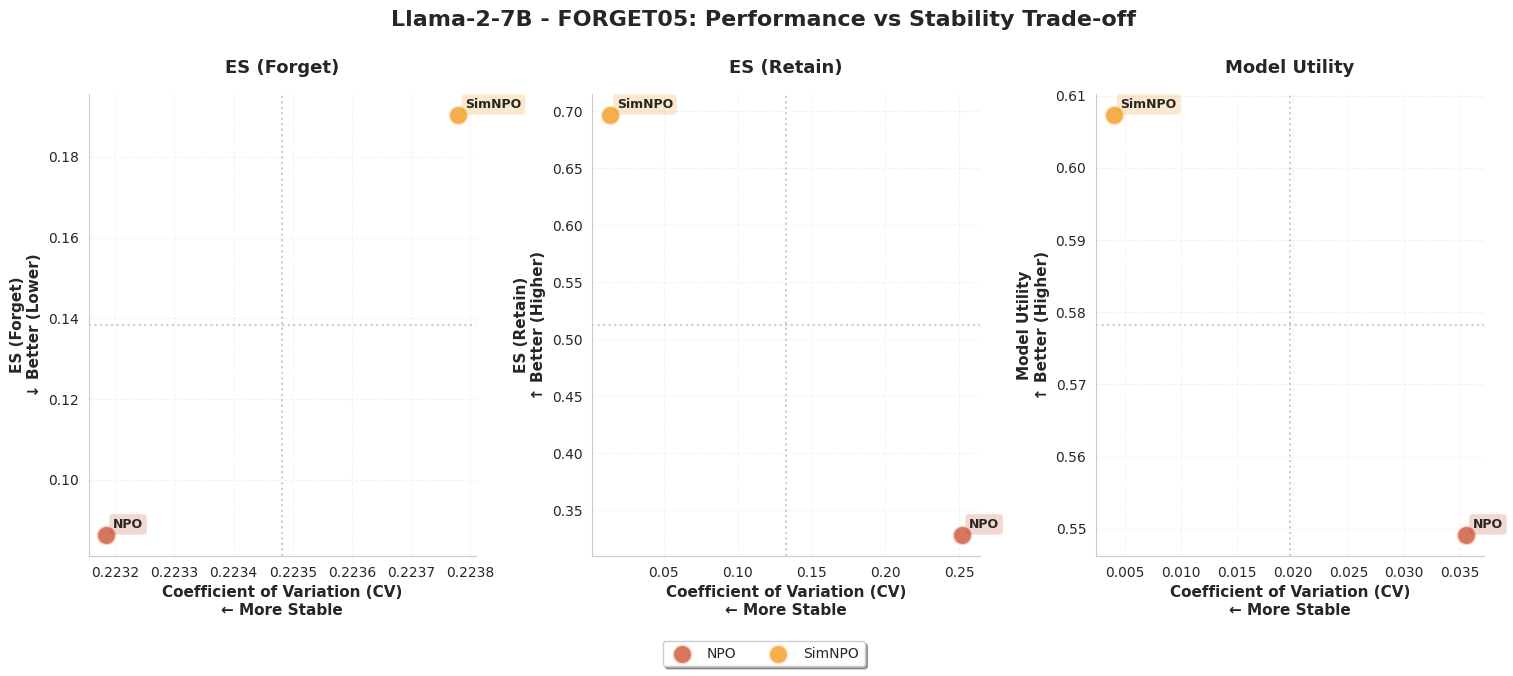


Interpretation Guide - FORGET05:
• Top-left quadrant: HIGH performance + LOW variability (IDEAL)
• Top-right quadrant: HIGH performance + HIGH variability (unstable)
• Bottom-left quadrant: LOW performance + LOW variability (consistently poor)
• Bottom-right quadrant: LOW performance + HIGH variability (worst)


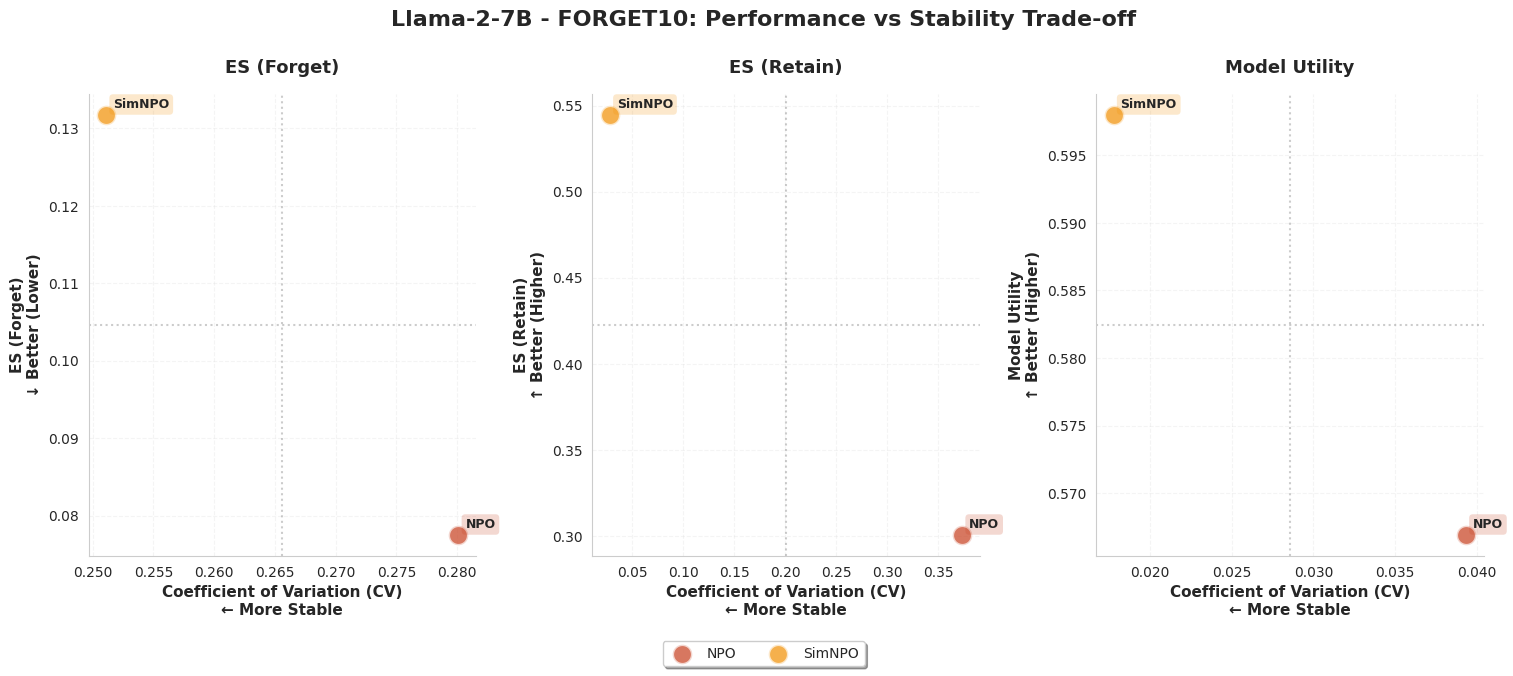


Interpretation Guide - FORGET10:
• Top-left quadrant: HIGH performance + LOW variability (IDEAL)
• Top-right quadrant: HIGH performance + HIGH variability (unstable)
• Bottom-left quadrant: LOW performance + LOW variability (consistently poor)
• Bottom-right quadrant: LOW performance + HIGH variability (worst)


In [19]:
# Visualization 1: Mean-Stability Trade-off Scatter Plot (Publication Style)
# Shows the relationship between performance and consistency

for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    # Create figure with modern styling
    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)
    
    colors_method = {'GradAscent': '#2E86AB', 'GradDiff': '#A23B72', 
                     'SimNPO': '#F18F01', 'NPO': '#C73E1D'}
    
    for idx, metric in enumerate(key_metrics):
        ax = fig.add_subplot(gs[0, idx])
        
        # Calculate stats for each method
        for method in methods:
            method_df = forget_df[forget_df['method'] == method]
            
            if len(method_df) < 2 or metric not in method_df.columns:
                continue
            
            values = method_df[metric].dropna()
            if len(values) > 1:
                mean_val = values.mean()
                cv_val = values.std() / abs(mean_val) if mean_val != 0 else 0
                
                # Plot scatter point
                ax.scatter(cv_val, mean_val, s=200, alpha=0.7,
                          color=colors_method.get(method, '#808080'),
                          edgecolors='white', linewidth=2, 
                          label=method, zorder=3)
                
                # Add method label near point
                ax.annotate(method, (cv_val, mean_val), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=9, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3', 
                                   facecolor=colors_method.get(method, '#808080'),
                                   alpha=0.2, edgecolor='none'))
        
        # Styling
        ax.set_xlabel('Coefficient of Variation (CV)\n← More Stable', 
                     fontsize=11, fontweight='bold')
        
        # Set y-axis label based on metric optimization direction
        if metric == 'extraction_strength':
            y_label = f'{key_metric_labels[metric]}\n↓ Better (Lower)'
        else:
            y_label = f'{key_metric_labels[metric]}\n↑ Better (Higher)'
        ax.set_ylabel(y_label, fontsize=11, fontweight='bold')
        
        ax.set_title(key_metric_labels[metric], 
                    fontsize=13, fontweight='bold', pad=15)
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add quadrant reference lines (median values)
        if len(ax.collections) > 0:
            cv_vals = [c.get_offsets()[0][0] for c in ax.collections if len(c.get_offsets()) > 0]
            mean_vals = [c.get_offsets()[0][1] for c in ax.collections if len(c.get_offsets()) > 0]
            if cv_vals and mean_vals:
                cv_median = np.median(cv_vals)
                mean_median = np.median(mean_vals)
                ax.axvline(cv_median, color='gray', linestyle=':', alpha=0.4, linewidth=1.5)
                ax.axhline(mean_median, color='gray', linestyle=':', alpha=0.4, linewidth=1.5)
    
    # Add overall title
    fig.suptitle(f'{model_name} - {forget_set.upper()}: Performance vs Stability Trade-off',
                fontsize=16, fontweight='bold', y=1.02)
    
    # Add legend (only once)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', 
                  bbox_to_anchor=(0.5, -0.02), ncol=len(methods),
                  frameon=True, fancybox=True, shadow=True, fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*100}")
    print(f"Interpretation Guide - {forget_set.upper()}:")
    print('='*100)
    print("• Top-left quadrant: HIGH performance + LOW variability (IDEAL)")
    print("• Top-right quadrant: HIGH performance + HIGH variability (unstable)")
    print("• Bottom-left quadrant: LOW performance + LOW variability (consistently poor)")
    print("• Bottom-right quadrant: LOW performance + HIGH variability (worst)")
    print("="*100)

ValueError: zero-size array to reduction operation fmin which has no identity

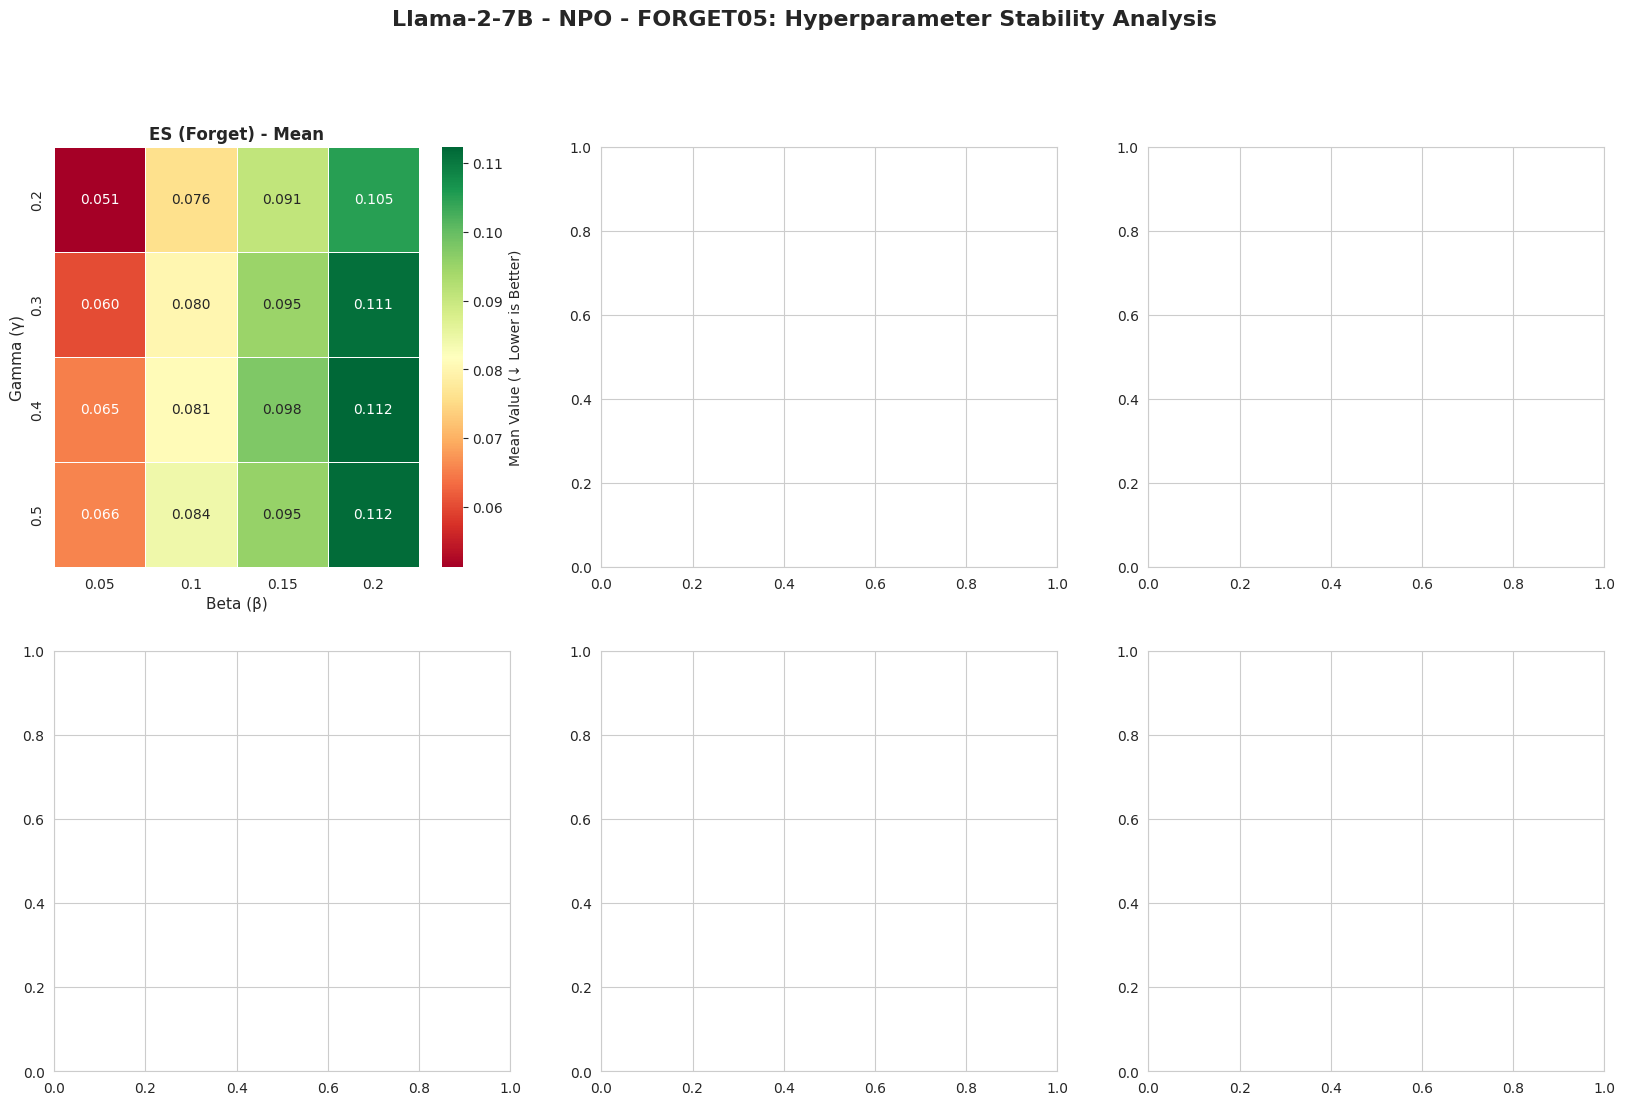

In [20]:
# Visualization 2: Hyperparameter Stability Heatmaps (Beta-Gamma Grid)
# Shows how metric stability varies across hyperparameter space

for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        # Check for beta-gamma grid
        if 'beta' not in method_df.columns or 'gamma' not in method_df.columns:
            continue
        
        grid_df = method_df[method_df['beta'].notna() & method_df['gamma'].notna()]
        
        if len(grid_df) < 4:
            continue
        
        # Create figure
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f'{model_name} - {method} - {forget_set.upper()}: Hyperparameter Stability Analysis',
                    fontsize=16, fontweight='bold', y=0.995)
        
        for idx, metric in enumerate(key_metrics):
            # Row 1: Mean value heatmap
            ax_mean = axes[0, idx]
            pivot_mean = grid_df.pivot_table(
                values=metric, index='gamma', columns='beta', aggfunc='mean'
            )
            
            # Choose colormap based on optimization direction
            if metric == 'extraction_strength':
                cmap_mean = 'RdYlGn'  # Red=high/bad, Green=low/good
                cbar_label = 'Mean Value (↓ Lower is Better)'
            else:
                cmap_mean = 'RdYlGn_r'  # Green=high/good, Red=low/bad
                cbar_label = 'Mean Value (↑ Higher is Better)'
            
            sns.heatmap(pivot_mean, annot=True, fmt='.3f', cmap=cmap_mean,
                       ax=ax_mean, cbar_kws={'label': cbar_label},
                       linewidths=0.5, linecolor='white')
            ax_mean.set_title(f'{key_metric_labels[metric]} - Mean', 
                            fontsize=12, fontweight='bold')
            ax_mean.set_xlabel('Beta (β)', fontsize=11)
            ax_mean.set_ylabel('Gamma (γ)', fontsize=11)
            
            # Row 2: Standard deviation heatmap
            ax_std = axes[1, idx]
            pivot_std = grid_df.pivot_table(
                values=metric, index='gamma', columns='beta', aggfunc='std'
            )
            
            # For stability, lower std is better (use reversed green scale)
            sns.heatmap(pivot_std, annot=True, fmt='.4f', cmap='YlOrRd',
                       ax=ax_std, cbar_kws={'label': 'Std Dev (↓ Lower = More Stable)'},
                       linewidths=0.5, linecolor='white')
            ax_std.set_title(f'{key_metric_labels[metric]} - Stability (Std Dev)', 
                           fontsize=12, fontweight='bold')
            ax_std.set_xlabel('Beta (β)', fontsize=11)
            ax_std.set_ylabel('Gamma (γ)', fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n{method} - {forget_set.upper()}: Stability Summary")
        print("-" * 80)
        for metric in key_metrics:
            values = grid_df[metric].dropna()
            if len(values) > 1:
                print(f"  {key_metric_labels[metric]:20s}: "
                      f"mean={values.mean():.4f}, std={values.std():.4f}, "
                      f"CV={values.std()/abs(values.mean()):.4f}")
        print()

/tmp/ipykernel_2590/2167701554.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


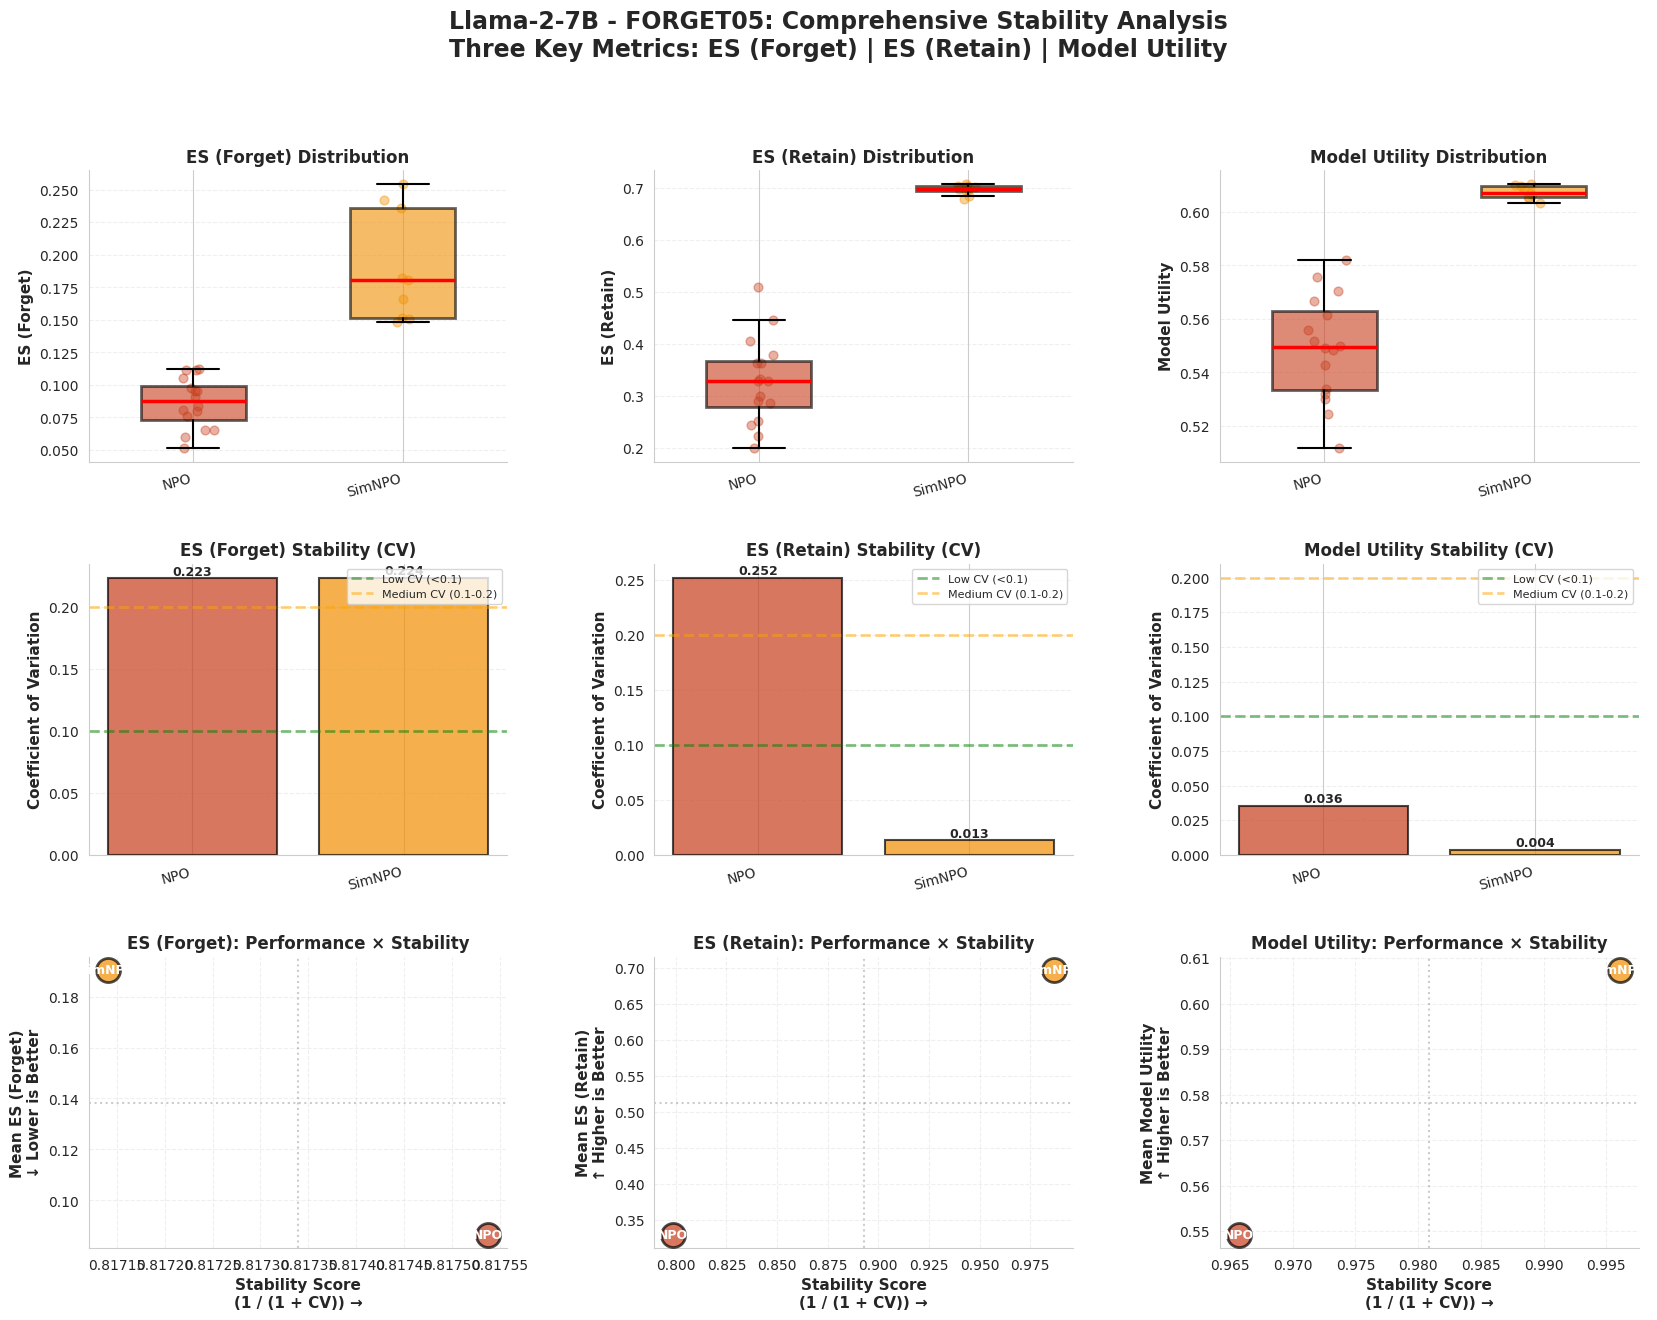


Comprehensive Stability Analysis Summary - FORGET05
Visualization Guide:
  • Row 1: Distribution of metric values across configurations (box plots)
  • Row 2: Coefficient of variation - lower values indicate more stable performance
  • Row 3: Performance vs Stability trade-off - ideal methods are top-right


/tmp/ipykernel_2590/2167701554.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


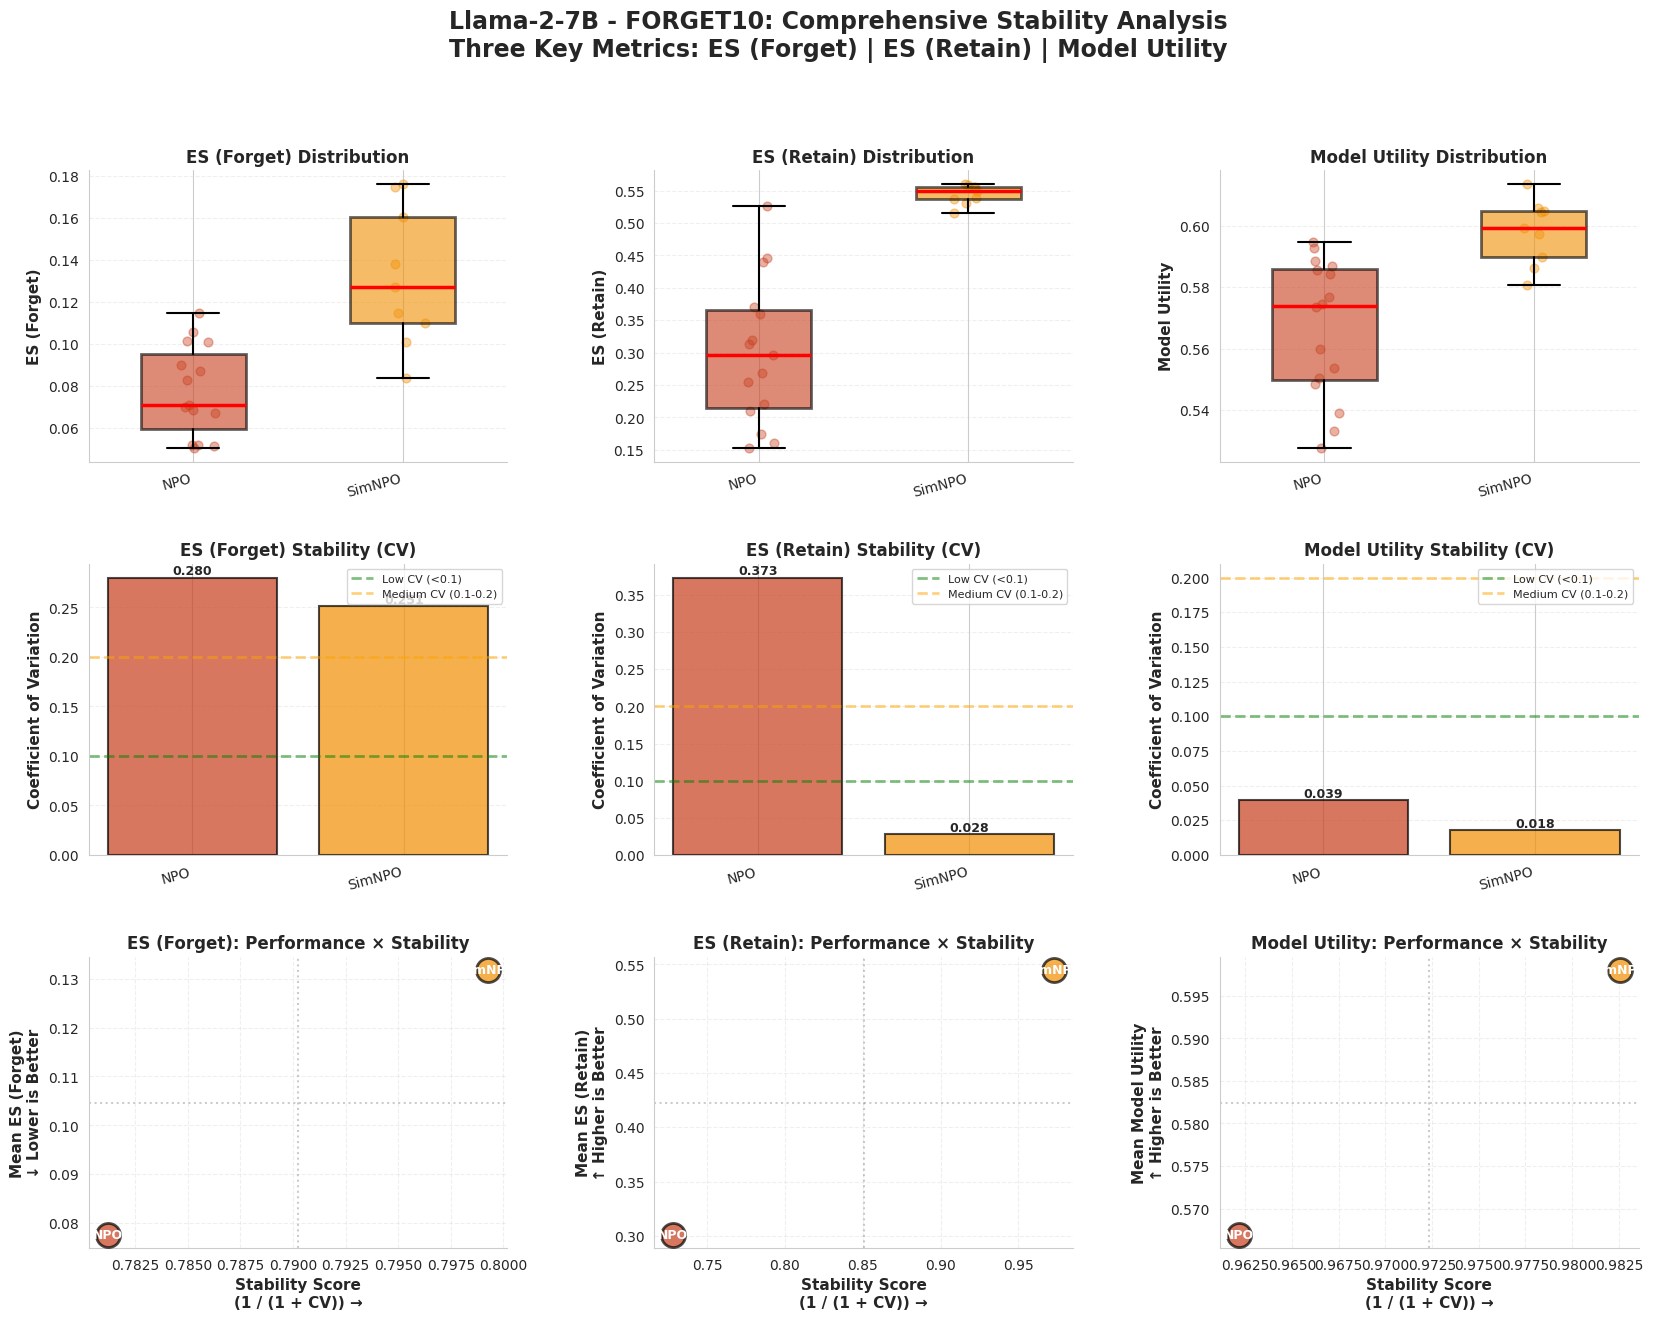


Comprehensive Stability Analysis Summary - FORGET10
Visualization Guide:
  • Row 1: Distribution of metric values across configurations (box plots)
  • Row 2: Coefficient of variation - lower values indicate more stable performance
  • Row 3: Performance vs Stability trade-off - ideal methods are top-right


In [ ]:
# Visualization 3: Integrated Stability Profile (Publication-Ready Multi-Panel)
# Combines performance, stability, and sensitivity in a single comprehensive view

for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    # Create comprehensive figure with multiple subplots
    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)
    
    colors_method = {'GradAscent': '#2E86AB', 'GradDiff': '#A23B72', 
                     'SimNPO': '#F18F01', 'NPO': '#C73E1D'}
    
    # ===== Row 1: Performance Range (Box plots with individual points) =====
    for idx, metric in enumerate(key_metrics):
        ax = fig.add_subplot(gs[0, idx])
        
        data_for_box = []
        positions = []
        method_labels = []
        
        for i, method in enumerate(methods):
            method_data = forget_df[forget_df['method'] == method][metric].dropna()
            if len(method_data) > 0:
                data_for_box.append(method_data)
                positions.append(i)
                method_labels.append(method)
                
                # Add jittered scatter points
                jitter = np.random.normal(0, 0.04, size=len(method_data))
                ax.scatter(np.ones(len(method_data)) * i + jitter, method_data,
                          alpha=0.4, s=40, color=colors_method.get(method, '#808080'),
                          zorder=1)
        
        # Create box plot
        bp = ax.boxplot(data_for_box, positions=positions, widths=0.5,
                       patch_artist=True, showfliers=False,
                       boxprops=dict(linewidth=2, edgecolor='black'),
                       whiskerprops=dict(linewidth=1.5),
                       capprops=dict(linewidth=1.5),
                       medianprops=dict(linewidth=2.5, color='red'))
        
        # Color boxes
        for patch, method in zip(bp['boxes'], method_labels):
            patch.set_facecolor(colors_method.get(method, '#808080'))
            patch.set_alpha(0.6)
        
        ax.set_xticks(positions)
        ax.set_xticklabels(method_labels, rotation=15, ha='right')
        ax.set_ylabel(key_metric_labels[metric], fontsize=11, fontweight='bold')
        ax.set_title(f'{key_metric_labels[metric]} Distribution', 
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # ===== Row 2: Coefficient of Variation Comparison =====
    cv_data = {metric: {method: [] for method in methods} for metric in key_metrics}
    
    for method in methods:
        method_df = forget_df[forget_df['method'] == method]
        for metric in key_metrics:
            values = method_df[metric].dropna()
            if len(values) > 1 and values.mean() != 0:
                cv = values.std() / abs(values.mean())
                cv_data[metric][method] = cv
            else:
                cv_data[metric][method] = 0
    
    for idx, metric in enumerate(key_metrics):
        ax = fig.add_subplot(gs[1, idx])
        
        method_list = list(cv_data[metric].keys())
        cv_values = [cv_data[metric][m] for m in method_list]
        colors = [colors_method.get(m, '#808080') for m in method_list]
        
        bars = ax.bar(range(len(method_list)), cv_values, color=colors, 
                     alpha=0.7, edgecolor='black', linewidth=1.5)
        
        # Add value labels on bars
        for bar, val in zip(bars, cv_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.3f}', ha='center', va='bottom', 
                   fontsize=9, fontweight='bold')
        
        ax.set_xticks(range(len(method_list)))
        ax.set_xticklabels(method_list, rotation=15, ha='right')
        ax.set_ylabel('Coefficient of Variation', fontsize=11, fontweight='bold')
        ax.set_title(f'{key_metric_labels[metric]} Stability (CV)', 
                    fontsize=12, fontweight='bold')
        ax.axhline(y=0.1, color='green', linestyle='--', alpha=0.5, linewidth=2, 
                  label='Low CV (<0.1)')
        ax.axhline(y=0.2, color='orange', linestyle='--', alpha=0.5, linewidth=2,
                  label='Medium CV (0.1-0.2)')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # ===== Row 3: Performance-Stability Radar Chart =====
    # Create a comprehensive stability score for each method
    
    for idx, metric in enumerate(key_metrics):
        ax = fig.add_subplot(gs[2, idx])
        
        method_scores = []
        for method in methods:
            method_data = forget_df[forget_df['method'] == method][metric].dropna()
            if len(method_data) > 1:
                mean_val = method_data.mean()
                std_val = method_data.std()
                cv_val = std_val / abs(mean_val) if mean_val != 0 else 0
                
                # Normalize scores (0-1 scale)
                # For stability: lower CV is better
                stability_score = 1 / (1 + cv_val) if cv_val > 0 else 1
                
                method_scores.append({
                    'method': method,
                    'mean': mean_val,
                    'stability': stability_score,
                    'cv': cv_val
                })
        
        if not method_scores:
            continue
        
        # Create scatter plot: mean vs stability
        for score_dict in method_scores:
            method = score_dict['method']
            x_val = score_dict['stability']
            y_val = score_dict['mean']
            
            ax.scatter(x_val, y_val, s=300, alpha=0.7,
                      color=colors_method.get(method, '#808080'),
                      edgecolors='black', linewidth=2, zorder=3)
            
            # Add method label
            ax.annotate(method, (x_val, y_val),
                       fontsize=9, fontweight='bold', ha='center', va='center',
                       color='white')
        
        ax.set_xlabel('Stability Score\n(1 / (1 + CV)) →', 
                     fontsize=11, fontweight='bold')
        
        if metric == 'extraction_strength':
            y_label = f'Mean {key_metric_labels[metric]}\n↓ Lower is Better'
        else:
            y_label = f'Mean {key_metric_labels[metric]}\n↑ Higher is Better'
        ax.set_ylabel(y_label, fontsize=11, fontweight='bold')
        
        ax.set_title(f'{key_metric_labels[metric]}: Performance × Stability', 
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add quadrant lines
        if len(method_scores) > 1:
            stability_median = np.median([s['stability'] for s in method_scores])
            mean_median = np.median([s['mean'] for s in method_scores])
            ax.axvline(stability_median, color='gray', linestyle=':', alpha=0.4, linewidth=1.5)
            ax.axhline(mean_median, color='gray', linestyle=':', alpha=0.4, linewidth=1.5)
    
    # Add overall title
    fig.suptitle(f'{model_name} - {forget_set.upper()}: Comprehensive Stability Analysis\n'
                f'Three Key Metrics: ES (Forget) | ES (Retain) | Model Utility',
                fontsize=17, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*100}")
    print(f"Comprehensive Stability Analysis Summary - {forget_set.upper()}")
    print('='*100)
    print("Visualization Guide:")
    print("  • Row 1: Distribution of metric values across configurations (box plots)")
    print("  • Row 2: Coefficient of variation - lower values indicate more stable performance")
    print("  • Row 3: Performance vs Stability trade-off - ideal methods are top-right")
    print("="*100)

/tmp/ipykernel_2590/3013780641.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


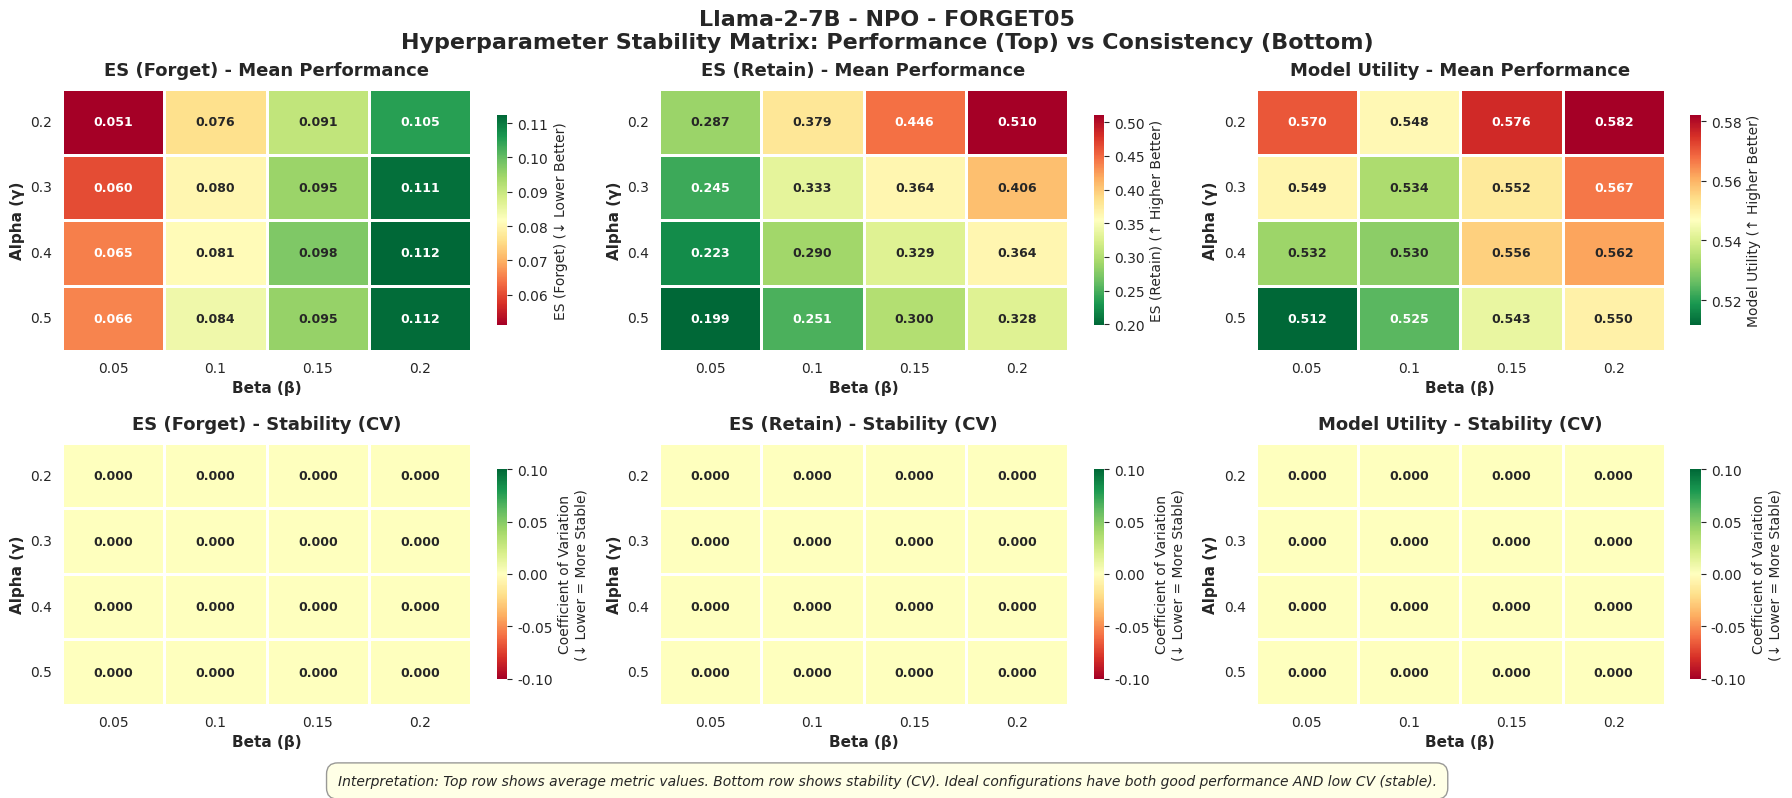


NPO - FORGET05: Hyperparameter Sensitivity Analysis

ES (Forget):
  Range: [0.0512, 0.1123]
  Mean ± Std: 0.0864 ± 0.0193
  Coefficient of Variation: 0.2232
  Stability: Unstable ★★☆☆☆

ES (Retain):
  Range: [0.1991, 0.5104]
  Mean ± Std: 0.3284 ± 0.0828
  Coefficient of Variation: 0.2521
  Stability: Unstable ★★☆☆☆

Model Utility:
  Range: [0.5116, 0.5820]
  Mean ± Std: 0.5492 ± 0.0195
  Coefficient of Variation: 0.0355
  Stability: Very Stable ★★★★★


/tmp/ipykernel_2590/3013780641.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


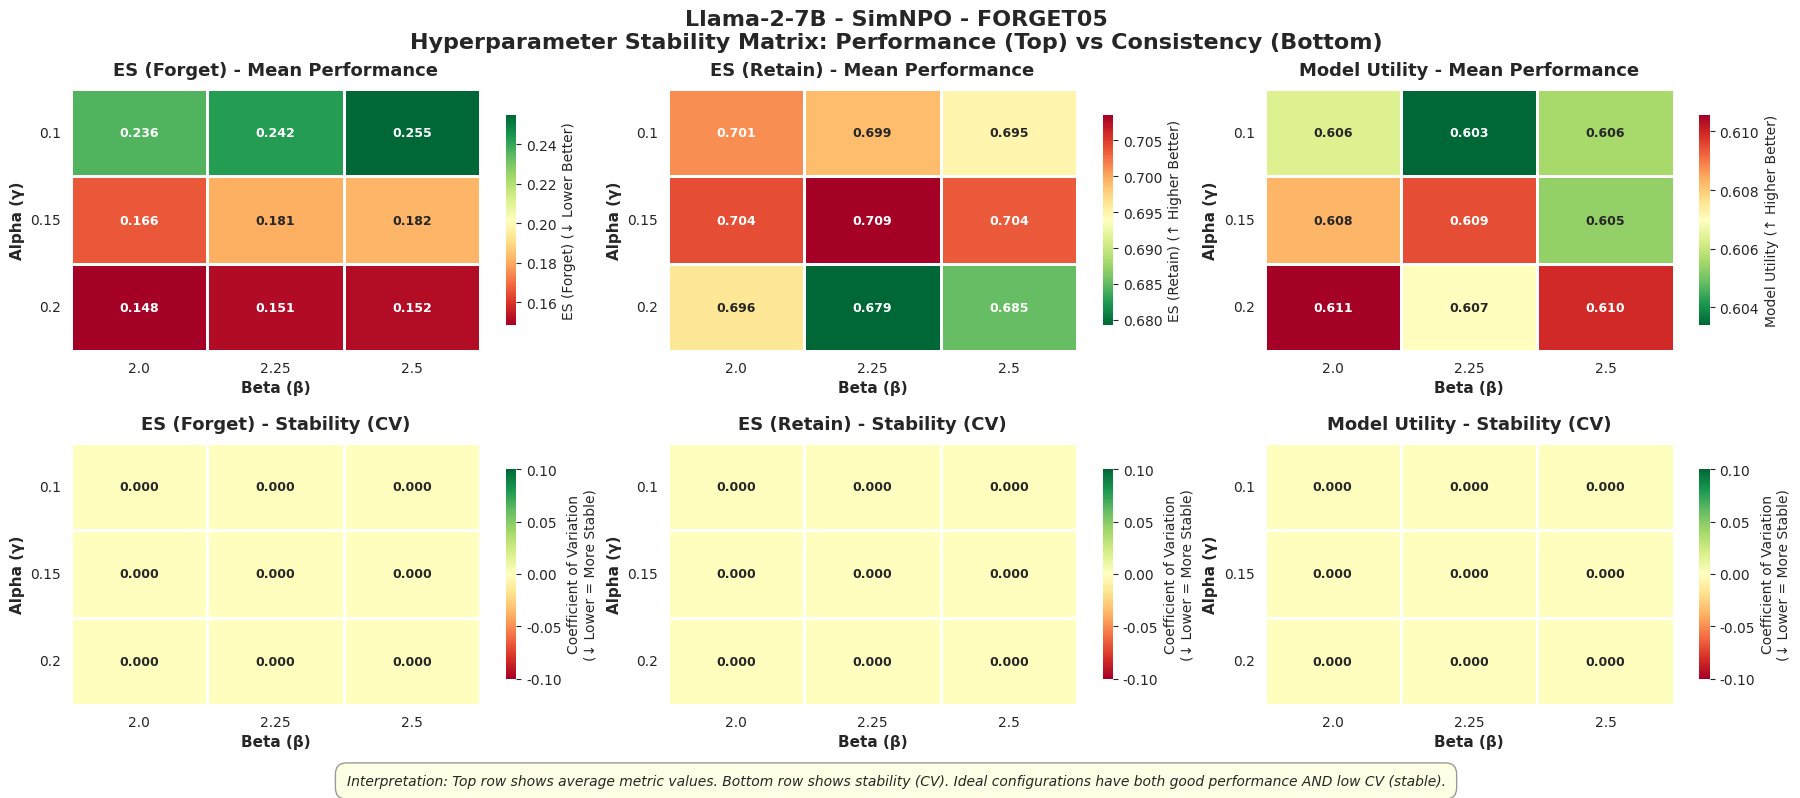


SimNPO - FORGET05: Hyperparameter Sensitivity Analysis

ES (Forget):
  Range: [0.1485, 0.2548]
  Mean ± Std: 0.1904 ± 0.0426
  Coefficient of Variation: 0.2238
  Stability: Unstable ★★☆☆☆

ES (Retain):
  Range: [0.6793, 0.7085]
  Mean ± Std: 0.6969 ± 0.0094
  Coefficient of Variation: 0.0135
  Stability: Very Stable ★★★★★

Model Utility:
  Range: [0.6034, 0.6106]
  Mean ± Std: 0.6073 ± 0.0024
  Coefficient of Variation: 0.0040
  Stability: Very Stable ★★★★★


/tmp/ipykernel_2590/3013780641.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


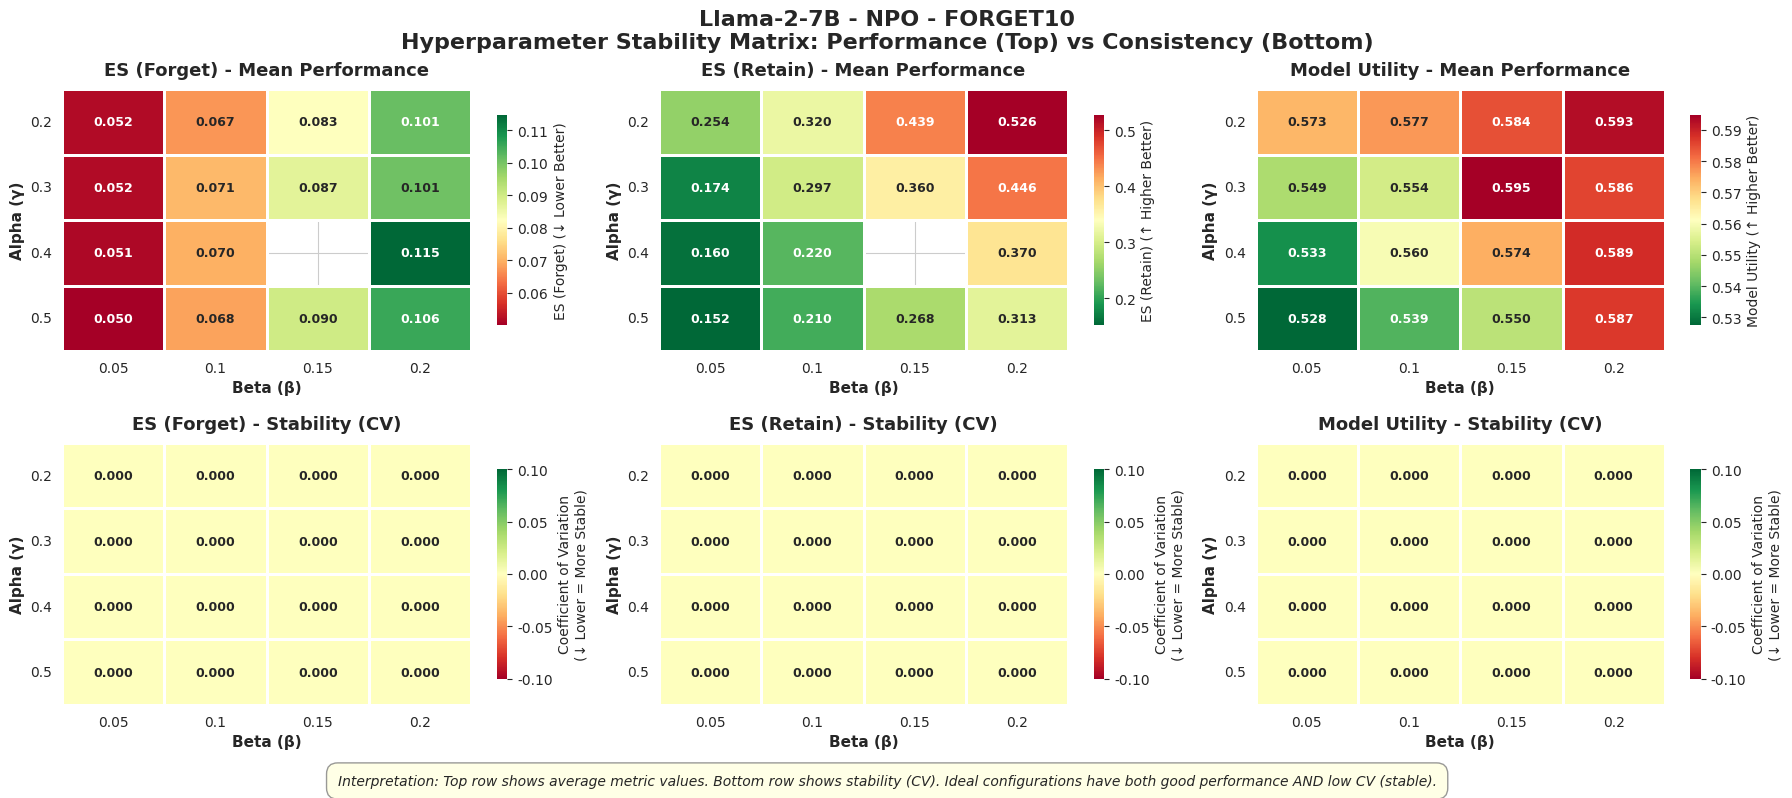


NPO - FORGET10: Hyperparameter Sensitivity Analysis

ES (Forget):
  Range: [0.0502, 0.1146]
  Mean ± Std: 0.0775 ± 0.0217
  Coefficient of Variation: 0.2801
  Stability: Unstable ★★☆☆☆

ES (Retain):
  Range: [0.1520, 0.5264]
  Mean ± Std: 0.3006 ± 0.1122
  Coefficient of Variation: 0.3733
  Stability: Unstable ★★☆☆☆

Model Utility:
  Range: [0.5276, 0.5947]
  Mean ± Std: 0.5669 ± 0.0223
  Coefficient of Variation: 0.0393
  Stability: Very Stable ★★★★★


/tmp/ipykernel_2590/3013780641.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


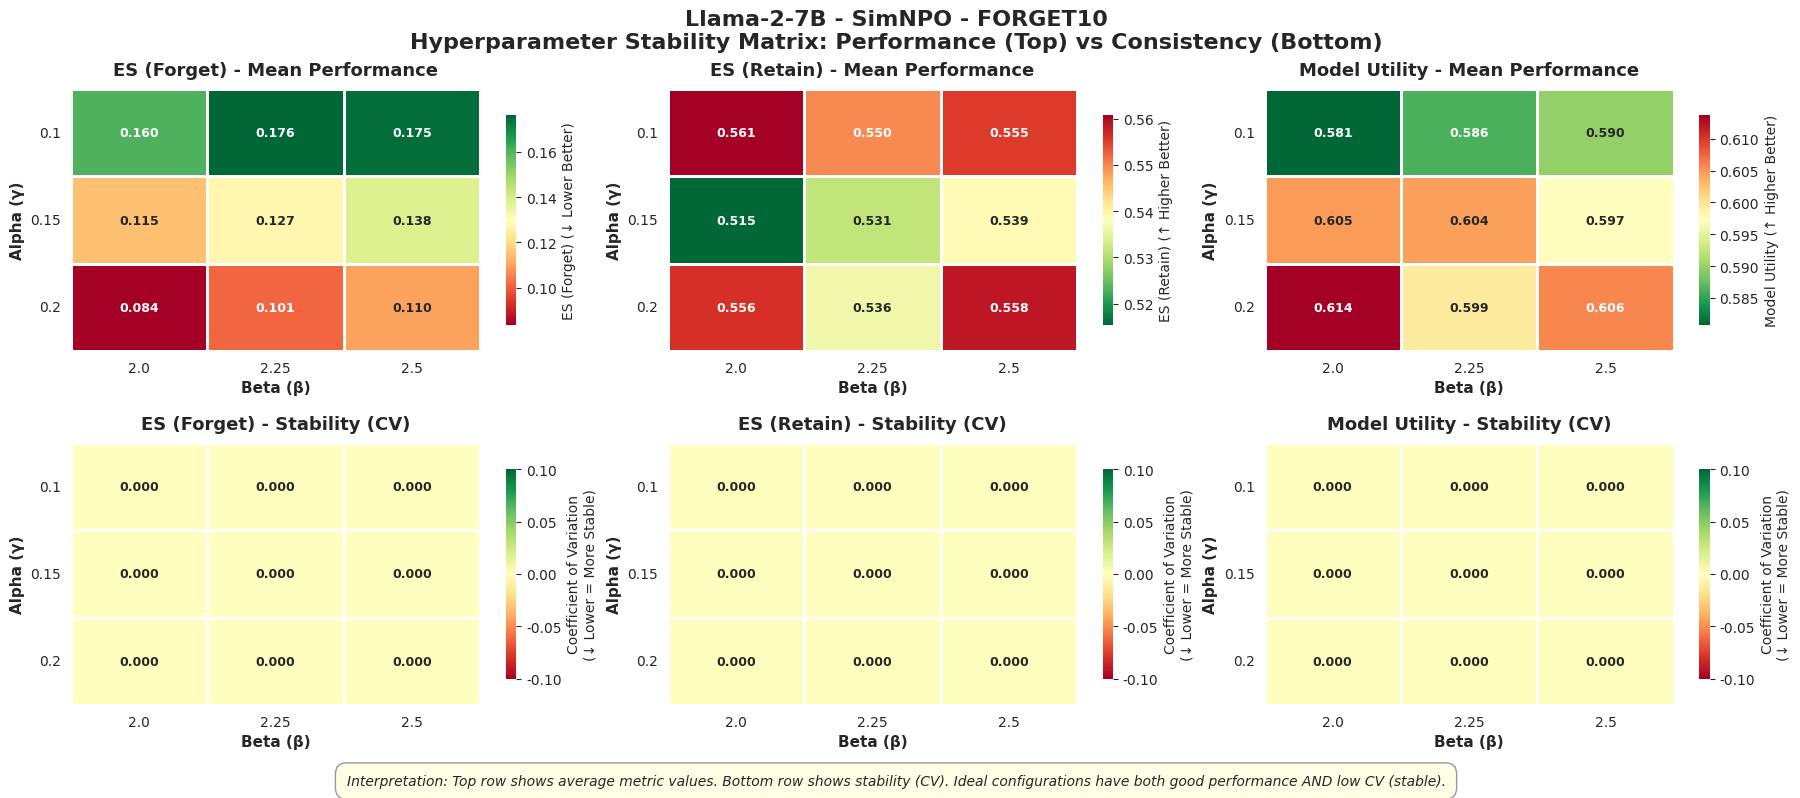


SimNPO - FORGET10: Hyperparameter Sensitivity Analysis

ES (Forget):
  Range: [0.0835, 0.1763]
  Mean ± Std: 0.1317 ± 0.0331
  Coefficient of Variation: 0.2511
  Stability: Unstable ★★☆☆☆

ES (Retain):
  Range: [0.5154, 0.5607]
  Mean ± Std: 0.5447 ± 0.0152
  Coefficient of Variation: 0.0279
  Stability: Very Stable ★★★★★

Model Utility:
  Range: [0.5807, 0.6137]
  Mean ± Std: 0.5980 ± 0.0106
  Coefficient of Variation: 0.0178
  Stability: Very Stable ★★★★★


In [ ]:
# Visualization 4: Publication-Quality Stability Matrix (Alpha-Beta Grid Style)
# Modern AI paper figure showing metric behavior across hyperparameter space
# This creates a comprehensive grid view suitable for academic publications

for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        # Check for beta-gamma (treating gamma as alpha in visualization)
        if 'beta' not in method_df.columns or 'gamma' not in method_df.columns:
            continue
        
        grid_df = method_df[method_df['beta'].notna() & method_df['gamma'].notna()]
        
        if len(grid_df) < 4:
            continue
        
        # Create figure with advanced layout
        fig = plt.figure(figsize=(22, 8))
        gs = fig.add_gridspec(2, 6, hspace=0.35, wspace=0.4,
                             height_ratios=[1, 1])
        
        # ===== Top Row: Three metrics performance heatmaps =====
        metric_axes_top = []
        for idx, metric in enumerate(key_metrics):
            ax = fig.add_subplot(gs[0, idx*2:idx*2+2])
            metric_axes_top.append(ax)
            
            pivot = grid_df.pivot_table(
                values=metric, index='gamma', columns='beta', aggfunc='mean'
            )
            
            # Colormap selection
            if metric == 'extraction_strength':
                cmap = 'RdYlGn'
                label_suffix = '(↓ Lower Better)'
            else:
                cmap = 'RdYlGn_r'
                label_suffix = '(↑ Higher Better)'
            
            im = sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap,
                           ax=ax, cbar_kws={'label': f'{key_metric_labels[metric]} {label_suffix}',
                                           'shrink': 0.8},
                           linewidths=1, linecolor='white',
                           annot_kws={'fontsize': 9, 'fontweight': 'bold'})
            
            ax.set_title(f'{key_metric_labels[metric]} - Mean Performance', 
                        fontsize=13, fontweight='bold', pad=10)
            ax.set_xlabel('Beta (β)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Alpha (γ)', fontsize=11, fontweight='bold')
            
            # Rotate labels for better readability
            ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        
        # ===== Bottom Row: Stability metrics (CV) heatmaps =====
        for idx, metric in enumerate(key_metrics):
            ax = fig.add_subplot(gs[1, idx*2:idx*2+2])
            
            # Calculate CV for each cell in the grid
            cv_grid = []
            for gamma_val in sorted(grid_df['gamma'].unique()):
                cv_row = []
                for beta_val in sorted(grid_df['beta'].unique()):
                    cell_data = grid_df[(grid_df['gamma'] == gamma_val) & 
                                       (grid_df['beta'] == beta_val)][metric]
                    
                    if len(cell_data) > 1 and cell_data.mean() != 0:
                        cv = cell_data.std() / abs(cell_data.mean())
                    elif len(cell_data) == 1:
                        cv = 0  # Single point, perfectly stable
                    else:
                        cv = np.nan
                    
                    cv_row.append(cv)
                cv_grid.append(cv_row)
            
            # Create DataFrame for heatmap
            cv_df = pd.DataFrame(cv_grid,
                               index=sorted(grid_df['gamma'].unique()),
                               columns=sorted(grid_df['beta'].unique()))
            
            # Plot stability heatmap (lower CV = more stable = better = green)
            sns.heatmap(cv_df, annot=True, fmt='.3f', cmap='RdYlGn',
                       ax=ax, cbar_kws={'label': 'Coefficient of Variation\n(↓ Lower = More Stable)',
                                       'shrink': 0.8},
                       linewidths=1, linecolor='white',
                       annot_kws={'fontsize': 9, 'fontweight': 'bold'},
                       vmin=0, vmax=cv_df.max().max() if not cv_df.isnull().all().all() else 1)
            
            ax.set_title(f'{key_metric_labels[metric]} - Stability (CV)', 
                        fontsize=13, fontweight='bold', pad=10)
            ax.set_xlabel('Beta (β)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Alpha (γ)', fontsize=11, fontweight='bold')
            
            ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        
        # Add main title
        fig.suptitle(f'{model_name} - {method} - {forget_set.upper()}\n'
                    f'Hyperparameter Stability Matrix: Performance (Top) vs Consistency (Bottom)',
                    fontsize=16, fontweight='bold', y=0.98)
        
        # Add interpretation box
        fig.text(0.5, 0.01, 
                'Interpretation: Top row shows average metric values. Bottom row shows stability (CV). '
                'Ideal configurations have both good performance AND low CV (stable).',
                ha='center', fontsize=10, style='italic',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', 
                         edgecolor='gray', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Print statistical summary
        print(f"\n{'='*100}")
        print(f"{method} - {forget_set.upper()}: Hyperparameter Sensitivity Analysis")
        print('='*100)
        
        for metric in key_metrics:
            values = grid_df[metric].dropna()
            if len(values) > 1:
                cv = values.std() / abs(values.mean()) if values.mean() != 0 else 0
                print(f"\n{key_metric_labels[metric]}:")
                print(f"  Range: [{values.min():.4f}, {values.max():.4f}]")
                print(f"  Mean ± Std: {values.mean():.4f} ± {values.std():.4f}")
                print(f"  Coefficient of Variation: {cv:.4f}")
                
                # Stability assessment
                if cv < 0.05:
                    stability = "Very Stable ★★★★★"
                elif cv < 0.10:
                    stability = "Stable ★★★★☆"
                elif cv < 0.20:
                    stability = "Moderately Stable ★★★☆☆"
                else:
                    stability = "Unstable ★★☆☆☆"
                print(f"  Stability: {stability}")
        
        print("="*100)

/tmp/ipykernel_2590/3915947770.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


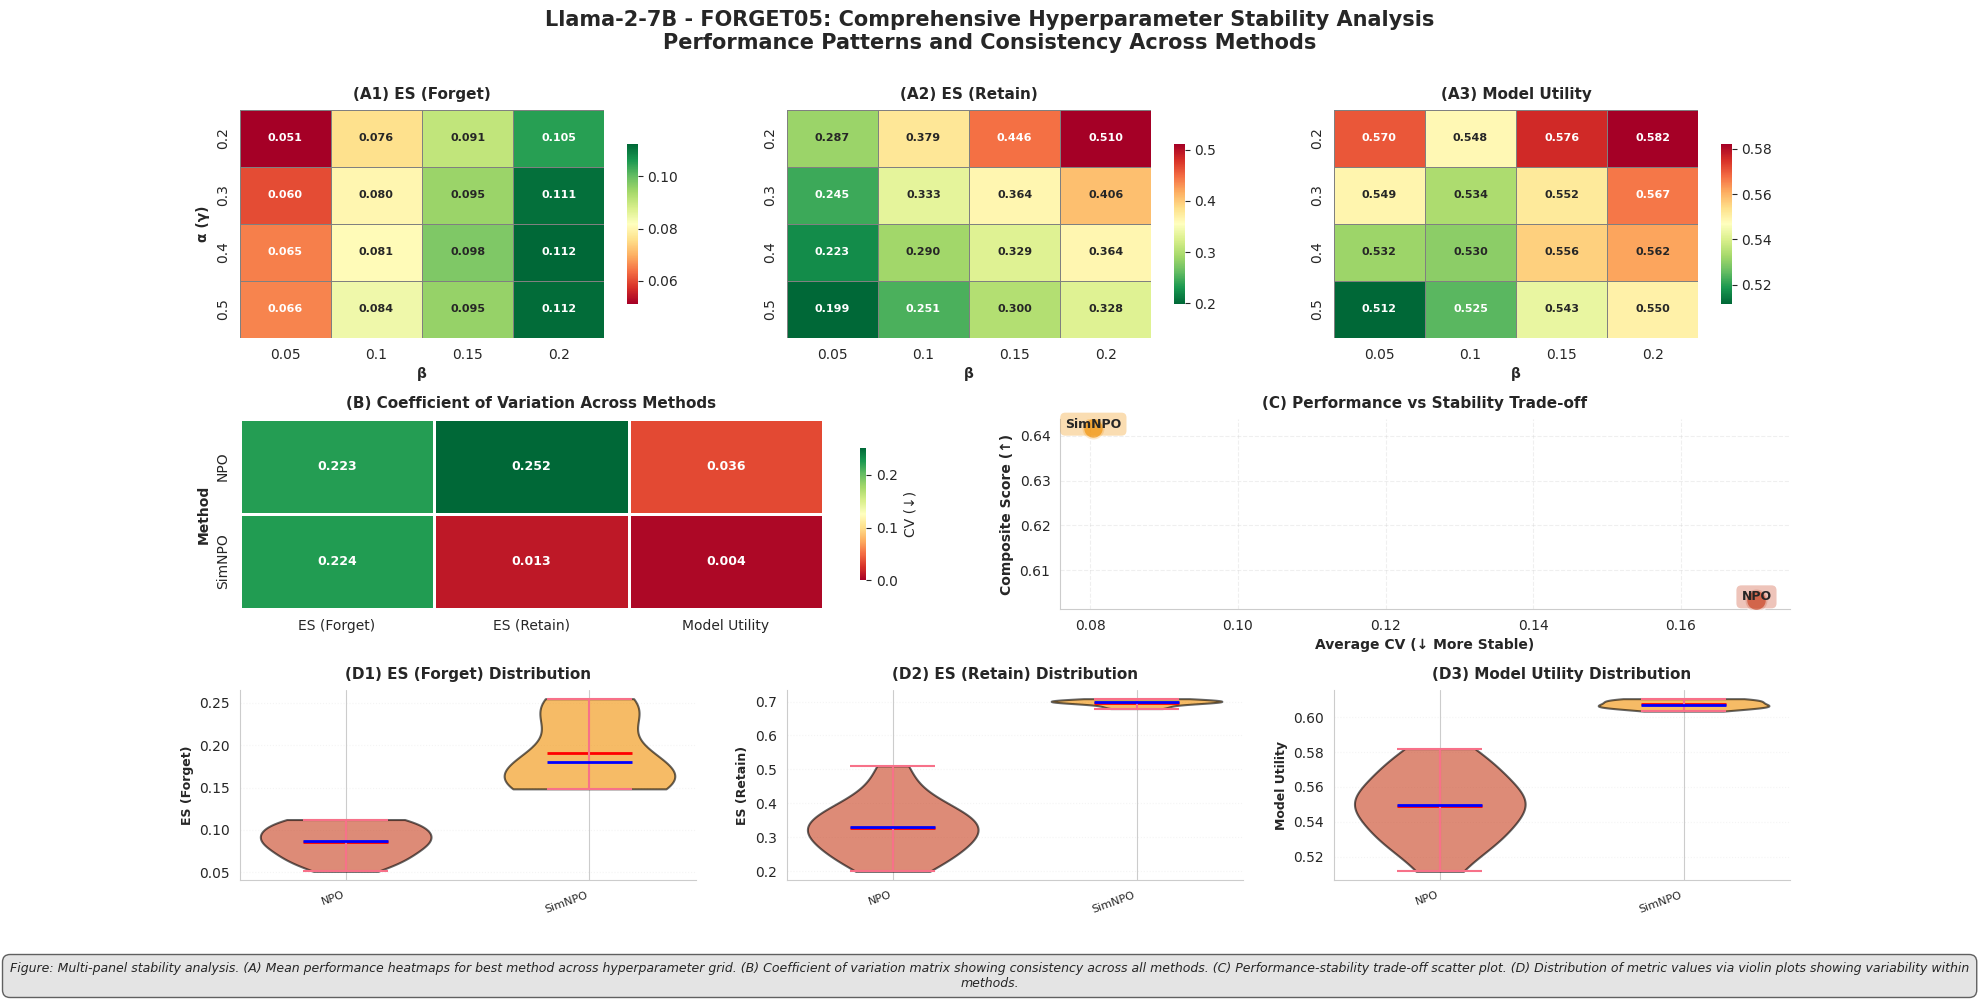


Publication-Ready Stability Dashboard Created - FORGET05
Featured Method: NPO (most comprehensive grid coverage)
Total Configurations Analyzed: 25
Metrics Evaluated: ES (Forget), ES (Retain), Model Utility


/tmp/ipykernel_2590/3915947770.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


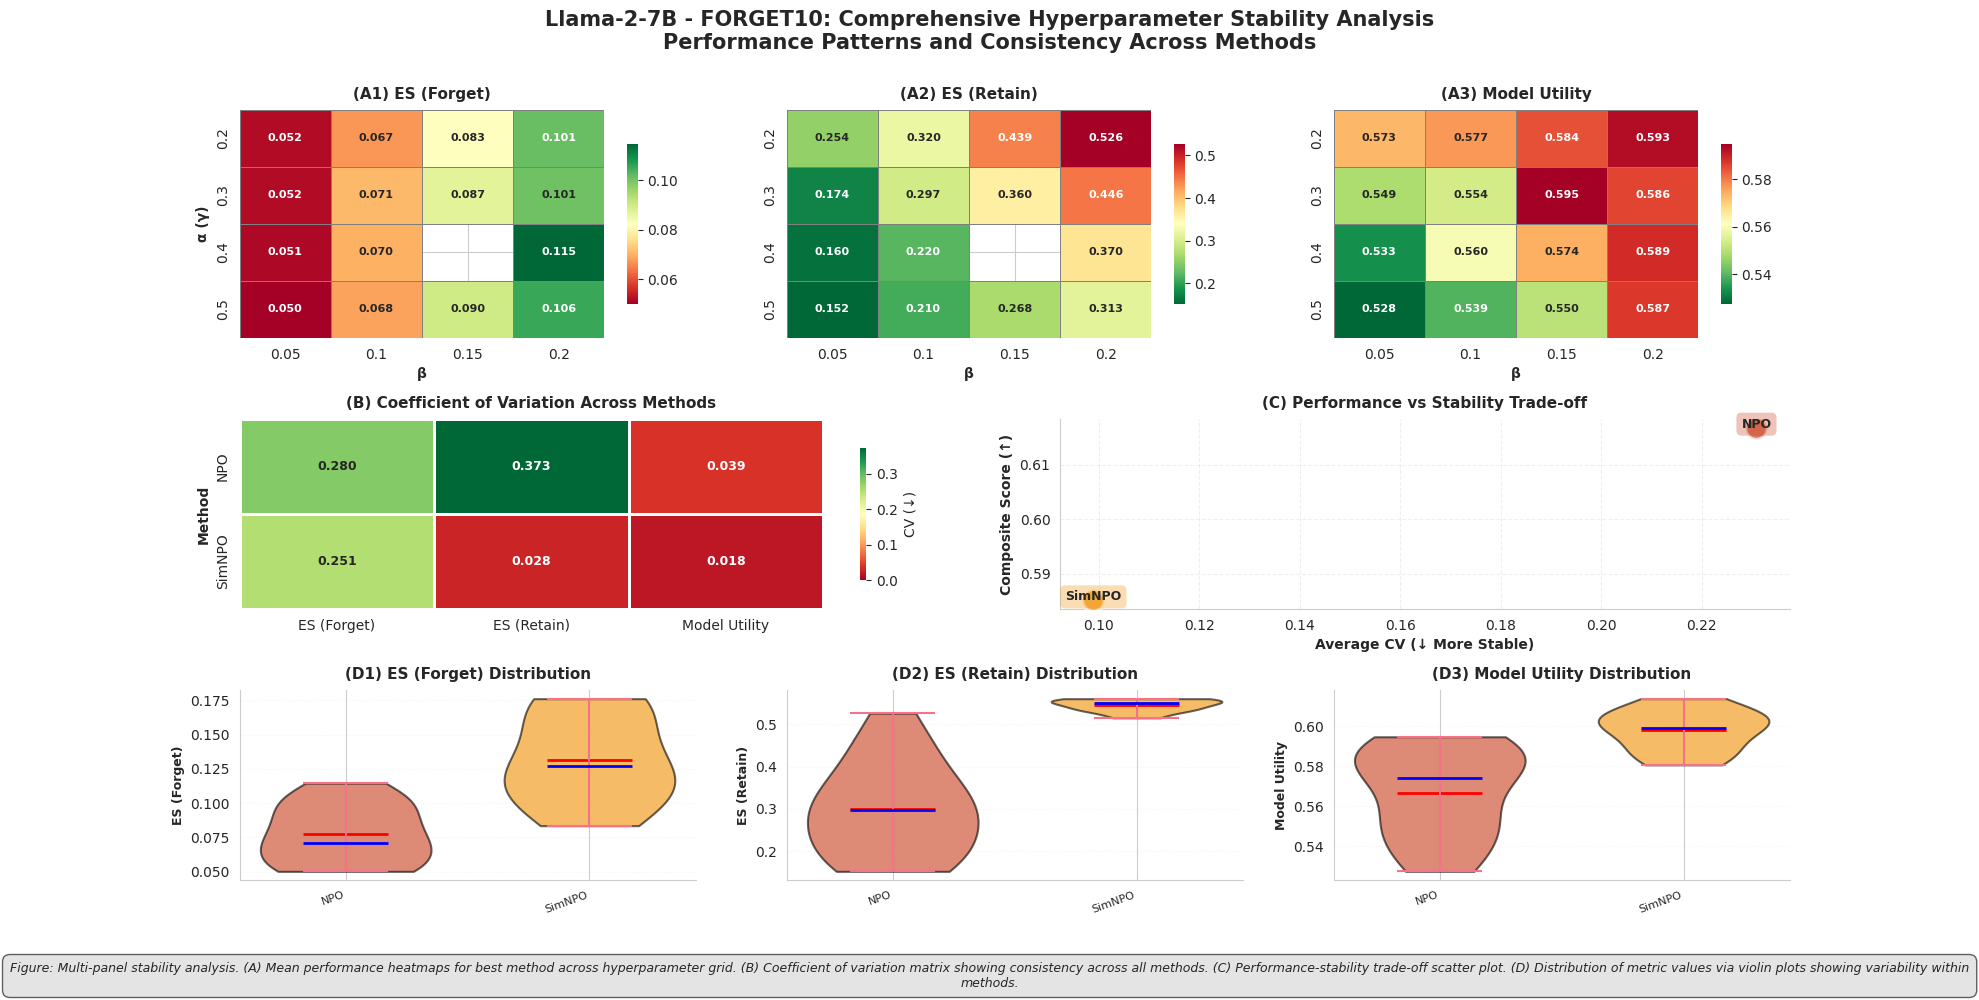


Publication-Ready Stability Dashboard Created - FORGET10
Featured Method: NPO (most comprehensive grid coverage)
Total Configurations Analyzed: 25
Metrics Evaluated: ES (Forget), ES (Retain), Model Utility


In [ ]:
# Visualization 5: Compact Publication Figure - All-in-One Stability Dashboard
# Single comprehensive figure suitable for AI conference papers (e.g., NeurIPS, ICML style)

for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    # Select one representative method with good grid coverage for detailed analysis
    best_method = None
    max_grid_size = 0
    
    for method in methods:
        method_data = forget_df[forget_df['method'] == method]
        if 'beta' in method_data.columns and 'gamma' in method_data.columns:
            grid_size = len(method_data[method_data['beta'].notna() & method_data['gamma'].notna()])
            if grid_size > max_grid_size:
                max_grid_size = grid_size
                best_method = method
    
    if best_method is None or max_grid_size < 4:
        continue
    
    method_df = forget_df[forget_df['method'] == best_method].copy()
    grid_df = method_df[method_df['beta'].notna() & method_df['gamma'].notna()]
    
    # Create compact publication-ready figure
    fig = plt.figure(figsize=(20, 10))
    
    # Use a more sophisticated grid layout
    gs = fig.add_gridspec(3, 6, hspace=0.4, wspace=0.5,
                         height_ratios=[1.2, 1, 1])
    
    # ===== Panel A: Performance Heatmaps (3 metrics side by side) =====
    for idx, metric in enumerate(key_metrics):
        ax = fig.add_subplot(gs[0, idx*2:idx*2+2])
        
        pivot = grid_df.pivot_table(values=metric, index='gamma', columns='beta', aggfunc='mean')
        
        if metric == 'extraction_strength':
            cmap = 'RdYlGn'
            vmin, vmax = pivot.min().min(), pivot.max().max()
        else:
            cmap = 'RdYlGn_r'
            vmin, vmax = pivot.min().min(), pivot.max().max()
        
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax,
                   linewidths=0.5, linecolor='gray', vmin=vmin, vmax=vmax,
                   cbar_kws={'shrink': 0.7, 'aspect': 15},
                   annot_kws={'fontsize': 8, 'weight': 'bold'})
        
        ax.set_title(f'(A{idx+1}) {key_metric_labels[metric]}', 
                    fontsize=11, fontweight='bold', pad=8)
        ax.set_xlabel('β', fontsize=10, fontweight='bold')
        ax.set_ylabel('α (γ)' if idx == 0 else '', fontsize=10, fontweight='bold')
        
        if idx > 0:
            ax.set_ylabel('')
    
    # ===== Panel B: Stability (CV) across all methods =====
    ax_stability = fig.add_subplot(gs[1, :3])
    
    stability_summary = []
    for method in methods:
        method_data = forget_df[forget_df['method'] == method]
        for metric in key_metrics:
            values = method_data[metric].dropna()
            if len(values) > 1 and values.mean() != 0:
                cv = values.std() / abs(values.mean())
                stability_summary.append({
                    'Method': method,
                    'Metric': key_metric_labels[metric],
                    'CV': cv
                })
    
    if stability_summary:
        stability_df = pd.DataFrame(stability_summary)
        pivot_stability = stability_df.pivot(index='Method', columns='Metric', values='CV')
        
        sns.heatmap(pivot_stability, annot=True, fmt='.3f', cmap='RdYlGn',
                   ax=ax_stability, linewidths=1, linecolor='white',
                   cbar_kws={'label': 'CV (↓)', 'shrink': 0.7},
                   annot_kws={'fontsize': 9, 'weight': 'bold'},
                   vmin=0, vmax=pivot_stability.max().max())
        
        ax_stability.set_title('(B) Coefficient of Variation Across Methods', 
                              fontsize=11, fontweight='bold', pad=8)
        ax_stability.set_xlabel('')
        ax_stability.set_ylabel('Method', fontsize=10, fontweight='bold')
    
    # ===== Panel C: Performance-Stability Scatter =====
    ax_scatter = fig.add_subplot(gs[1, 3:])
    
    colors_method = {'GradAscent': '#2E86AB', 'GradDiff': '#A23B72', 
                     'SimNPO': '#F18F01', 'NPO': '#C73E1D'}
    
    # Use composite score for y-axis, CV for x-axis
    for method in methods:
        method_data = forget_df[forget_df['method'] == method]
        
        if 'composite_score' in method_data.columns and len(method_data) > 1:
            # Calculate average CV across three key metrics
            cvs = []
            for metric in key_metrics:
                values = method_data[metric].dropna()
                if len(values) > 1 and values.mean() != 0:
                    cv = values.std() / abs(values.mean())
                    cvs.append(cv)
            
            if cvs:
                avg_cv = np.mean(cvs)
                avg_composite = method_data['composite_score'].mean()
                
                ax_scatter.scatter(avg_cv, avg_composite, s=250, alpha=0.7,
                                 color=colors_method.get(method, '#808080'),
                                 edgecolors='white', linewidth=2.5, zorder=3)
                
                ax_scatter.annotate(method, (avg_cv, avg_composite),
                                  fontsize=9, fontweight='bold', ha='center',
                                  bbox=dict(boxstyle='round,pad=0.4',
                                          facecolor=colors_method.get(method, '#808080'),
                                          alpha=0.3, edgecolor='none'))
    
    ax_scatter.set_xlabel('Average CV (↓ More Stable)', fontsize=10, fontweight='bold')
    ax_scatter.set_ylabel('Composite Score (↑)', fontsize=10, fontweight='bold')
    ax_scatter.set_title('(C) Performance vs Stability Trade-off', 
                        fontsize=11, fontweight='bold', pad=8)
    ax_scatter.grid(True, alpha=0.3, linestyle='--')
    ax_scatter.spines['top'].set_visible(False)
    ax_scatter.spines['right'].set_visible(False)
    
    # ===== Panel D: Distribution comparison (violin plots) =====
    for idx, metric in enumerate(key_metrics):
        ax_violin = fig.add_subplot(gs[2, idx*2:idx*2+2])
        
        # Prepare data for violin plot
        plot_data = []
        plot_labels = []
        
        for method in methods:
            method_data = forget_df[forget_df['method'] == method][metric].dropna()
            if len(method_data) > 0:
                plot_data.append(method_data)
                plot_labels.append(method)
        
        if plot_data:
            parts = ax_violin.violinplot(plot_data, positions=range(len(plot_data)),
                                        widths=0.7, showmeans=True, showmedians=True)
            
            # Color the violin plots
            for i, pc in enumerate(parts['bodies']):
                method = plot_labels[i]
                pc.set_facecolor(colors_method.get(method, '#808080'))
                pc.set_alpha(0.6)
                pc.set_edgecolor('black')
                pc.set_linewidth(1.5)
            
            # Style mean and median lines
            parts['cmeans'].set_edgecolor('red')
            parts['cmeans'].set_linewidth(2)
            parts['cmedians'].set_edgecolor('blue')
            parts['cmedians'].set_linewidth(2)
            
            ax_violin.set_xticks(range(len(plot_labels)))
            ax_violin.set_xticklabels(plot_labels, rotation=20, ha='right', fontsize=8)
            ax_violin.set_ylabel(key_metric_labels[metric], fontsize=9, fontweight='bold')
            ax_violin.set_title(f'(D{idx+1}) {key_metric_labels[metric]} Distribution', 
                              fontsize=11, fontweight='bold', pad=8)
            ax_violin.grid(True, alpha=0.2, axis='y', linestyle=':')
            ax_violin.spines['top'].set_visible(False)
            ax_violin.spines['right'].set_visible(False)
    
    # Add overall title
    fig.suptitle(f'{model_name} - {forget_set.upper()}: Comprehensive Hyperparameter Stability Analysis\n'
                f'Performance Patterns and Consistency Across Methods',
                fontsize=15, fontweight='bold', y=0.98)
    
    # Add caption/interpretation
    caption_text = (
        "Figure: Multi-panel stability analysis. "
        "(A) Mean performance heatmaps for best method across hyperparameter grid. "
        "(B) Coefficient of variation matrix showing consistency across all methods. "
        "(C) Performance-stability trade-off scatter plot. "
        "(D) Distribution of metric values via violin plots showing variability within methods."
    )
    
    fig.text(0.5, 0.005, caption_text,
            ha='center', fontsize=9, style='italic', wrap=True,
            bbox=dict(boxstyle='round,pad=0.6', facecolor='lightgray', 
                     edgecolor='black', alpha=0.6, linewidth=1))
    
    plt.tight_layout()
    
    # Save high-resolution version for publication
    # filename = f'/cnz/data/project/my-open-unlearning/notebooks/publication_stability_{forget_set}.pdf'
    # plt.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
    # print(f"High-resolution figure saved: {filename}")
    
    plt.show()
    
    print(f"\n{'='*100}")
    print(f"Publication-Ready Stability Dashboard Created - {forget_set.upper()}")
    print('='*100)
    print(f"Featured Method: {best_method} (most comprehensive grid coverage)")
    print(f"Total Configurations Analyzed: {len(forget_df)}")
    print(f"Metrics Evaluated: {', '.join([key_metric_labels[m] for m in key_metrics])}")
    print("="*100)


Processing NPO on forget10...

Processing SimNPO on forget10...


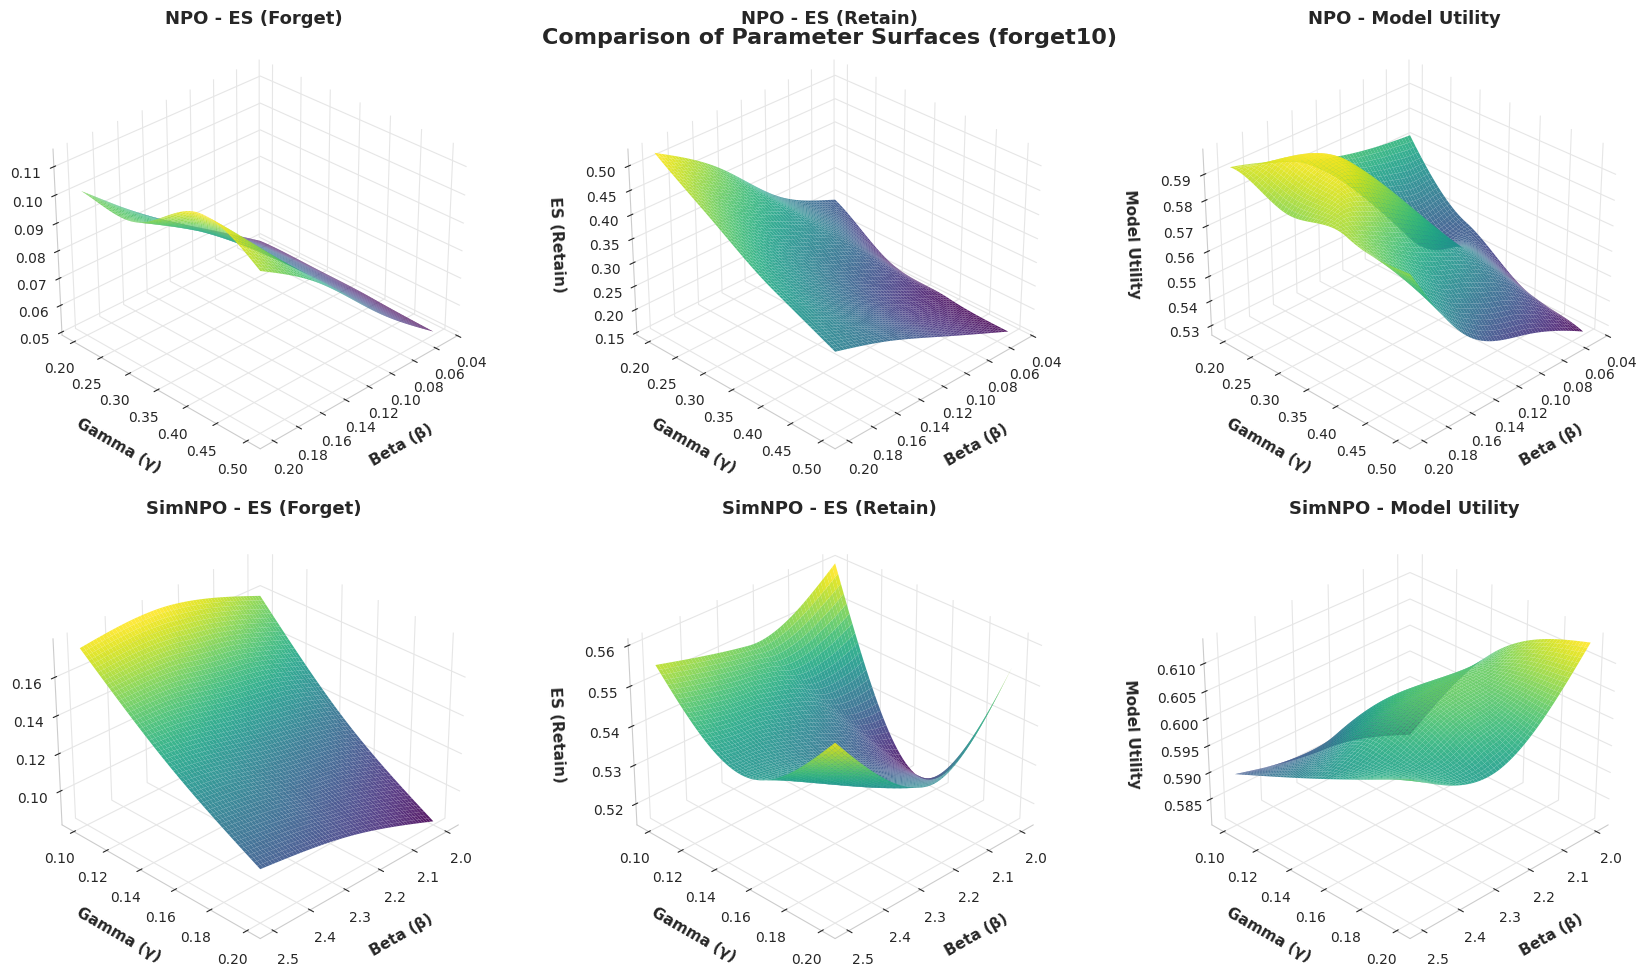

In [ ]:
# 可视化 5: NPO/SimNPO 稳定性最优配置识别（3D 视角） - 纯曲面版 (合并图)
# 针对 forget10 数据，以 Beta 和 Gamma 为平面坐标
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

target_forget_set = 'forget10'
target_methods = ['NPO', 'SimNPO']

# 定义关键指标的标签（如果未定义）
if 'key_metric_labels' not in globals():
    key_metric_labels = {
        'extraction_strength': 'Forget Score (ES) ↓',
        'extraction_strength_retain': 'Retain Score (ES) ↑',
        'model_utility': 'Model Utility ↑'
    }

# 创建一个大图：2行（方法）x 3列（指标）
fig = plt.figure(figsize=(18, 10))

for method_idx, method in enumerate(target_methods):
    print(f"\nProcessing {method} on {target_forget_set}...")
    
    # 过滤数据：特定方法和遗忘集
    method_mask = (df['method'] == method) & \
                  (df['forget_set'] == target_forget_set) & \
                  (df['beta'].notna()) & \
                  (df['gamma'].notna())
    
    df_focus = df[method_mask].copy()

    if len(df_focus) < 4:
        print(f"  警告：{method} 数据点不足 (<4)，跳过绘图。")
        continue

    # 有效范围
    beta_min, beta_max = df_focus['beta'].min(), df_focus['beta'].max()
    gamma_min, gamma_max = df_focus['gamma'].min(), df_focus['gamma'].max()

    for idx, metric in enumerate(key_metrics):
        if metric not in df_focus.columns:
            continue
            
        # 计算子图位置：共有 len(target_methods) 行，3 列
        plot_idx = method_idx * 3 + idx + 1
        ax = fig.add_subplot(len(target_methods), 3, plot_idx, projection='3d')
        
        # 获取有效数据 (去除 metric 为 NaN 的点)
        valid_mask = df_focus[metric].notna()
        betas = df_focus.loc[valid_mask, 'beta'].values
        gammas = df_focus.loc[valid_mask, 'gamma'].values
        values = df_focus.loc[valid_mask, metric].values
        
        if len(values) < 3:
            # print(f"Skipping {metric}: not enough valid points.")
            continue

        # 创建网格
        grid_res = 60
        ti_beta = np.linspace(betas.min(), betas.max(), grid_res)
        ti_gamma = np.linspace(gammas.min(), gammas.max(), grid_res)
        TI_beta, TI_gamma = np.meshgrid(ti_beta, ti_gamma)
        
        # 稳健插值逻辑
        ZI = None
        try:
            ZI = griddata((betas, gammas), values, (TI_beta, TI_gamma), method='cubic')
            if np.isnan(ZI).any(): 
                ZI = griddata((betas, gammas), values, (TI_beta, TI_gamma), method='linear')
        except Exception:
            try:
                ZI = griddata((betas, gammas), values, (TI_beta, TI_gamma), method='linear')
            except:
                pass
        
        if ZI is None or np.isnan(ZI).all():
             ZI = griddata((betas, gammas), values, (TI_beta, TI_gamma), method='nearest')
        
        # 绘制拟合曲面
        surf = ax.plot_surface(TI_beta, TI_gamma, ZI, cmap='viridis', 
                              edgecolor='none', alpha=0.9, antialiased=True,
                              rstride=1, cstride=1)
        
        # 设置坐标轴标签
        ax.set_xlabel('Beta (β)', fontsize=11, fontweight='bold', labelpad=10)
        ax.set_ylabel('Gamma (γ)', fontsize=11, fontweight='bold', labelpad=10)
        ax.set_zlabel(key_metric_labels.get(metric, metric), fontsize=11, fontweight='bold', labelpad=10)
        
        # 暂时注释掉标题 (但保留代码)
        title_str = f'{method} - {key_metric_labels.get(metric, metric)}'
        ax.set_title(title_str, fontsize=13, fontweight='bold', pad=0)
        
        # 优化视角
        ax.view_init(elev=30, azim=45)
        
        # 净化背景
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor('w')
        ax.yaxis.pane.set_edgecolor('w')
        ax.zaxis.pane.set_edgecolor('w')
        
        # 淡化网格线
        ax.xaxis._axinfo["grid"]['color'] =  (0.9, 0.9, 0.9, 1)
        ax.yaxis._axinfo["grid"]['color'] =  (0.9, 0.9, 0.9, 1)
        ax.zaxis._axinfo["grid"]['color'] =  (0.9, 0.9, 0.9, 1)

# plt.suptitle(f"Comparison of Parameter Surfaces ({target_forget_set})", fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.1) # 调整行间距
plt.savefig("task_vector_consistency.pdf", bbox_inches='tight')
plt.show()

# 输出 Top 配置 (可选，保持不变)
# print(...)